# Step 1 : Import necessary Library

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


# Step 2 Read data to dataframe

In [ ]:
df = pd.read_csv('CBB_Listings.csv')
df.head()

,listing_id,listing_heading,listing_type,listing_url,listing_first_date,days_on_market,dealer_id,dealer_name,dealer_street,dealer_city,...,wheelbase_from_vin,drivetrain_from_vin,engine_from_vin,transmission_from_vin,fuel_type_from_vin,number_price_changes,price_history_delimited,distance_to_dealer,location_score,listing_dropoff_date
0,f5b663d2-4896-11ef-a15b-8b4423f1ff08,1987 IROC Z 350 Auto T-Tops,Active,https://www.kijiji.ca/v-cars-trucks/edmonton/1...,7/22/2024 0:00,9,11152931,David T's Camaro & Firebird Auto Center,10611 201 St NW,Edmonton,...,0.0,RWD,5.7L V8 TBI,A,Gas,0,"2024-07-22,11500,230860",9.84,5,NaN
1,a9f565e6-4712-11ef-a23f-79dc25c5e601,NaN,Sold,https://www.redlinemotors.ca/vehicle-details/1...,7/20/2024 0:00,4,11131329,Redlinemotors.Ca,14421 Mark Messier Trail,Edmonton,...,0.0,RWD,5.2L V8,A,Gas,0,"2024-07-20,8700,48905",8.30,5,7/24/2024 0:00
2,03d18c58-253a-11ef-8f33-8905b4a2f000,1989 Cadillac DeVille Sedan FWD,Active,https://www.sweetheartmotor.com/cars/used/1989...,6/7/2024 0:00,54,11161704,Gateway Auto & Rv Sales & Financing Ltd,5404 Gateway Blvd NW,Edmonton,...,0.0,FWD,4.5L V8 DI,A,Gas,0,"2024-06-07,6000,174640",5.71,4,NaN
3,2d12630b-460e-11ee-89c4-e5b3161d4741,1989 Cadillac DeVille Sedan FWD,Active,https://www.sweetheartmotor.com/cars/used/1989...,8/28/2023 0:00,338,11128265,Credit Angels,5404 Gateway Blvd NW,Edmonton,...,0.0,FWD,4.5L V8 DI,A,Gas,4,"2023-08-28,4500,174640:2023-09-13,5900,174640:...",5.71,5,NaN
4,53a8e550-47cd-11ef-8587-f926ecb61035,1989 Camaro IROC 350 Auto T-Top,Active,https://www.kijiji.ca/v-cars-trucks/edmonton/1...,7/21/2024 0:00,10,11152931,David T's Camaro & Firebird Auto Center,10611 201 St NW,Edmonton,...,0.0,RWD,5.7L V8 TBI,A,Gas,0,"2024-07-21,8500,288000",9.84,5,NaN


# Step 3- Sanity Checks

In [ ]:
df.shape

(145114, 46)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 145114 entries, 0 to 145113
Data columns (total 46 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   listing_id               145114 non-null  object 
 1   listing_heading          141099 non-null  object 
 2   listing_type             145114 non-null  object 
 3   listing_url              145114 non-null  object 
 4   listing_first_date       145114 non-null  object 
 5   days_on_market           145114 non-null  int64  
 6   dealer_id                145114 non-null  int64  
 7   dealer_name              145114 non-null  object 
 8   dealer_street            145114 non-null  object 
 9   dealer_city              145114 non-null  object 
 10  dealer_province          145114 non-null  object 
 11  dealer_postal_code       145114 non-null  object 
 12  dealer_url               145114 non-null  object 
 13  dealer_email             0 non-null       float64
 14  deal

In [ ]:
df.isnull().sum()

,0
listing_id,0
listing_heading,4015
listing_type,0
listing_url,0
listing_first_date,0
days_on_market,0
dealer_id,0
dealer_name,0
dealer_street,0
dealer_city,0


In [ ]:
df.isnull().sum()/df.shape[0]*100

,0
listing_id,0.000000
listing_heading,2.766790
listing_type,0.000000
listing_url,0.000000
listing_first_date,0.000000
days_on_market,0.000000
dealer_id,0.000000
dealer_name,0.000000
dealer_street,0.000000
dealer_city,0.000000


In [ ]:
df.duplicated().sum()


0

In [ ]:
for i in df.select_dtypes(include='object').columns:
    print(df[i].value_counts())
    print('****'* 10)


listing_id
f5b663d2-4896-11ef-a15b-8b4423f1ff08    1
da6fe670-c92a-11ee-8cd8-a7c7b624e831    1
dab15bc7-3f29-11ef-93d8-ab03d10bf52c    1
e3e38cc2-38a3-11ef-9631-2bc88597b2f8    1
98bf388b-3020-11ef-83a0-db2d21fea99e    1
                                       ..
fabaf190-004a-11ef-913f-39bd0307fb59    1
eaac0cfe-13ef-11ef-bb3c-4d7c1cb64911    1
fbb64128-004a-11ef-b7b5-8bffbb162a6d    1
8c634c38-db92-11ee-bcd2-b1211e46f9af    1
70f556a5-6bff-4836-97cc-c859d6b88f15    1
Name: count, Length: 145114, dtype: int64
****************************************
listing_heading
2024 Ford F-150 XLT SuperCrew 4WD                                             475
2024 Chevrolet Silverado 1500 RST                                             447
2024 GMC Sierra 1500 Elevation                                                392
2024 GMC Sierra 1500 Elevation Crew Cab 4WD                                   303
2024 Ford F-150 XLT                                                           234
                  

# Step 4 Exploratory Data Analysis

In [ ]:
df.describe()

,days_on_market,dealer_id,dealer_email,vehicle_id,uvc,mileage,price,msrp,model_year,certified,has_leather,has_navigation,price_analysis,wheelbase_from_vin,number_price_changes,distance_to_dealer,location_score
count,145114.000000,1.451140e+05,0.0,145114.000000,1.451140e+05,1.451140e+05,1.451140e+05,145114.000000,145114.000000,145114.000000,145114.0,145114.0,145114.000000,145114.000000,145114.000000,145114.000000,145114.000000
mean,47.810218,1.115641e+07,NaN,513749.054006,2.021818e+09,4.598501e+04,4.786611e+04,51247.428229,2021.361157,0.006602,0.0,0.0,0.082928,3026.472990,3.504782,9.436435,3.010984
std,57.862393,4.389865e+04,NaN,94034.105057,3.557037e+06,6.227304e+04,9.070245e+04,21760.734381,3.542539,0.080983,0.0,0.0,0.275774,559.718857,7.765742,6.226795,2.104691
min,1.000000,1.112677e+07,NaN,66737.000000,1.987160e+09,0.000000e+00,0.000000e+00,0.000000,1987.000000,0.000000,0.0,0.0,0.000000,0.000000,0.000000,1.230000,0.000000
25%,14.000000,1.112884e+07,NaN,480906.000000,2.020161e+09,1.500000e+01,2.699000e+04,35149.000000,2020.000000,0.000000,0.0,0.0,0.000000,2700.000000,0.000000,6.090000,1.000000
50%,26.000000,1.113164e+07,NaN,558583.000000,2.023360e+09,9.650000e+03,4.190000e+04,48035.000000,2023.000000,0.000000,0.0,0.0,0.000000,2850.000000,1.000000,7.420000,4.000000
75%,59.000000,1.116104e+07,NaN,580271.000000,2.024340e+09,8.011900e+04,6.277025e+04,63045.000000,2024.000000,0.000000,0.0,0.0,0.000000,3342.000000,3.000000,9.400000,5.000000
max,367.000000,1.125746e+07,NaN,599912.000000,2.024960e+09,1.000008e+06,1.309532e+07,315100.000000,2024.000000,1.000000,0.0,0.0,1.000000,5014.000000,154.000000,29.660000,5.000000


In [ ]:
df.describe(include='object')

,listing_id,listing_heading,listing_type,listing_url,listing_first_date,dealer_name,dealer_street,dealer_city,dealer_province,dealer_postal_code,...,exterior_color,exterior_color_category,interior_color,interior_color_category,drivetrain_from_vin,engine_from_vin,transmission_from_vin,fuel_type_from_vin,price_history_delimited,listing_dropoff_date
count,145114,141099,145114,145114,145114,145114,145114,145114,145114,145114,...,139065,110167,93451,86333,145114,145114,145114,145114,145114,98130
unique,145114,73297,2,131730,413,230,234,9,1,185,...,3299,81,2149,30,4,974,4,7,128122,90
top,f5b663d2-4896-11ef-a15b-8b4423f1ff08,2024 Ford F-150 XLT SuperCrew 4WD,Sold,https://www.bridgestoneautoinc.com/cars/used/2...,7/16/2024 0:00,Autocanada,15511 123 Ave NW #200,Edmonton,AB,T5V 0C3,...,Black,white,Black,black,AWD,2.0L I-4 DI DOHC T/C,A,Gas,"2024-07-16,0,0",7/12/2024 0:00
freq,1,475,98130,6,17912,25442,25442,119541,145114,46691,...,20078,33418,60207,69560,60665,7428,141105,124029,108,6417


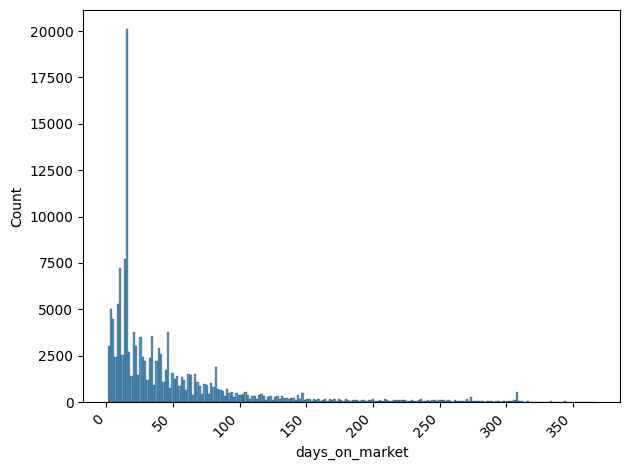

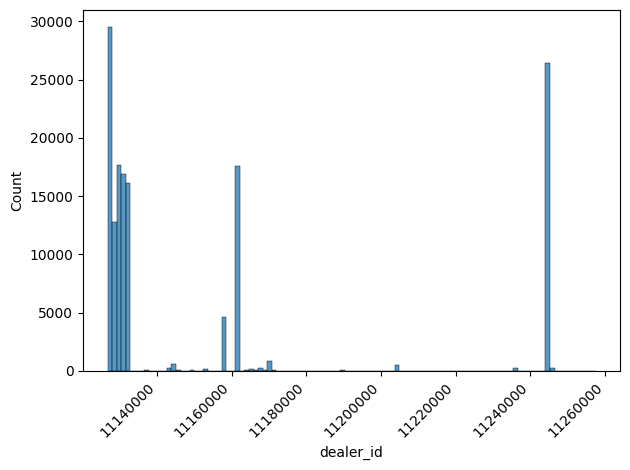

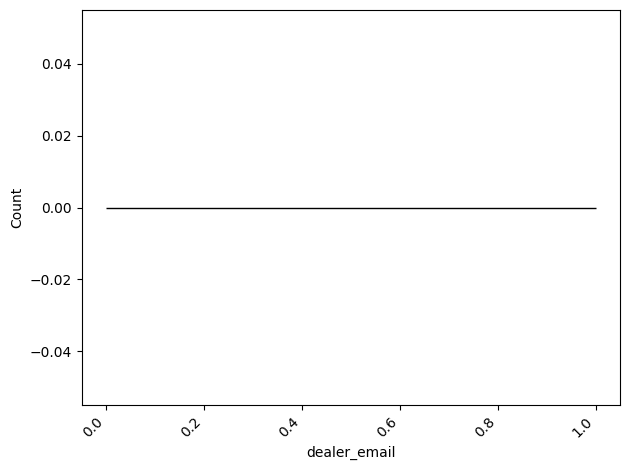

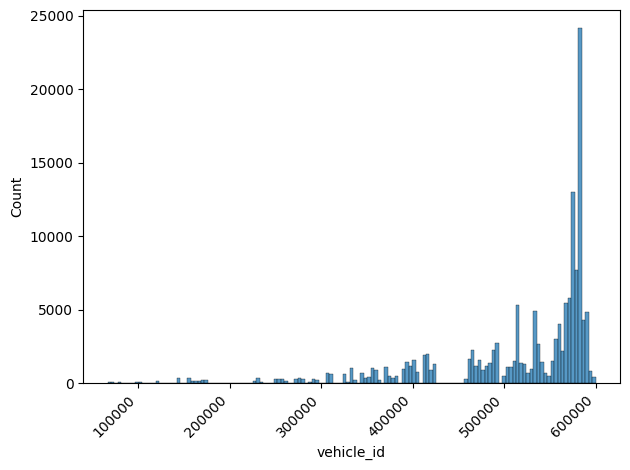

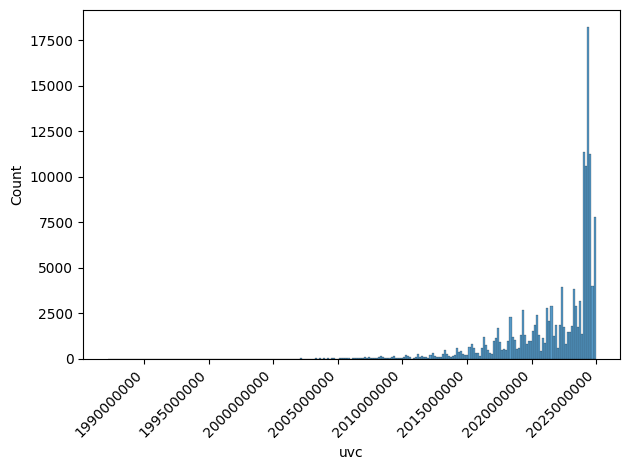

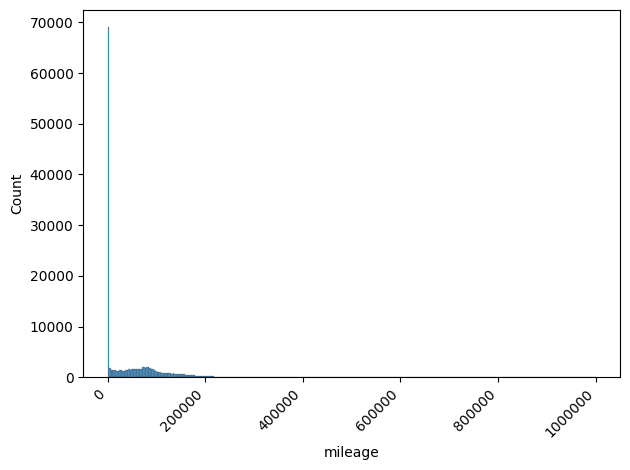

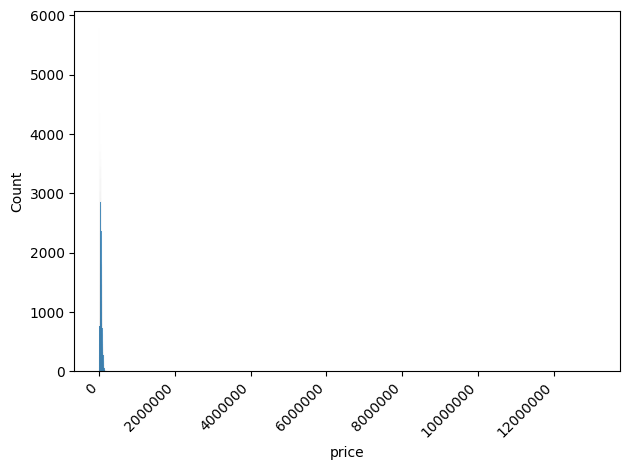

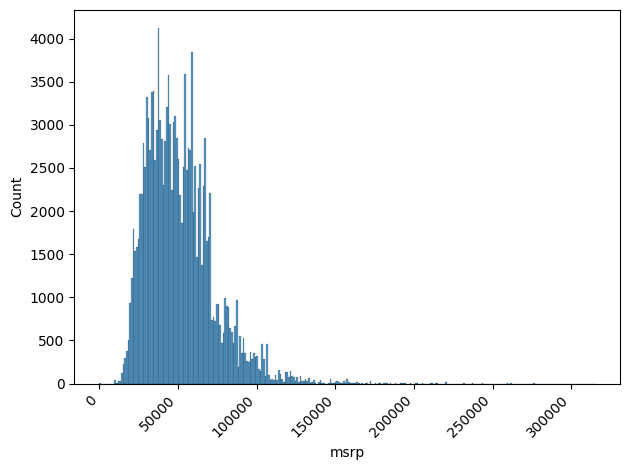

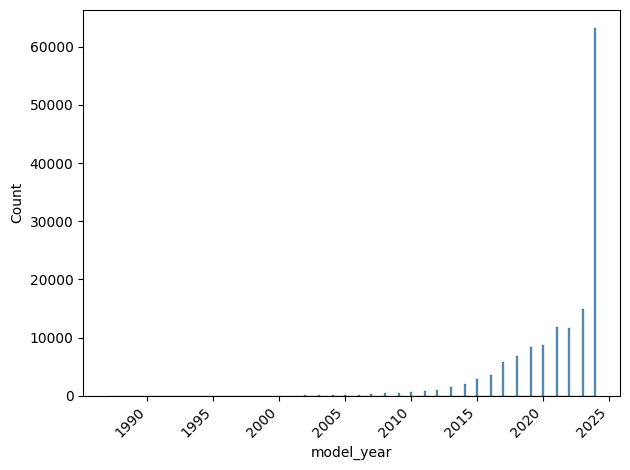

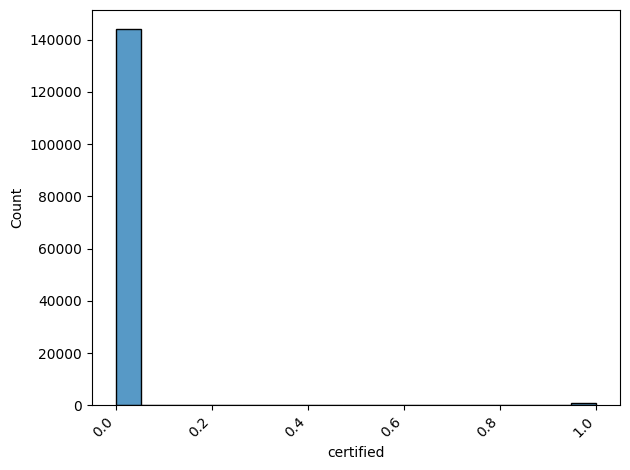

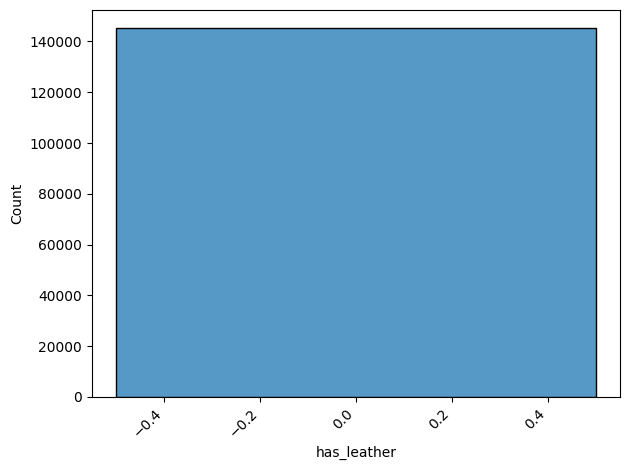

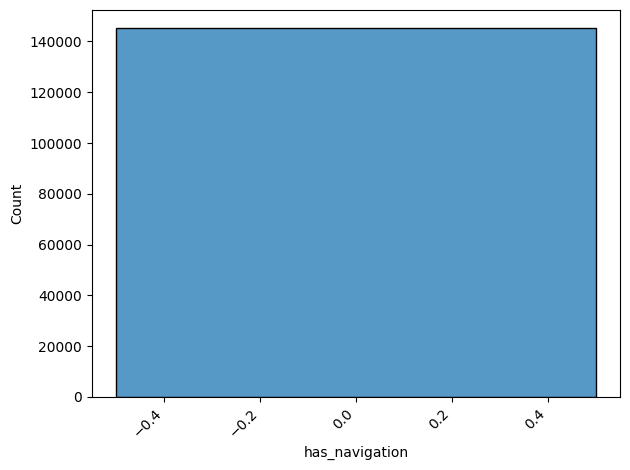

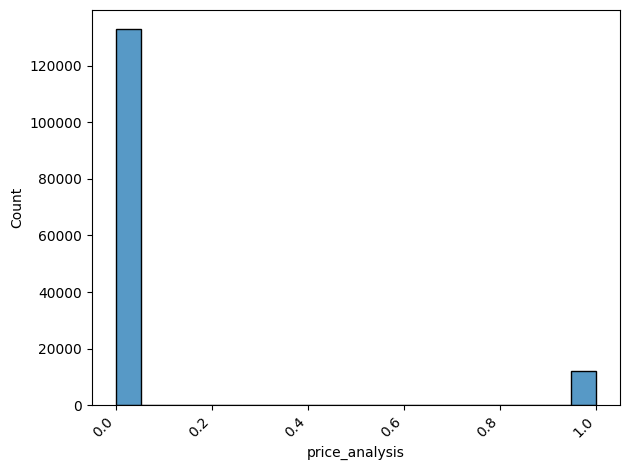

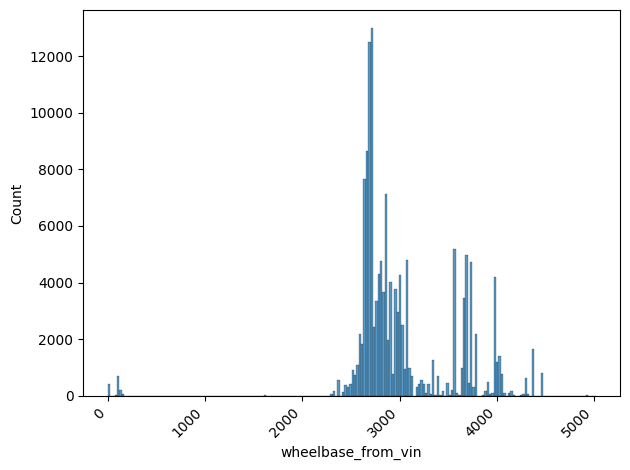

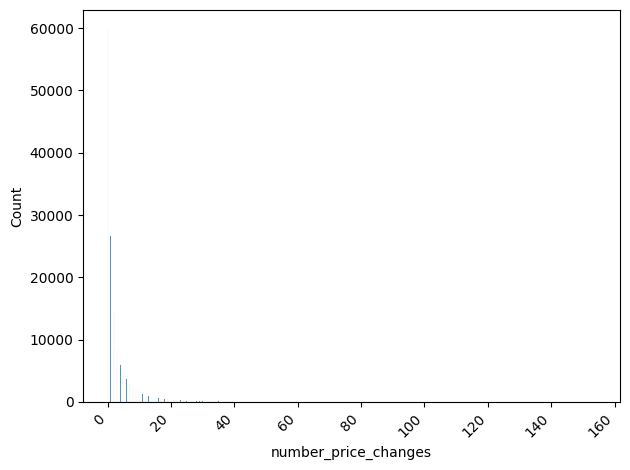

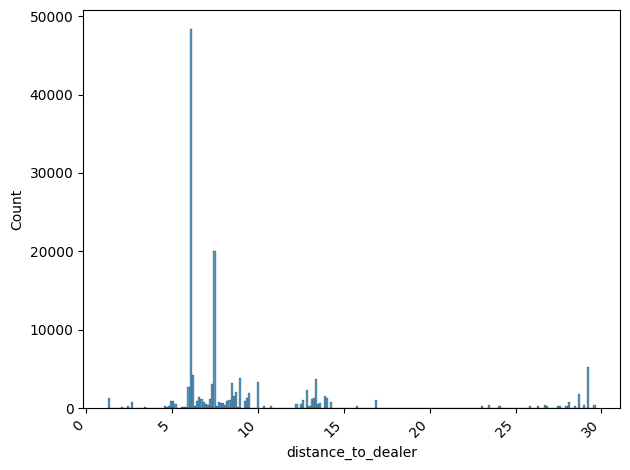

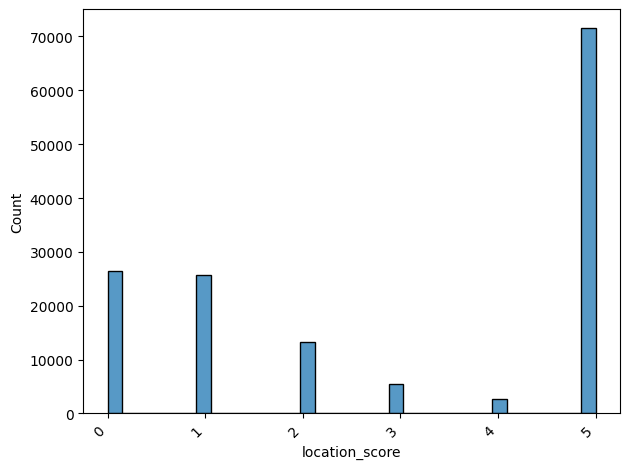

In [ ]:
for i in df.select_dtypes(include='number').columns:
    sns.histplot(data =df, x = i)
    plt.ticklabel_format(style='plain', axis='x')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()


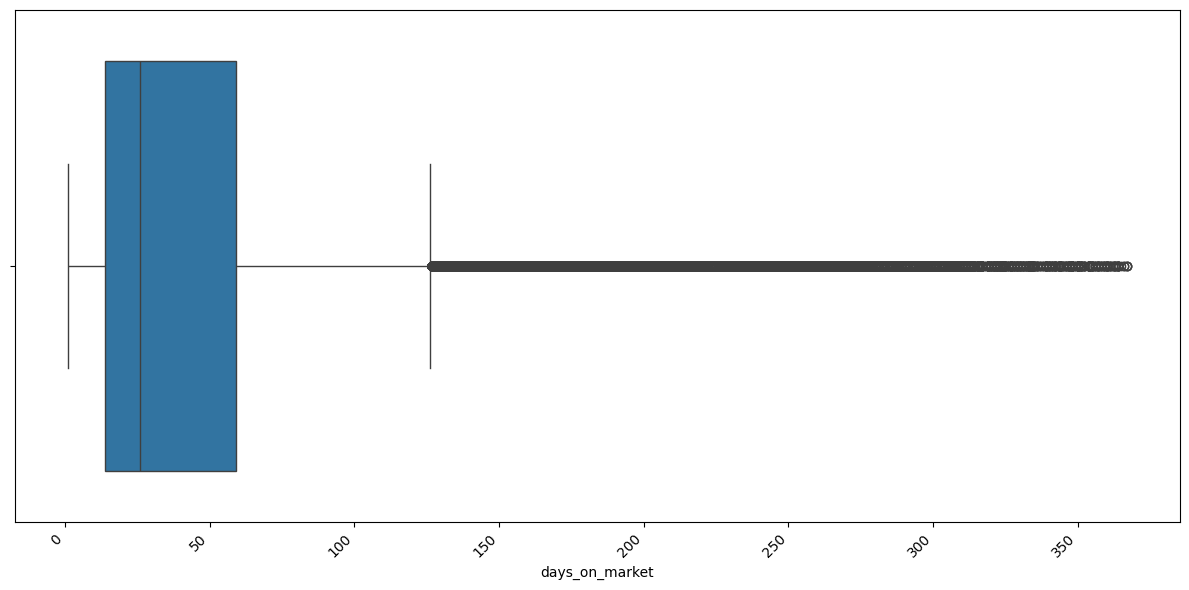

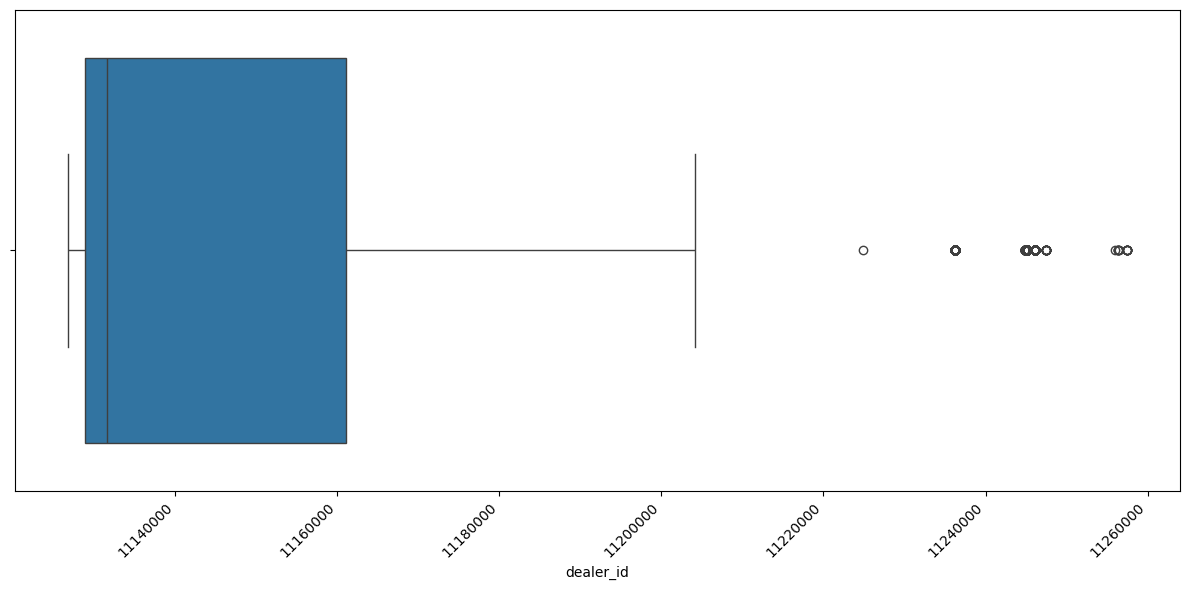

Skipping boxplot for column 'dealer_email' due to non-numeric or missing data.


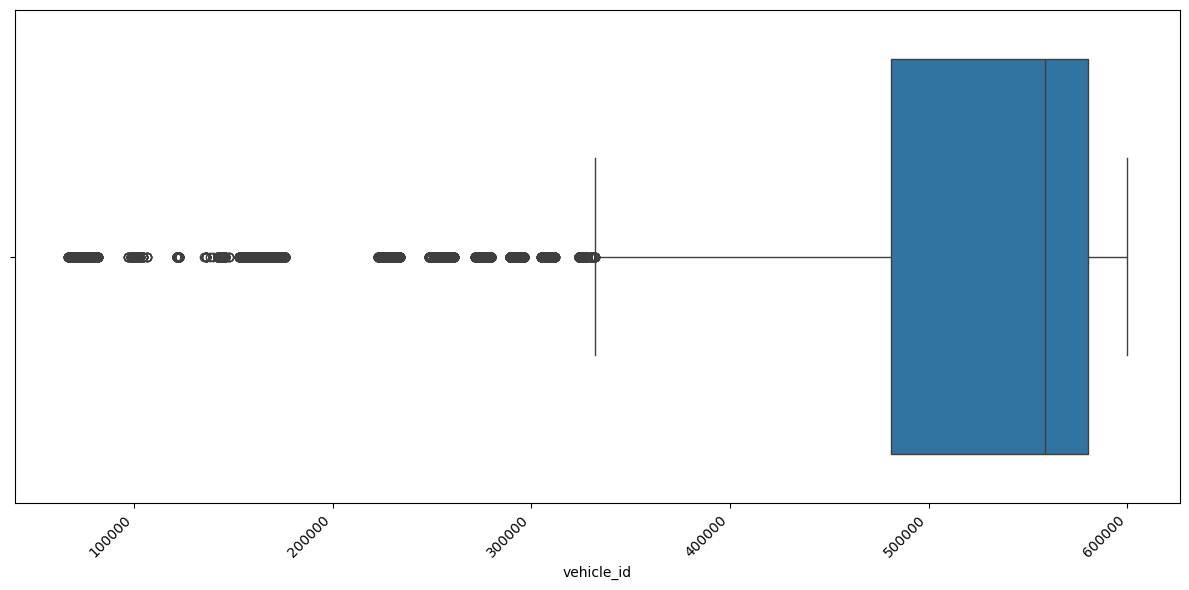

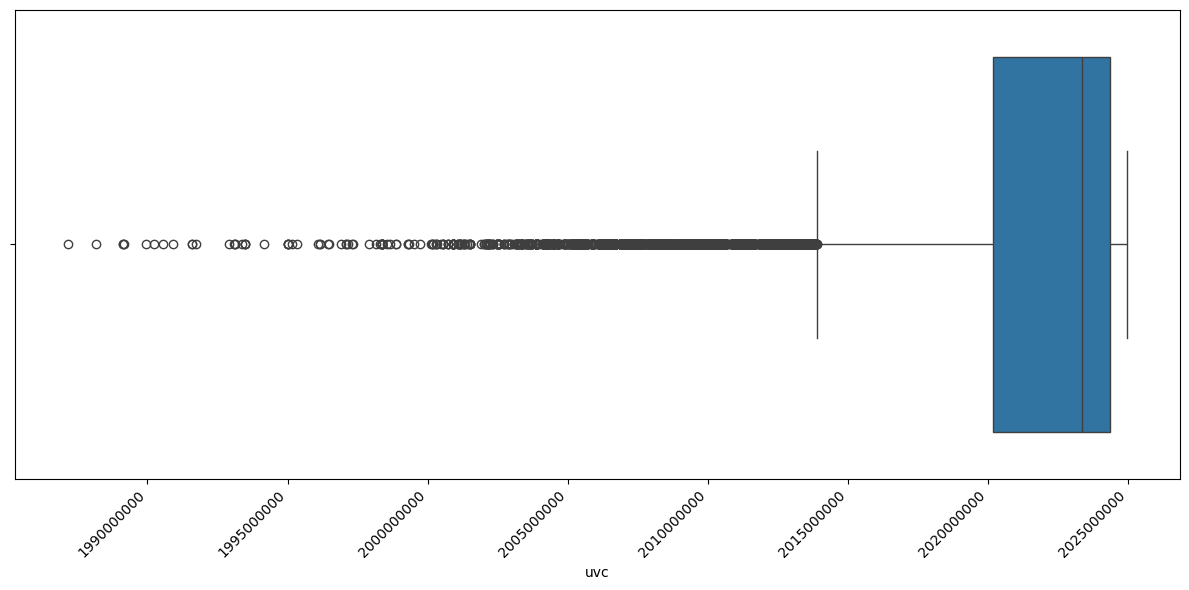

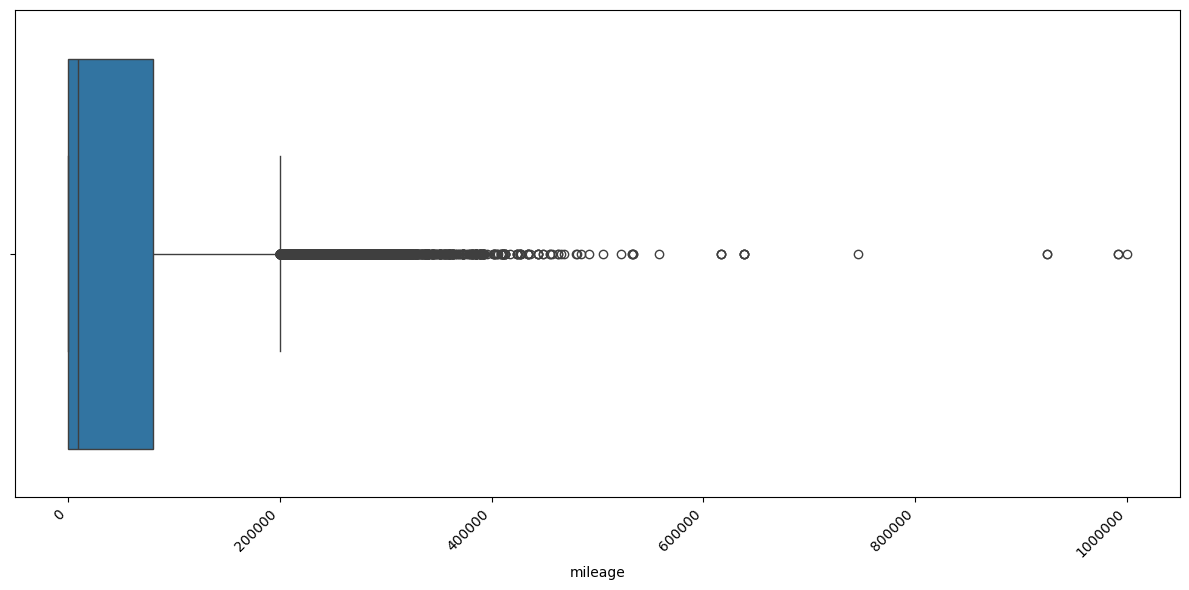

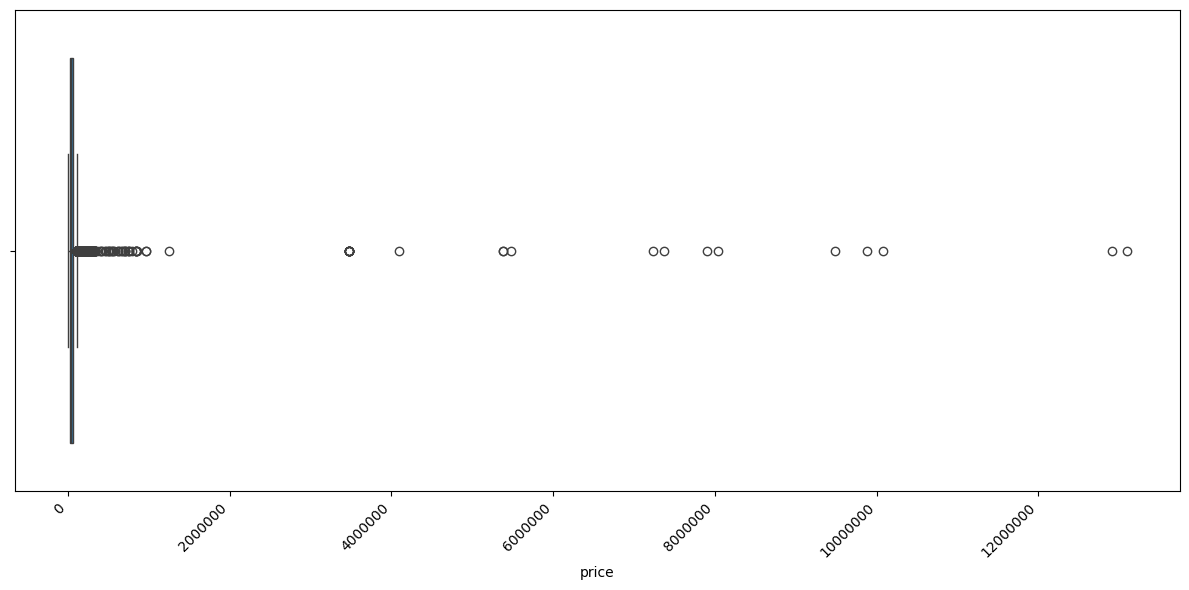

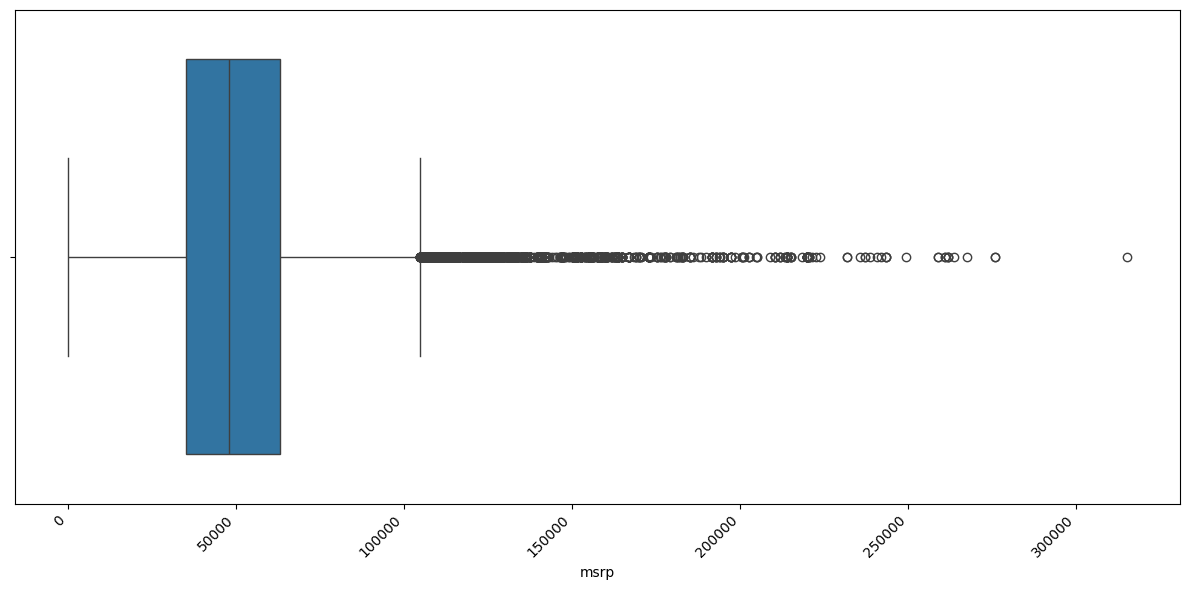

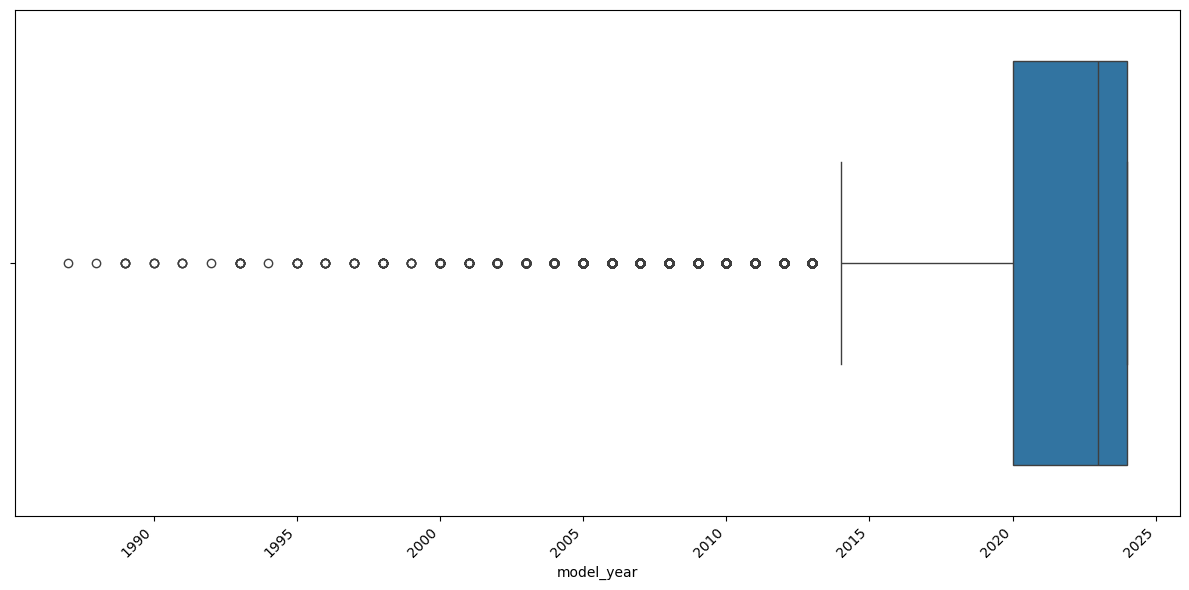

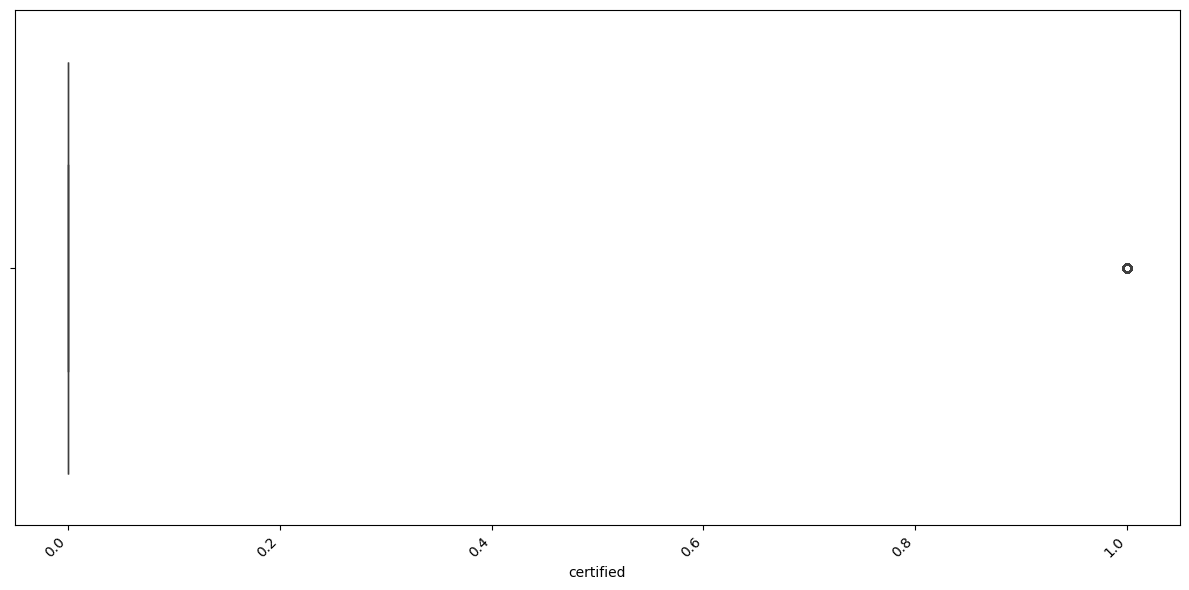

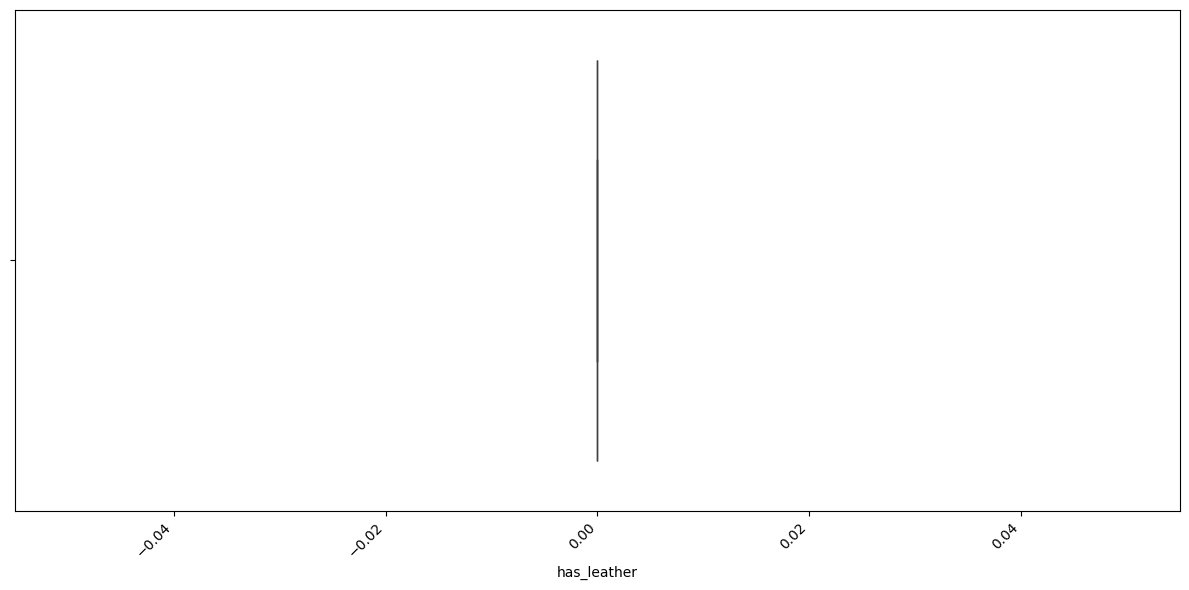

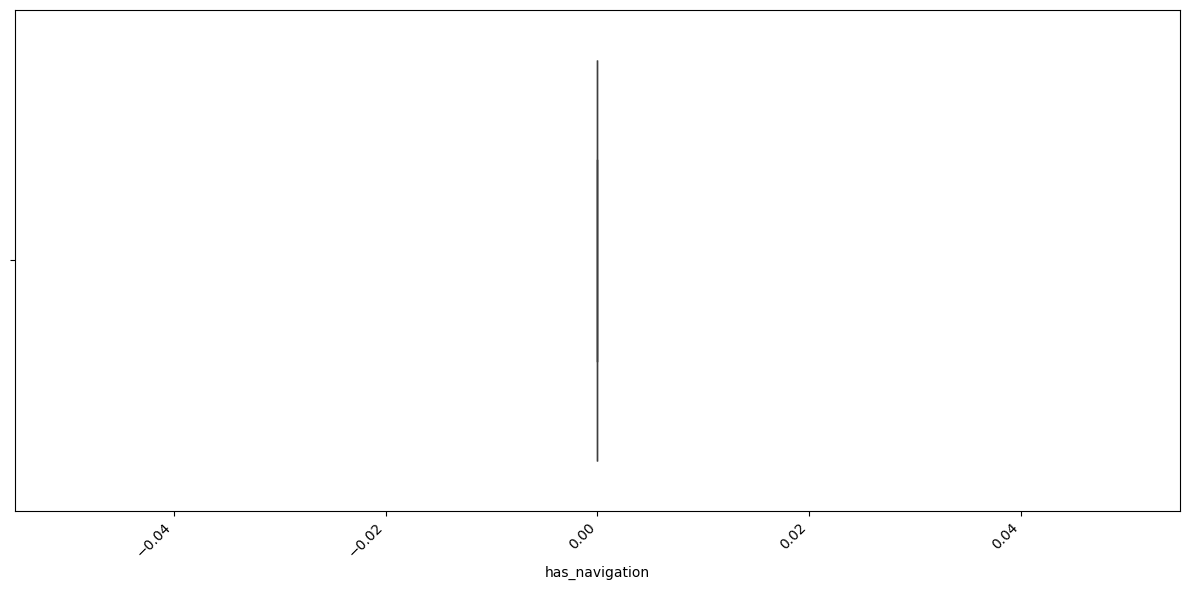

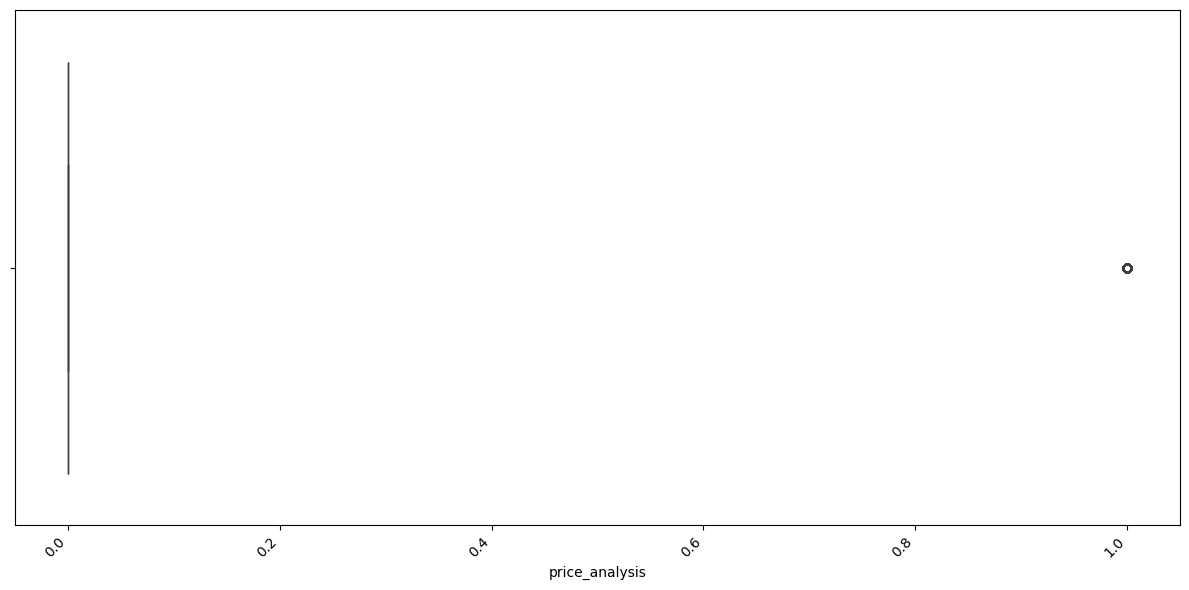

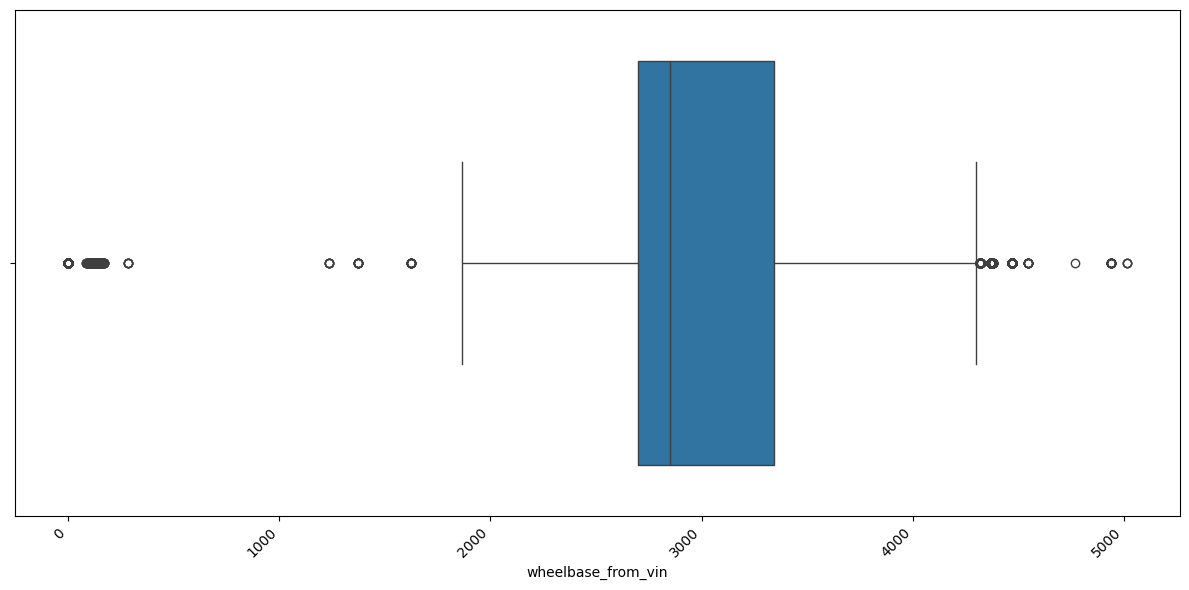

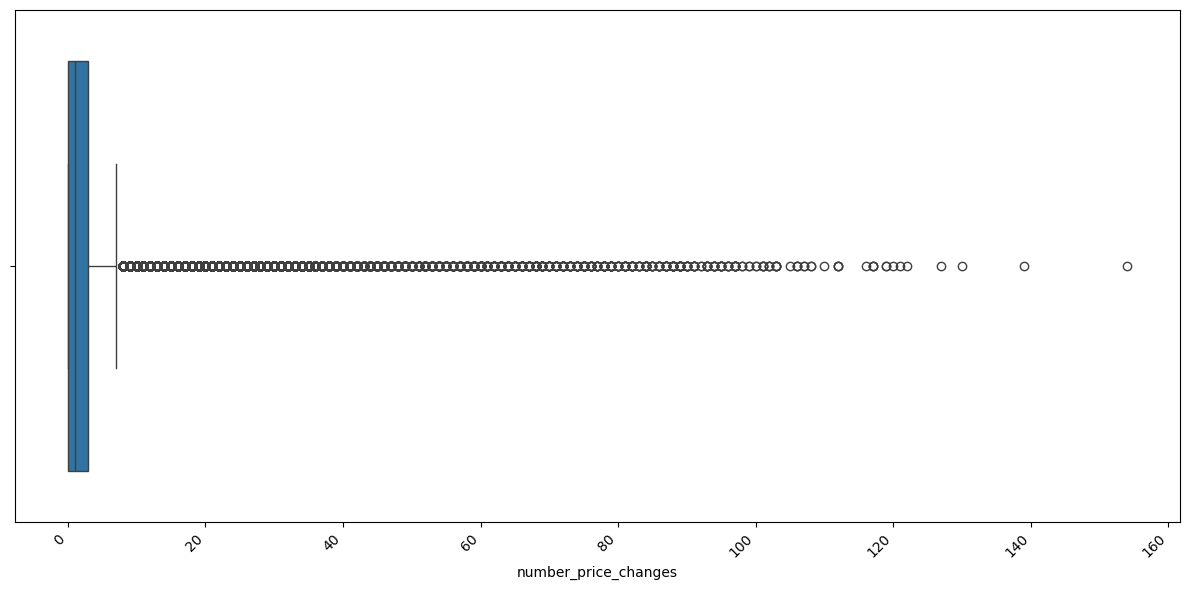

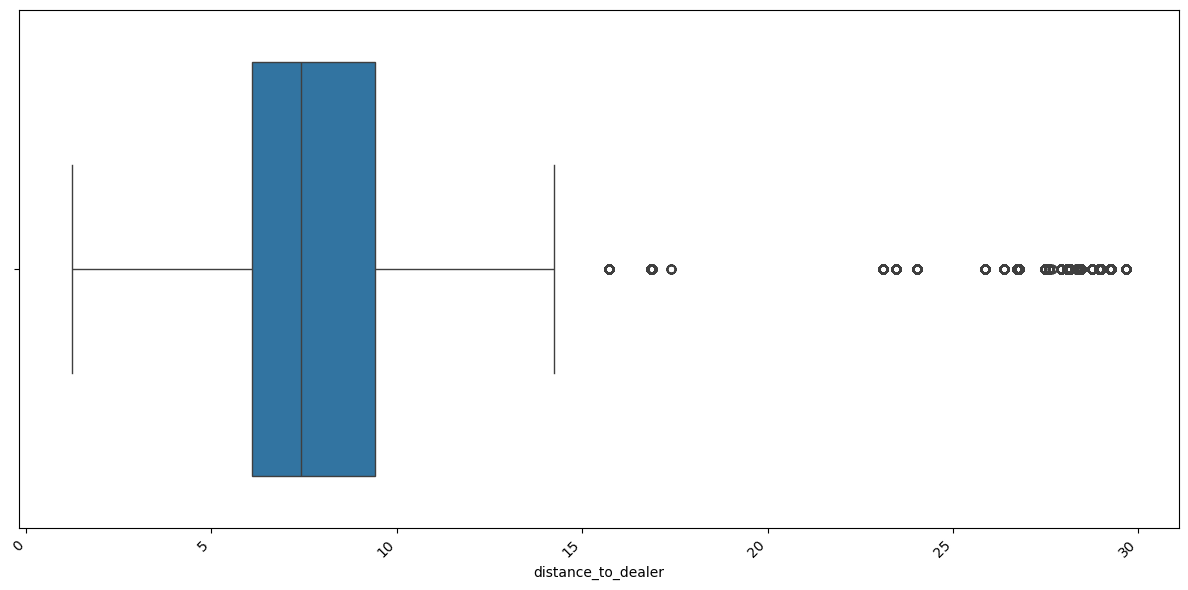

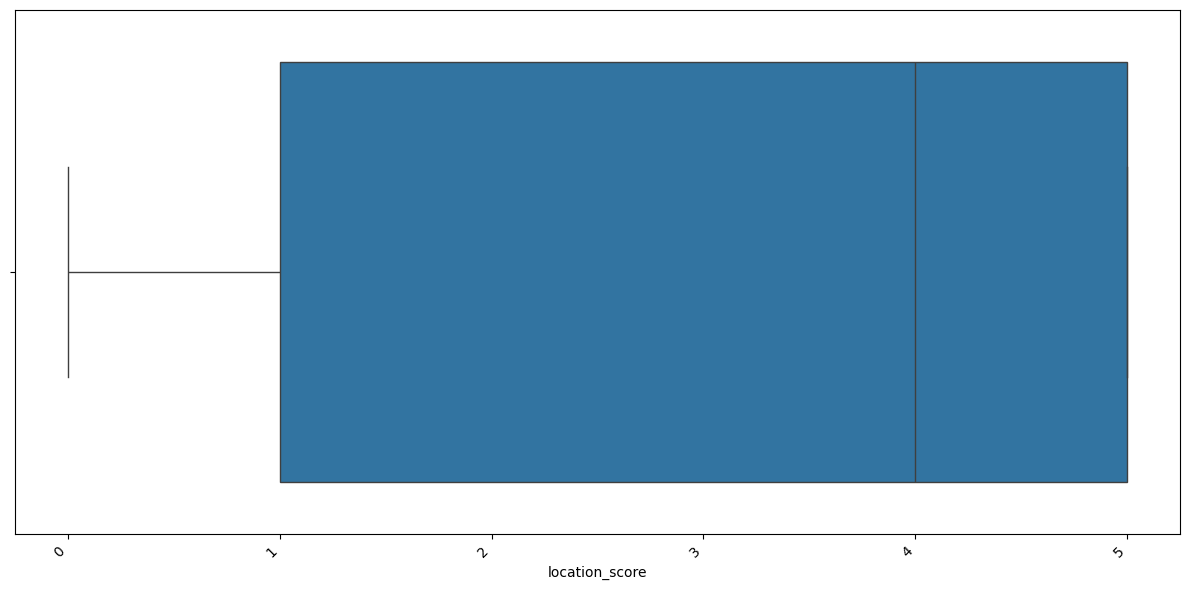

In [ ]:

for i in df.select_dtypes(include='number').columns:
    # Check if the column contains valid numerical data
    if df[i].dtype in [np.int64, np.float64] and not df[i].isnull().all():
        # Create the boxplot if the column is numeric and not all NaN
        plt.figure(figsize=(12, 6))  # Adjust figure size for better readability
        sns.boxplot(data=df, x=i)
        plt.ticklabel_format(style='plain', axis='x')

        # Rotate x-axis labels
        plt.xticks(rotation=45, ha='right')

        plt.tight_layout()  # Adjust layout to prevent labels from being cut off
        plt.show()
    else:
        # Handle the case where the column is not numeric
        print(f"Skipping boxplot for column '{i}' due to non-numeric or missing data.")

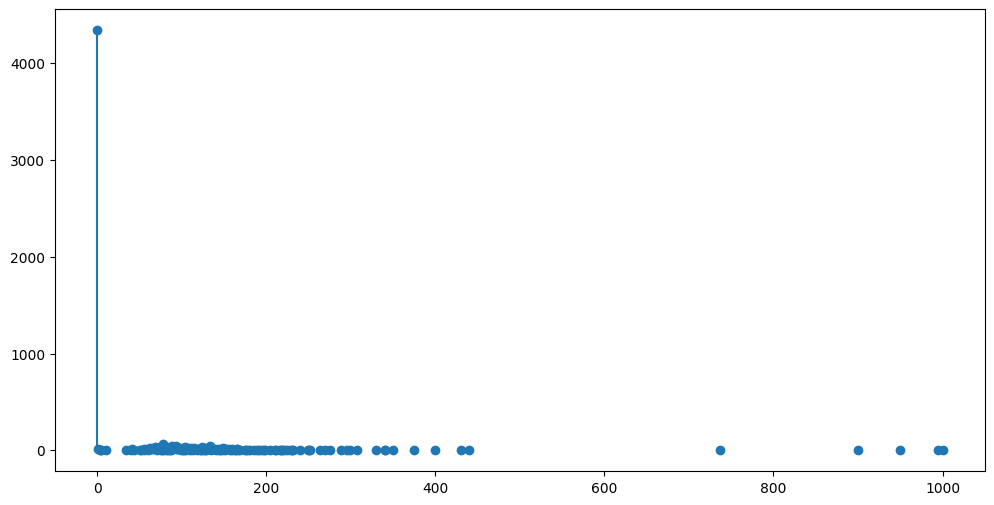

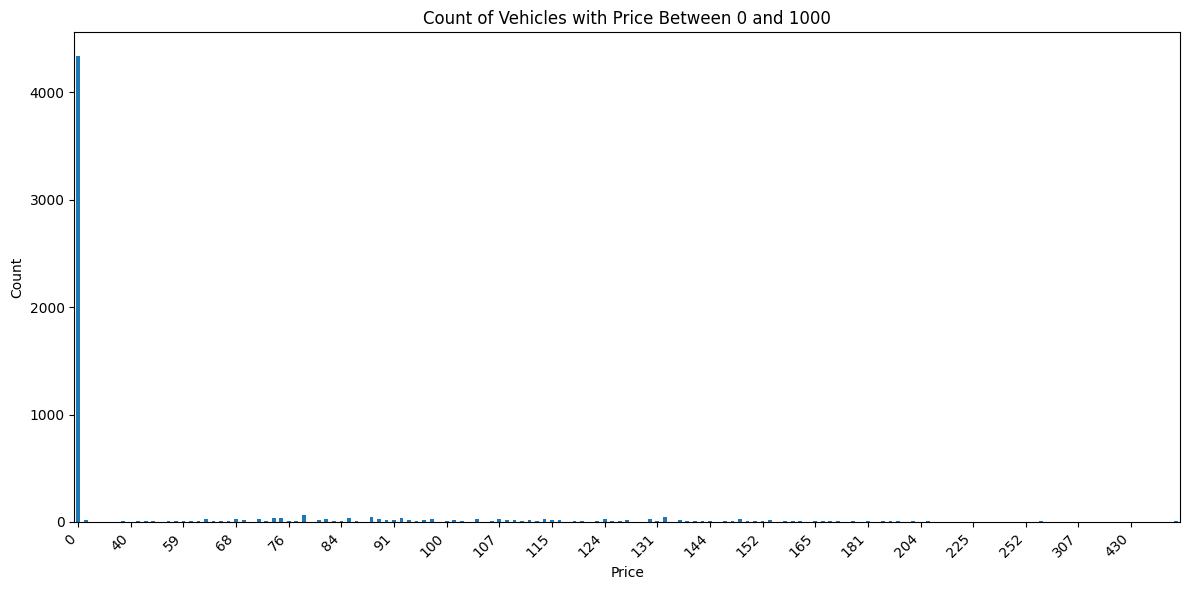

In [ ]:


# Filter rows where price is between 0 and 1000
df_filtered = df[(df['price'] >= 0) & (df['price'] <= 1000)]

# Count occurrences of each price value
price_counts = df_filtered['price'].value_counts().sort_index()

# Create a stem plot (better for sparse data)
plt.figure(figsize=(12, 6))
plt.stem(price_counts.index, price_counts.values, basefmt=" ")

# Plot the counts
plt.figure(figsize=(12, 6))
price_counts.plot(kind='bar')

plt.xlabel("Price")
plt.ylabel("Count")
plt.title("Count of Vehicles with Price Between 0 and 1000")

# Display only every nth label (adjust 10 as needed)
step = max(1, len(price_counts) // 20)  # Show approximately 20 labels
plt.xticks(range(0, len(price_counts), step), price_counts.index[::step], rotation=45, ha='right')

plt.tight_layout()
plt.show()




In [ ]:
df.select_dtypes(exclude='object').columns

Index(['days_on_market', 'dealer_id', 'dealer_email', 'vehicle_id', 'uvc',
       'mileage', 'price', 'msrp', 'model_year', 'certified', 'has_leather',
       'has_navigation', 'price_analysis', 'wheelbase_from_vin',
       'number_price_changes', 'distance_to_dealer', 'location_score'],
      dtype='object')

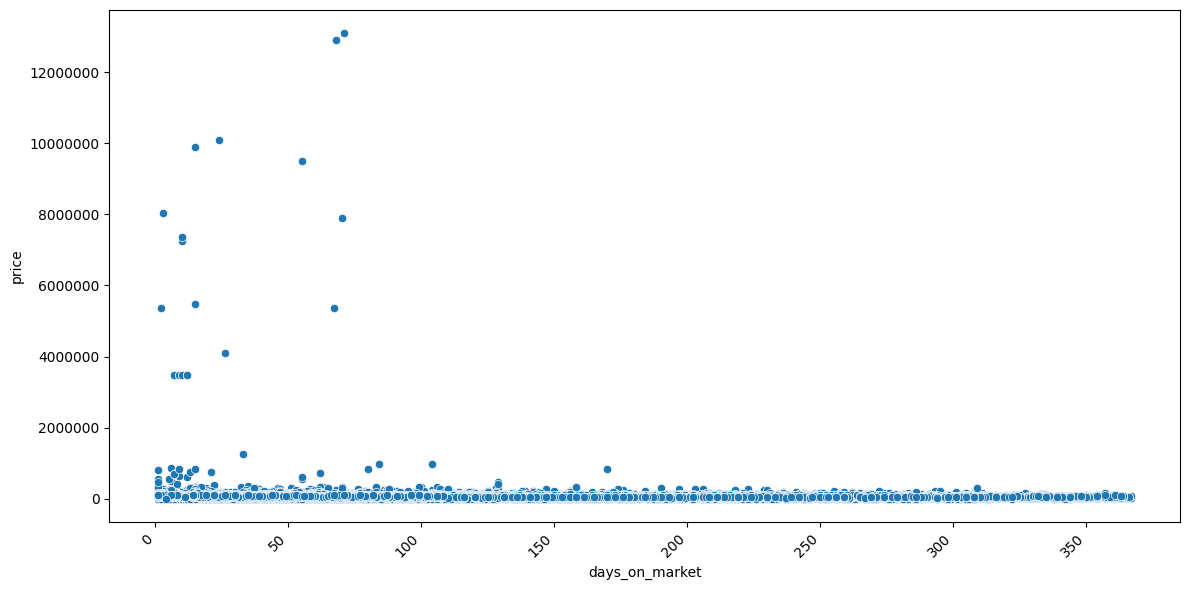

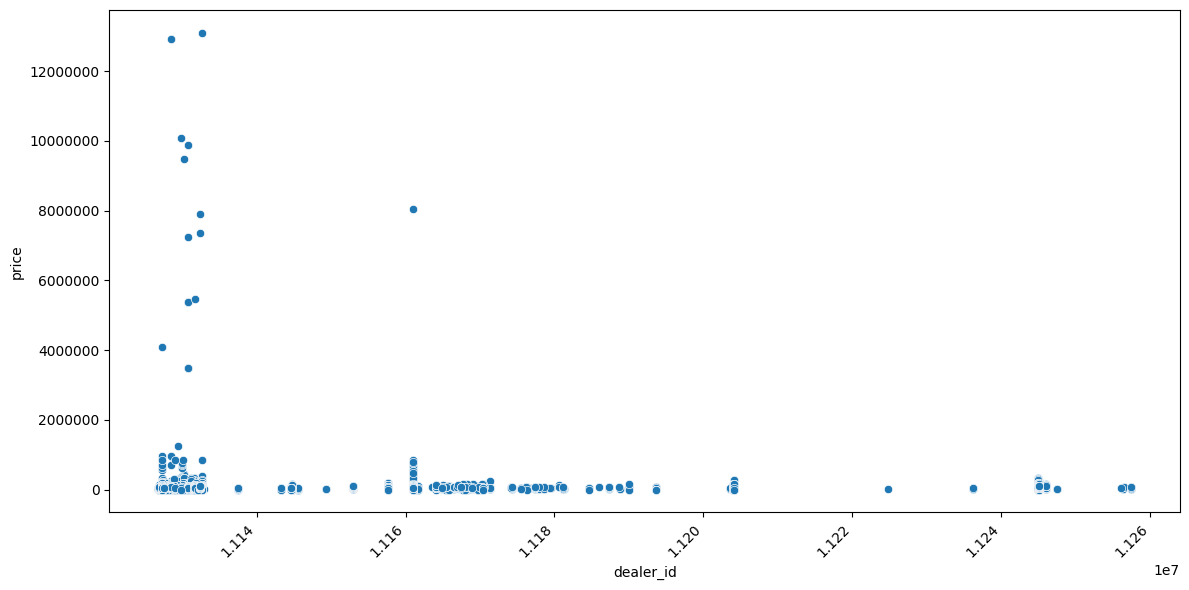

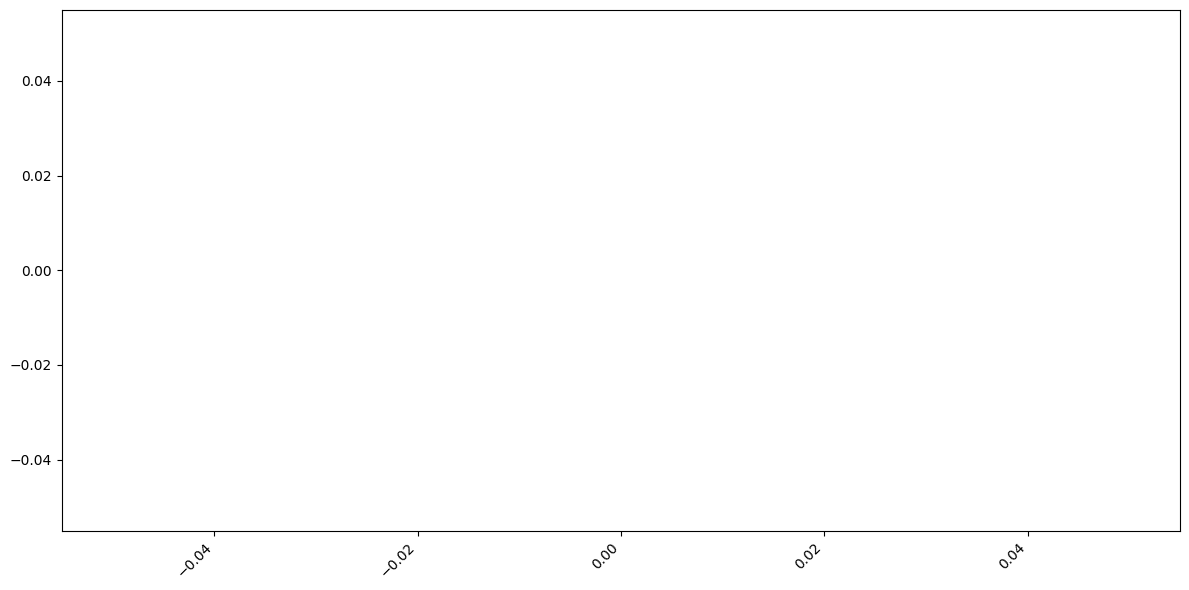

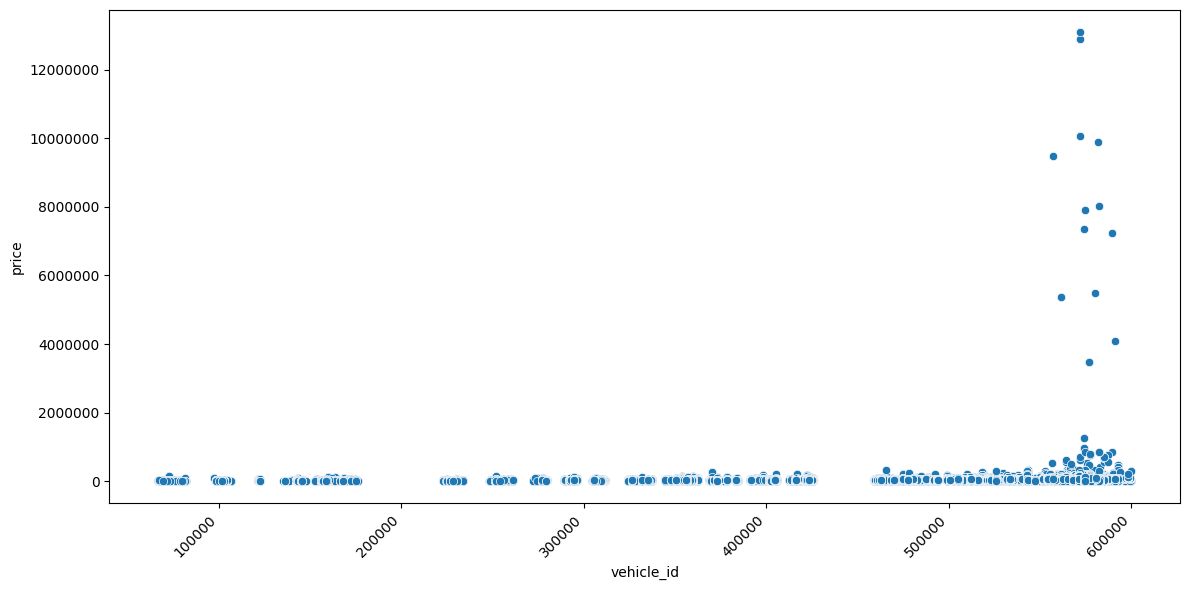

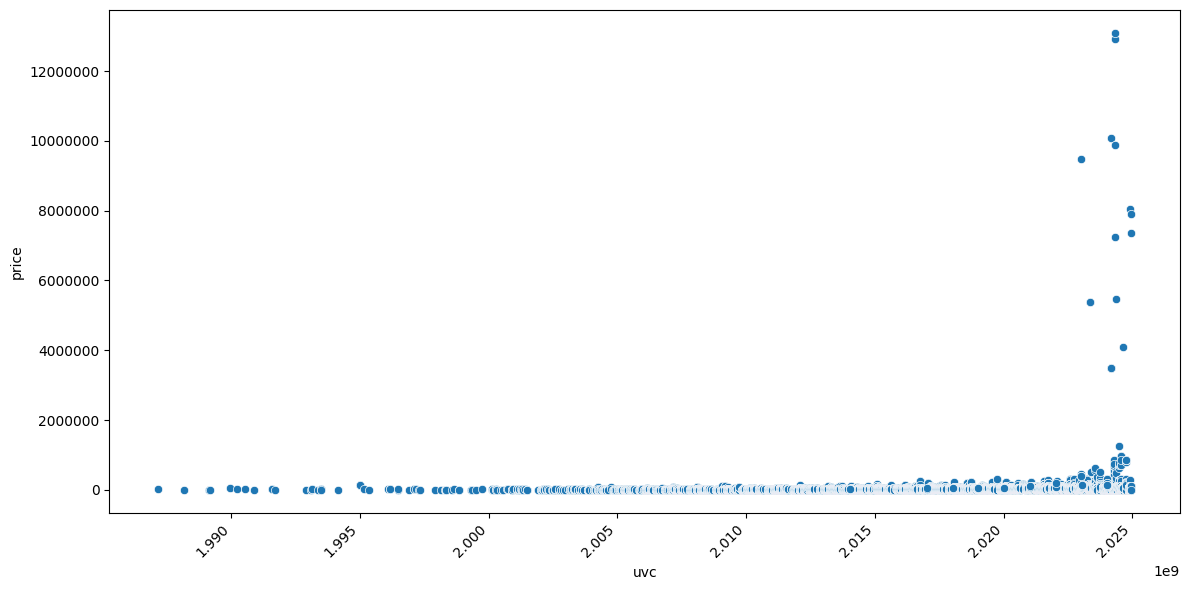

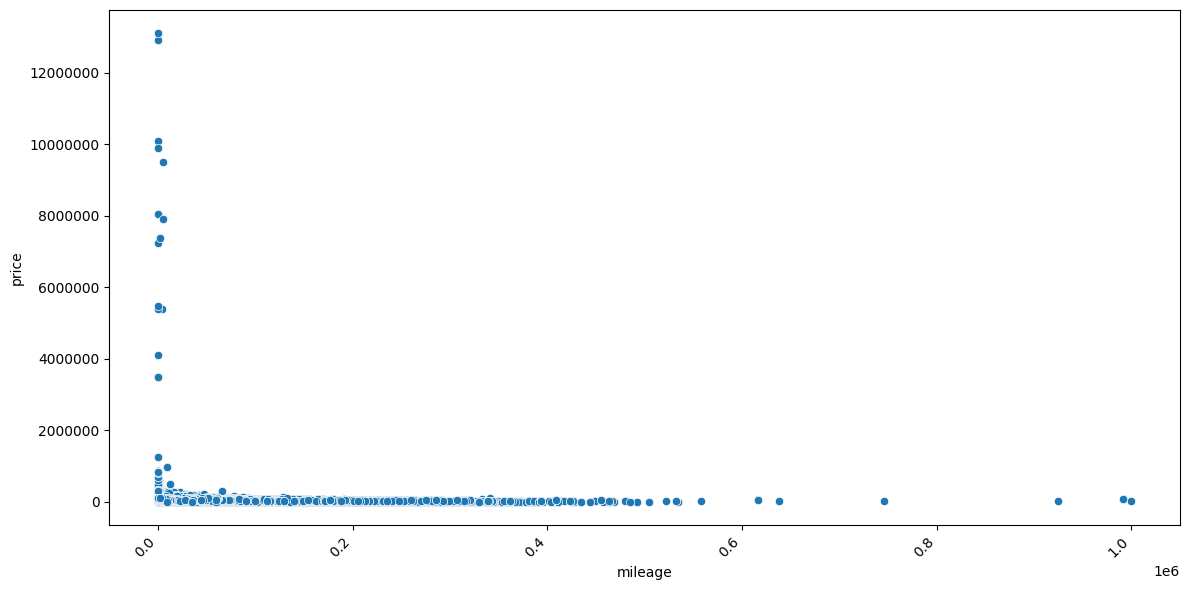

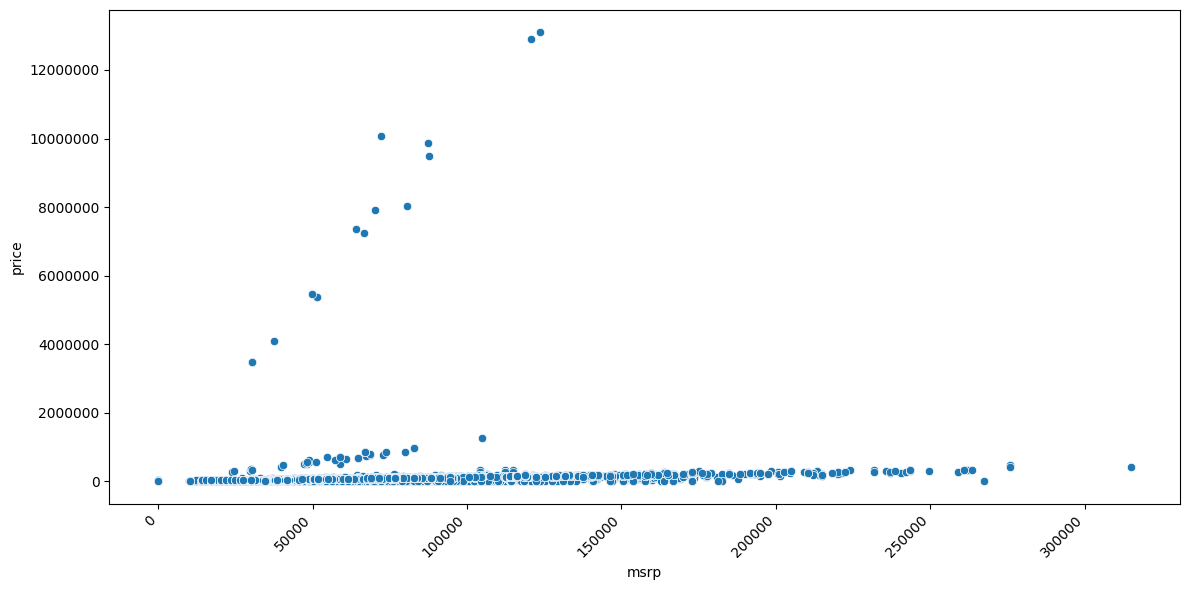

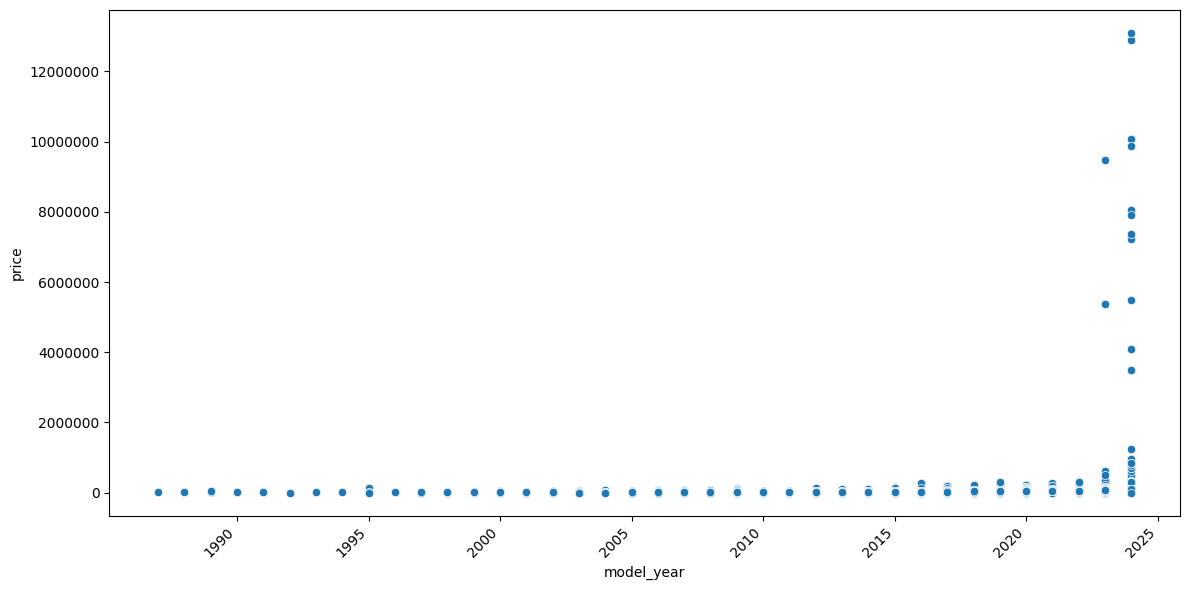

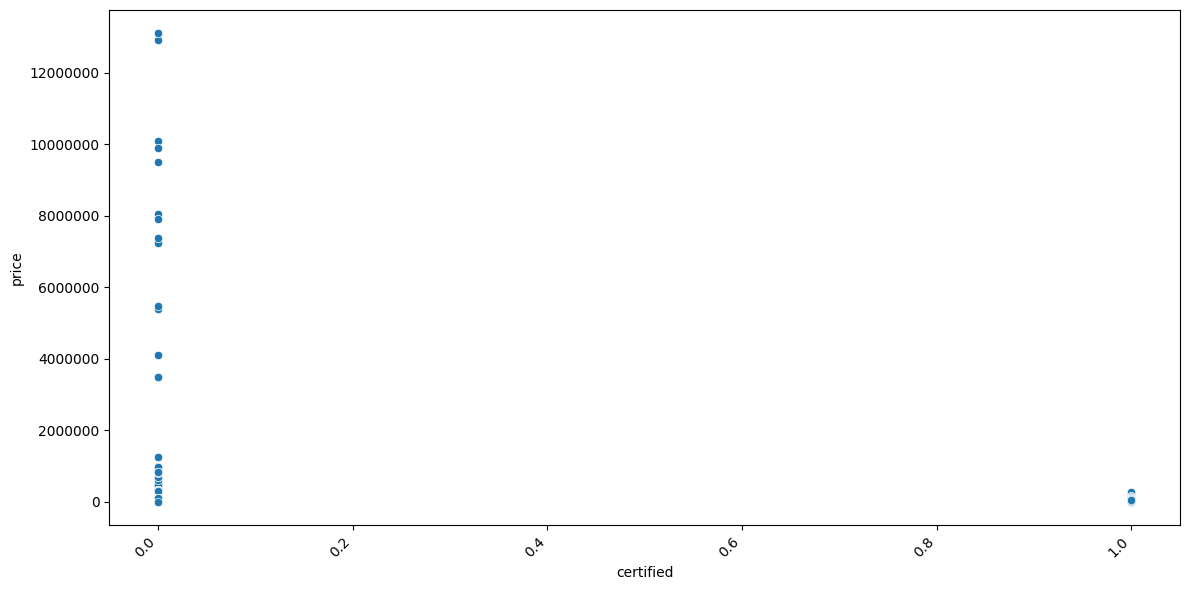

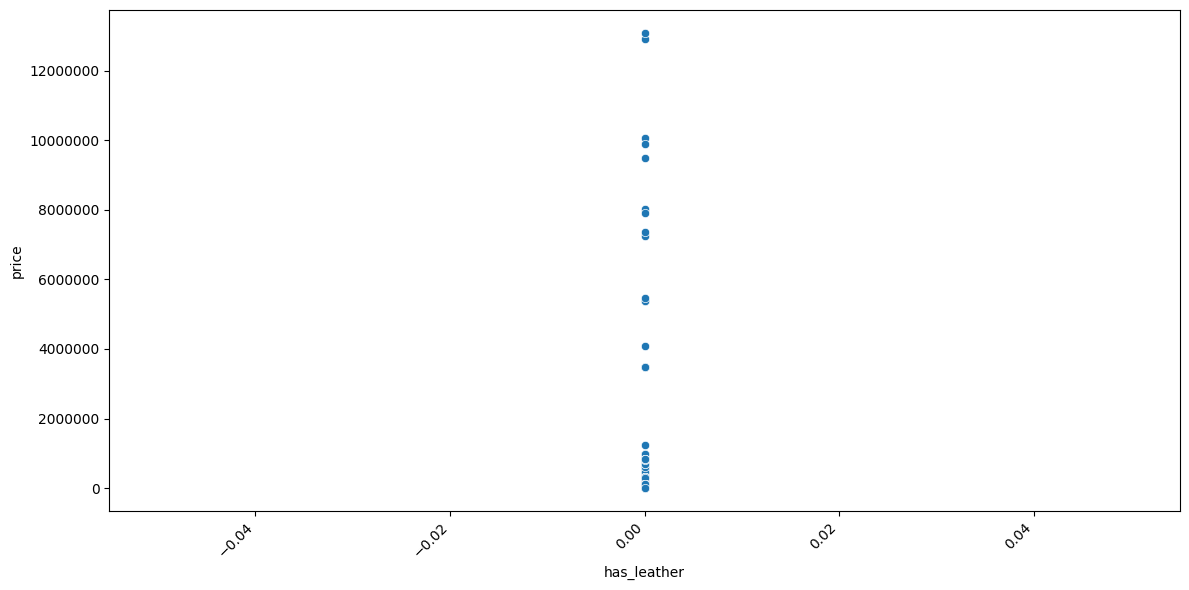

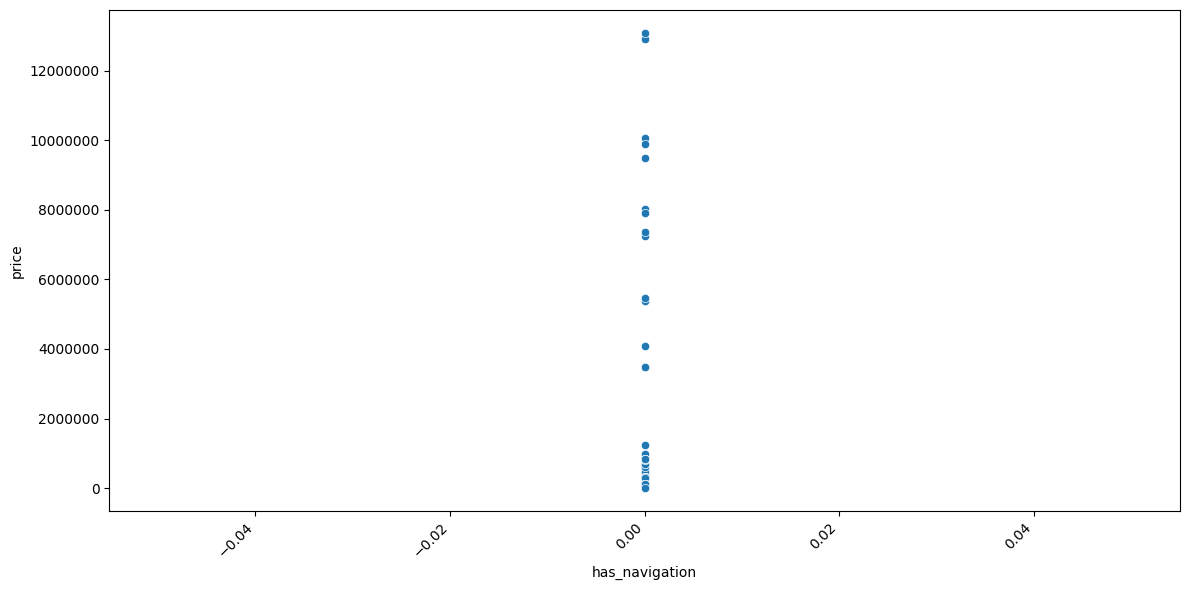

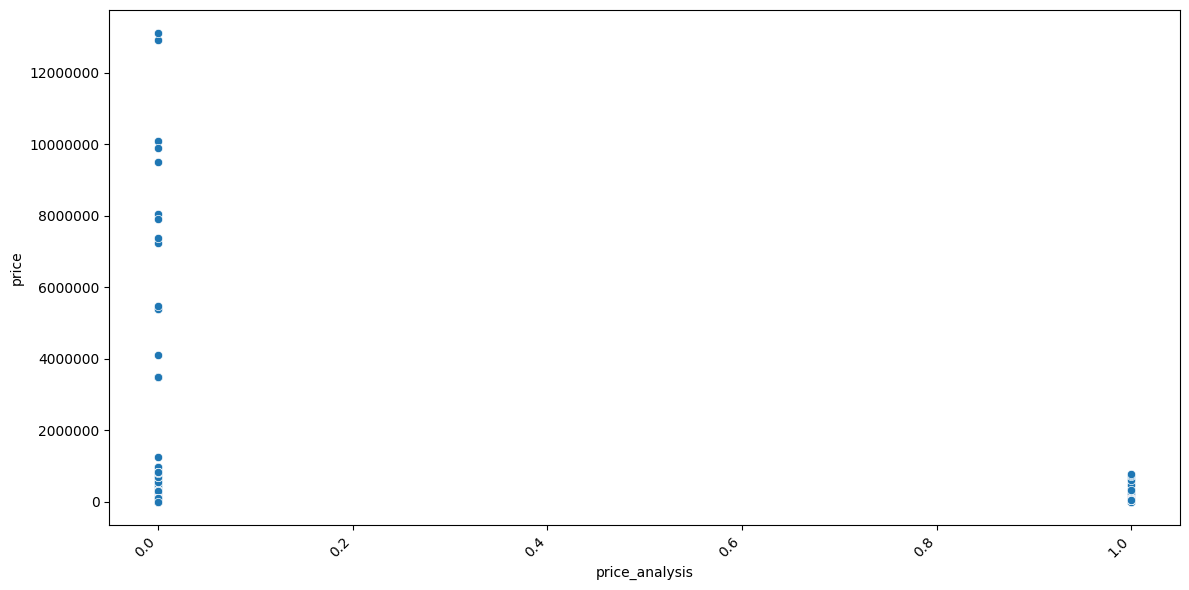

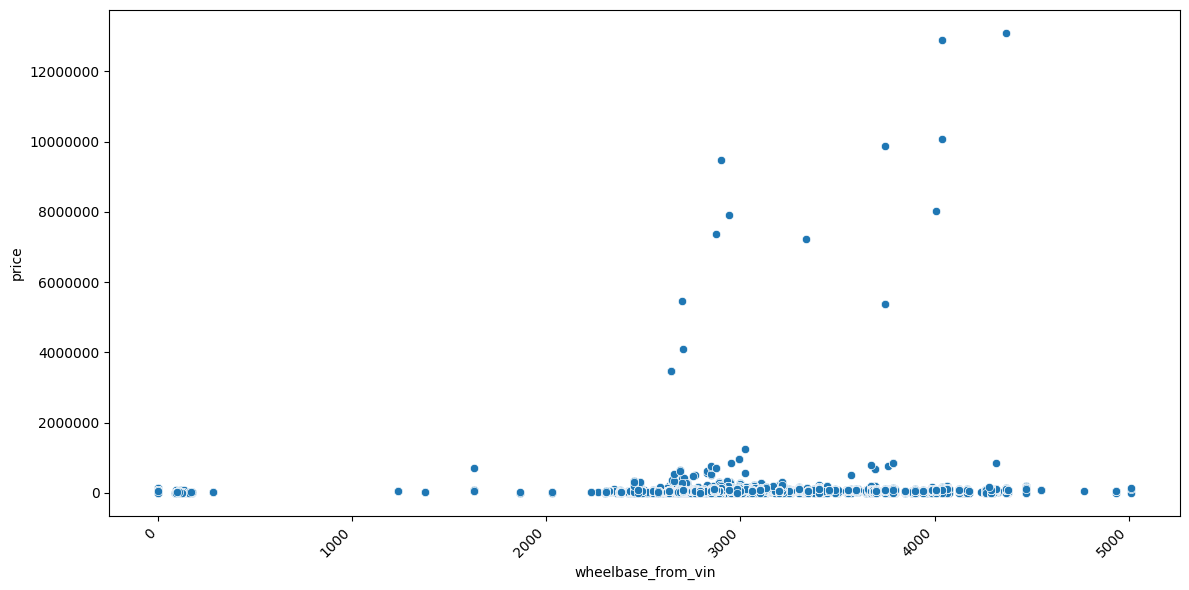

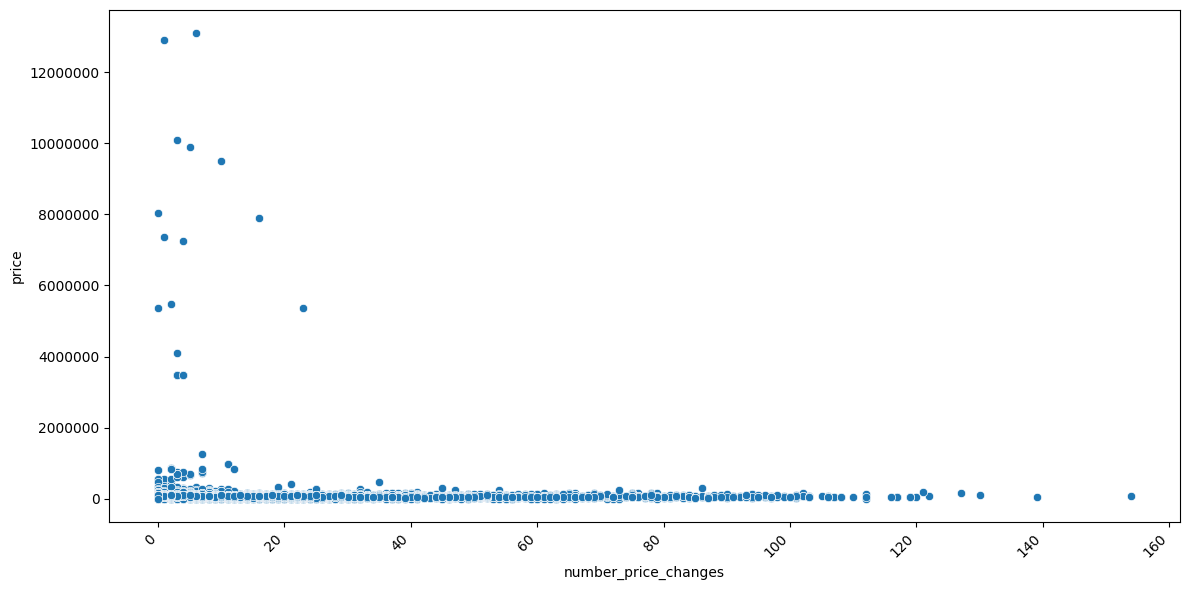

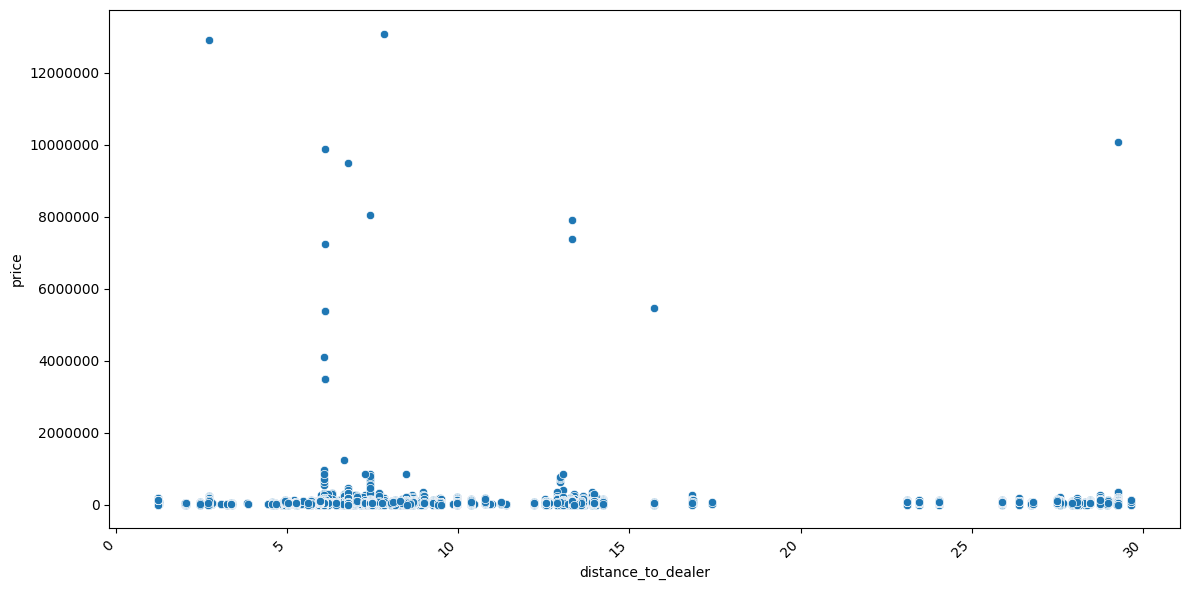

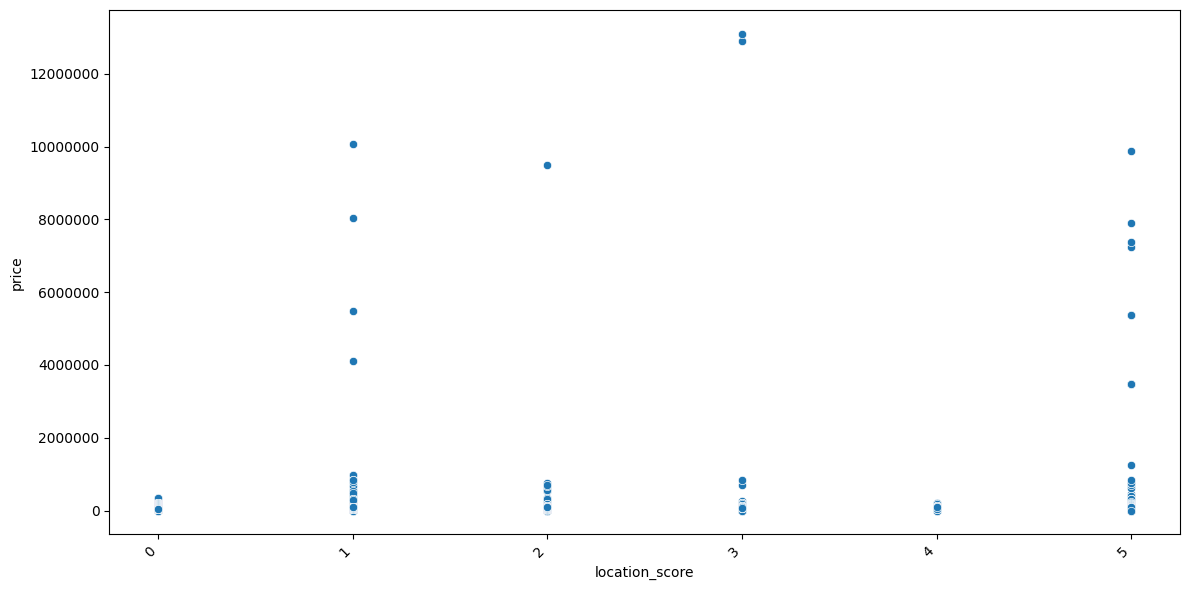

In [ ]:
for i in ['days_on_market', 'dealer_id', 'dealer_email', 'vehicle_id', 'uvc',
       'mileage', 'msrp', 'model_year', 'certified', 'has_leather',
       'has_navigation', 'price_analysis', 'wheelbase_from_vin',
       'number_price_changes', 'distance_to_dealer', 'location_score']:
      plt.figure(figsize=(12, 6))
      sns.scatterplot(data = df, x = i, y = 'price')
      plt.ticklabel_format(style='plain', axis='y')
      plt.xticks(rotation=45, ha='right')
      plt.tight_layout()
      plt.show()

In [ ]:
df.dtypes

,0
listing_id,object
listing_heading,object
listing_type,object
listing_url,object
listing_first_date,object
days_on_market,int64
dealer_id,int64
dealer_name,object
dealer_street,object
dealer_city,object


In [ ]:
df.select_dtypes(include='number').corr()



,days_on_market,dealer_id,dealer_email,vehicle_id,uvc,mileage,price,msrp,model_year,certified,has_leather,has_navigation,price_analysis,wheelbase_from_vin,number_price_changes,distance_to_dealer,location_score
days_on_market,1.000000,-0.333040,NaN,0.088519,0.090708,-0.099379,0.032593,0.086472,0.087565,0.010102,NaN,NaN,-0.032297,0.063354,0.538087,0.002857,-0.012545
dealer_id,-0.333040,1.000000,NaN,0.122341,0.126313,-0.111027,0.028824,0.091762,0.125910,-0.028688,NaN,NaN,-0.022672,0.024594,-0.206535,-0.172095,0.362848
dealer_email,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
vehicle_id,0.088519,0.122341,NaN,1.000000,0.989795,-0.836987,0.168651,0.302331,0.991484,-0.001840,NaN,NaN,-0.037789,0.325177,0.048871,-0.016805,0.042740
uvc,0.090708,0.126313,NaN,0.989795,1.000000,-0.838701,0.167236,0.291577,0.997559,-0.005003,NaN,NaN,-0.035352,0.329674,0.048869,-0.018901,0.052624
mileage,-0.099379,-0.111027,NaN,-0.836987,-0.838701,1.000000,-0.170670,-0.296667,-0.840544,0.005244,NaN,NaN,0.042196,-0.189135,-0.040636,0.028584,-0.056761
price,0.032593,0.028824,NaN,0.168651,0.167236,-0.170670,1.000000,0.263490,0.170740,-0.002013,NaN,NaN,-0.031829,0.152728,0.015601,-0.006875,0.015640
msrp,0.086472,0.091762,NaN,0.302331,0.291577,-0.296667,0.263490,1.000000,0.304345,0.003305,NaN,NaN,-0.064157,0.504725,0.034052,-0.005914,0.048783
model_year,0.087565,0.125910,NaN,0.991484,0.997559,-0.840544,0.170740,0.304345,1.000000,-0.005212,NaN,NaN,-0.041577,0.336500,0.046920,-0.017271,0.048471
certified,0.010102,-0.028688,NaN,-0.001840,-0.005003,0.005244,-0.002013,0.003305,-0.005212,1.000000,NaN,NaN,-0.012171,-0.013565,0.013000,0.000651,0.059089


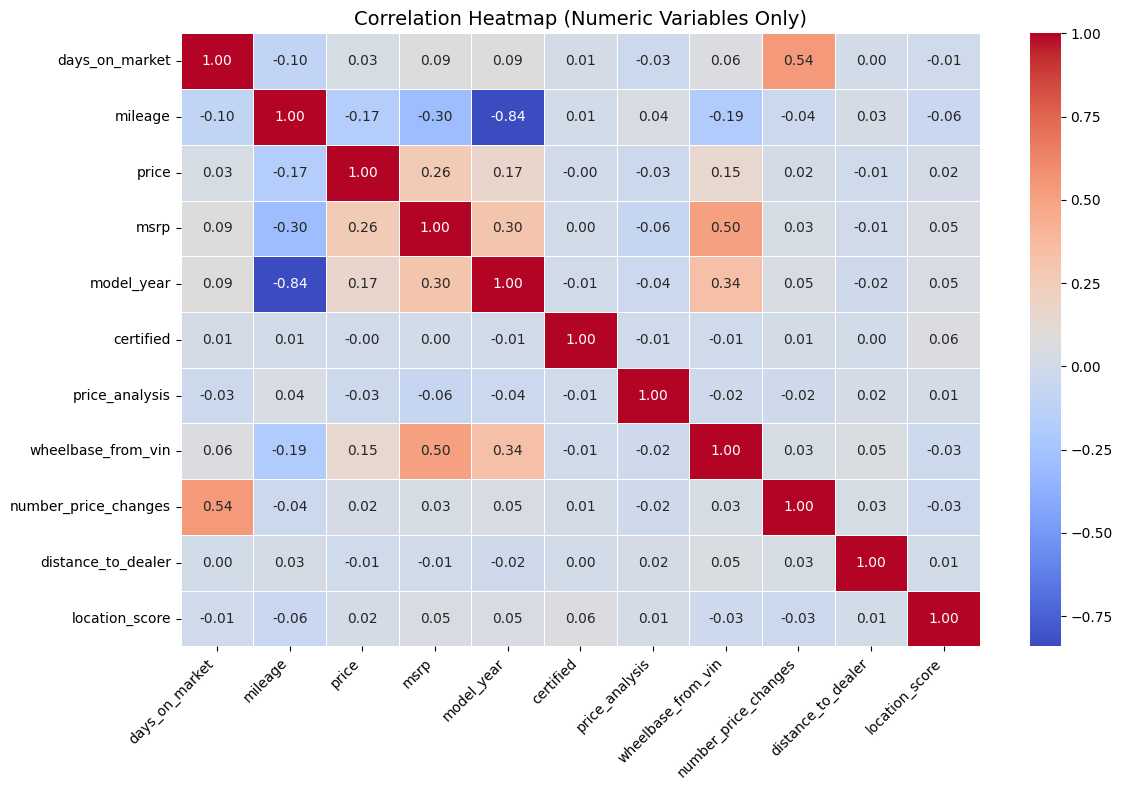

In [ ]:

# Exclude unnecessary columns before computing correlations
excluded_columns = ['dealer_email', 'has_leather', 'has_navigation', 'vehicle_id', 'dealer_id', 'uvc']
numeric_df = df.drop(columns=excluded_columns, errors='ignore').select_dtypes(include='number')

# Compute correlation matrix
corr_matrix = numeric_df.corr()

# Create the heatmap
plt.figure(figsize=(12, 8))  # Increase figure size for better readability
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", annot_kws={"size": 10}, linewidths=0.5)

# Adjust layout for better readability
plt.xticks(rotation=45, ha='right', fontsize=10)  # Rotate x-axis labels for clarity
plt.yticks(fontsize=10)  # Keep y-axis labels readable
plt.title("Correlation Heatmap (Numeric Variables Only)", fontsize=14)  # Add title

plt.tight_layout()  # Prevent overlap
plt.show()


# Step 5 Cleaning and Analysis

In [ ]:

df.isnull().sum()

,0
listing_id,0
listing_heading,4015
listing_type,0
listing_url,0
listing_first_date,0
days_on_market,0
dealer_id,0
dealer_name,0
dealer_street,0
dealer_city,0


In [ ]:


# Find the minimum price per model year
min_price_by_year = df.groupby('model_year')['price'].min()

# Display the years where the minimum price is suspiciously low
print(min_price_by_year[min_price_by_year < 1000])  # Check models priced below $100


model_year
1995    995
2002      0
2006      0
2007      0
2008      0
2009      0
2010      0
2011      0
2012      0
2013      0
2014      0
2015      0
2016      0
2017      0
2018      0
2019      0
2020      0
2021      0
2022      0
2023      0
2024      0
Name: price, dtype: int64


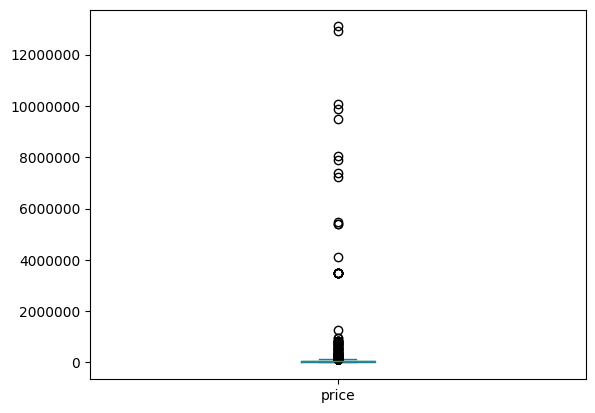

In [ ]:
df['price'].plot(kind='box')
plt.ticklabel_format(style='plain', axis='y')
plt.show()

In [ ]:
df_clean = df.copy()


In [ ]:
# Define a dynamic minimum price threshold per 5-year model year interval
# Define valid price ranges based on the provided list of car makes
def min_valid_price_by_make(make):
    """Assigns minimum valid price based on the vehicle make categories."""

    # Define categories based on pricing expectations
    luxury_brands = [
        'Mercedes-Benz', 'BMW', 'Audi', 'Lexus', 'Porsche', 'Jaguar', 'Land Rover', 'Infiniti',
        'Tesla', 'Maserati', 'Alfa Romeo', 'Genesis', 'Polestar', 'Fisker', 'Rivian'
    ]

    midrange_brands = [
        'Chevrolet', 'Chrysler', 'Cadillac', 'Volkswagen', 'Dodge', 'Mazda', 'Toyota', 'Mercury',
        'Pontiac', 'Honda', 'Jeep', 'Acura', 'GMC', 'Ford', 'Nissan', 'Subaru', 'Buick', 'Lincoln',
        'Volvo', 'Mini'
    ]

    budget_brands = [
        'Kia', 'Saturn', 'Hummer', 'Mitsubishi', 'Suzuki', 'Hyundai', 'Smart', 'Scion', 'Fiat', 'Ram'
    ]

    # Assign minimum price thresholds
    if make in luxury_brands:
        return 20000  # Luxury vehicles shouldn't be priced below $20,000
    elif make in midrange_brands:
        return 7000  # Midrange vehicles shouldn't be below $7,000
    elif make in budget_brands:
        return 3000  # Budget vehicles shouldn't be below $3,000
    else:
        return 5000  # Default minimum price for other makes


# Remove cars with prices lower than the threshold for their model year
#df_clean = df[df.apply(lambda x: x['price'] >= min_valid_price(x['model_year']), axis=1)]

# Remove cars with prices lower than the threshold for their make
df_clean = df_clean[df_clean.apply(lambda x: x['price'] >= min_valid_price_by_make(x['make']), axis=1)]




In [ ]:
df_clean.head() # Display the first few rows of the cleaned DataFrame

,listing_id,listing_heading,listing_type,listing_url,listing_first_date,days_on_market,dealer_id,dealer_name,dealer_street,dealer_city,...,wheelbase_from_vin,drivetrain_from_vin,engine_from_vin,transmission_from_vin,fuel_type_from_vin,number_price_changes,price_history_delimited,distance_to_dealer,location_score,listing_dropoff_date
0,f5b663d2-4896-11ef-a15b-8b4423f1ff08,1987 IROC Z 350 Auto T-Tops,Active,https://www.kijiji.ca/v-cars-trucks/edmonton/1...,7/22/2024 0:00,9,11152931,David T's Camaro & Firebird Auto Center,10611 201 St NW,Edmonton,...,0.0,RWD,5.7L V8 TBI,A,Gas,0,"2024-07-22,11500,230860",9.84,5,NaN
1,a9f565e6-4712-11ef-a23f-79dc25c5e601,NaN,Sold,https://www.redlinemotors.ca/vehicle-details/1...,7/20/2024 0:00,4,11131329,Redlinemotors.Ca,14421 Mark Messier Trail,Edmonton,...,0.0,RWD,5.2L V8,A,Gas,0,"2024-07-20,8700,48905",8.30,5,7/24/2024 0:00
4,53a8e550-47cd-11ef-8587-f926ecb61035,1989 Camaro IROC 350 Auto T-Top,Active,https://www.kijiji.ca/v-cars-trucks/edmonton/1...,7/21/2024 0:00,10,11152931,David T's Camaro & Firebird Auto Center,10611 201 St NW,Edmonton,...,0.0,RWD,5.7L V8 TBI,A,Gas,0,"2024-07-21,8500,288000",9.84,5,NaN
5,fc5a68be-ebdc-11ee-9da5-e5e9808f13ef,1989 Volkswagen Cabrio,Sold,https://www.southgatevw.ca/inventory/used-1989...,3/26/2024 0:00,38,11131738,Southgate Volkswagen,1223 101 St SW,Edmonton,...,0.0,FWD,1.8L I-4 MPI,A,Gas,13,"2024-03-26,40525,198839:2024-03-29,41055,19883...",13.37,5,5/3/2024 0:00
6,4e9e38f4-2927-11ef-b663-8f640adf7e4f,1990 Dodge D150 | 318 ENGINE UPGRADED TO 340 C...,Active,https://www.stalbertdodge.com/vehicles/1990/do...,6/12/2024 0:00,49,11131780,St. Albert Dodge,1155 St Albert Trl,St Albert,...,0.0,RWD,5.2L V8 MPI,A,Gas,1,"2024-06-12,34900,21364:2024-07-11,29900,21364",16.84,5,NaN


In [ ]:

df_clean.shape   # Check the number of rows after filtering


(137519, 46)

In [ ]:
# # Define a dynamic minimum price threshold per model year
# def min_valid_price(model_year):
#     if model_year < 2000:
#         return 2500  # Older cars can have lower prices
#     elif model_year < 2015:
#         return 5000  # Mid-range cars should have a reasonable floor
#     else:
#         return 5000  # Newer models (2015+) should not be below $5000

# # Remove cars with prices lower than the threshold for their model year
# df_clean = df_clean[df_clean.apply(lambda x: x['price'] >= min_valid_price(x['model_year']), axis=1)]




In [ ]:
print(df_clean.groupby('model_year')['price'].min())  # Ensure no unrealistic prices remain


model_year
1987    11500
1988     8700
1989     8500
1990    19900
1991     9500
1993     9995
1994     8500
1995    29000
1996    12997
1997     8500
1998     9999
1999     9950
2000     7999
2001     7500
2002     3800
2003     4998
2004     4700
2005     4998
2006     3609
2007     3500
2008     3609
2009     3995
2010     3612
2011     3000
2012     3500
2013     4500
2014     4500
2015     3000
2016     6495
2017     7500
2018     3099
2019     7999
2020     7499
2021    14270
2022    15907
2023    18995
2024     9118
Name: price, dtype: int64


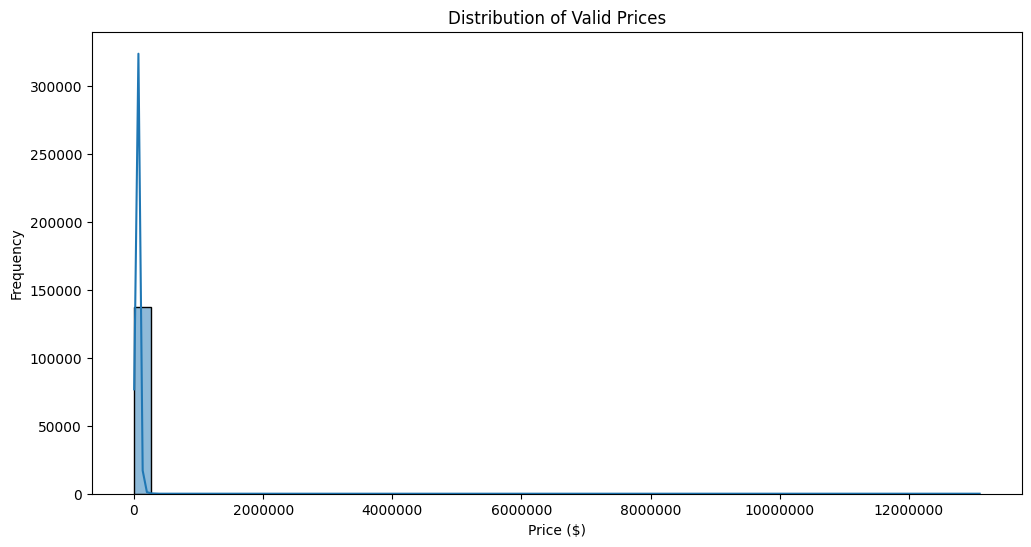

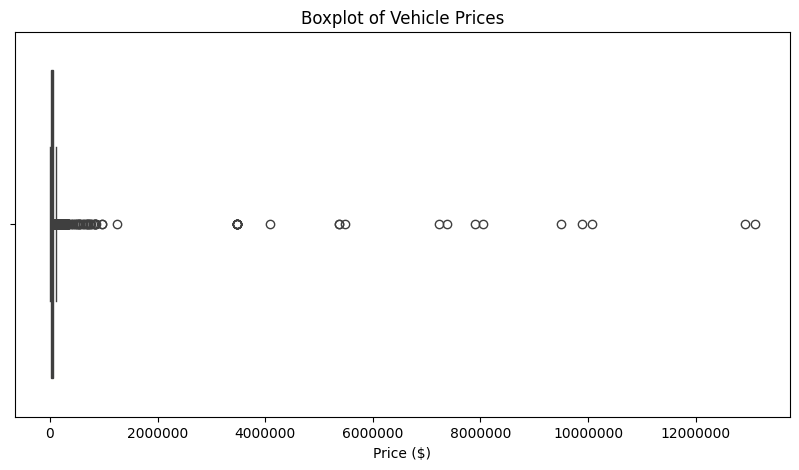

Summary Statistics of Valid Prices:
count    1.375190e+05
mean     5.038768e+04
std      9.251255e+04
min      3.000000e+03
25%      2.899900e+04
50%      4.355900e+04
75%      6.398000e+04
max      1.309532e+07
Name: price, dtype: float64


In [ ]:


# Step 1: Plot the distribution of valid prices
plt.figure(figsize=(12, 6))
sns.histplot(df_clean['price'], bins=50, kde=True)
plt.title("Distribution of Valid Prices")
plt.xlabel("Price ($)")
plt.ylabel("Frequency")
plt.ticklabel_format(style='plain', axis='x')
plt.show()

# Step 2: Boxplot to identify potential remaining outliers
plt.figure(figsize=(10, 5))
sns.boxplot(x=df_clean['price'])
plt.title("Boxplot of Vehicle Prices")
plt.xlabel("Price ($)")
plt.ticklabel_format(style='plain', axis='x')
plt.show()

# Step 3: Summary statistics to check the price range
price_summary = df_clean['price'].describe()

# Display summary statistics
print("Summary Statistics of Valid Prices:")
print(price_summary)


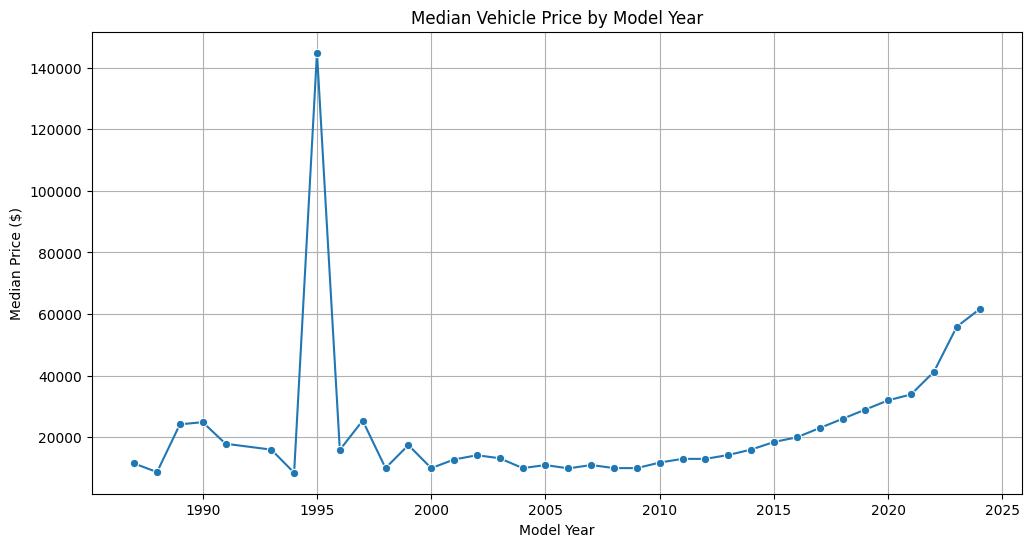

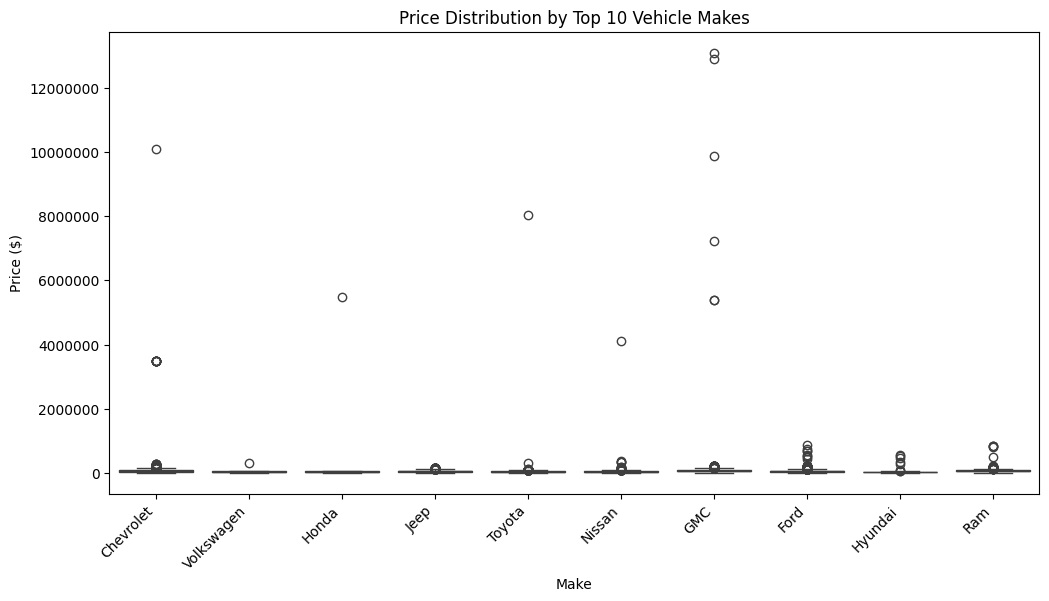

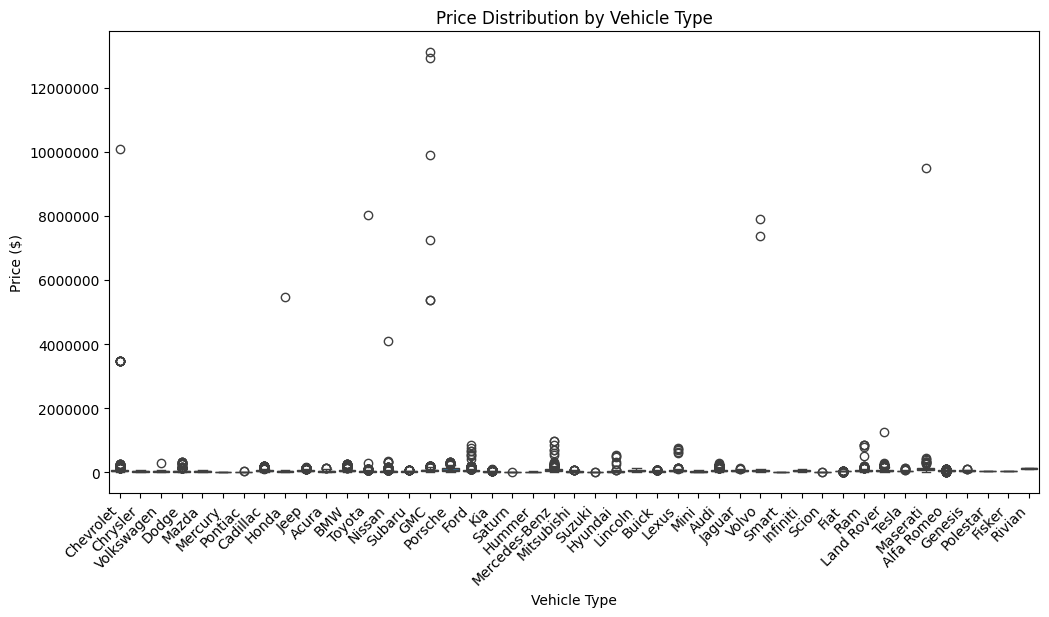

Summary Statistics of Price Trends by Model Year and Make:
     model_year        make    price
0          1987   Chevrolet  11500.0
1          1988    Chrysler   8700.0
2          1989   Chevrolet   8500.0
3          1989  Volkswagen  39900.0
4          1990       Dodge  29900.0
..          ...         ...      ...
677        2024      Subaru  41012.0
678        2024       Tesla  65988.0
679        2024      Toyota  52520.0
680        2024  Volkswagen  49407.5
681        2024       Volvo  79782.0

[682 rows x 3 columns]


In [ ]:
# Step 1: Price Trends by Model Year
plt.figure(figsize=(12, 6))
sns.lineplot(x=df_clean.groupby('model_year')['price'].median().index,
             y=df_clean.groupby('model_year')['price'].median().values, marker='o')
plt.title("Median Vehicle Price by Model Year")
plt.xlabel("Model Year")
plt.ylabel("Median Price ($)")
plt.grid(True)
plt.ticklabel_format(style='plain', axis='y')
plt.ticklabel_format(style='plain', axis='x')
plt.show()

# Step 2: Price Trends by Make (Top 10 Makes)
top_makes = df_clean['make'].value_counts().index[:10]  # Select top 10 makes
plt.figure(figsize=(12, 6))
sns.boxplot(x=df_clean[df_clean['make'].isin(top_makes)]['make'], y=df_clean['price'])
plt.xticks(rotation=45, ha='right')
plt.title("Price Distribution by Top 10 Vehicle Makes")
plt.xlabel("Make")
plt.ylabel("Price ($)")
plt.ticklabel_format(style='plain', axis='y')
plt.show()

# Step 3: Price Trends by Vehicle Type
plt.figure(figsize=(12, 6))
sns.boxplot(x=df_clean['make'], y=df_clean['price'])
plt.xticks(rotation=45, ha='right')
plt.title("Price Distribution by Vehicle Type")
plt.xlabel("Vehicle Type")
plt.ylabel("Price ($)")
plt.ticklabel_format(style='plain', axis='y')
plt.show()

# Step 4: Display summary statistics of price trends by model year and make
price_trends_summary = df_clean.groupby(['model_year', 'make'])['price'].median().reset_index()

# Display the summary statistics
print("Summary Statistics of Price Trends by Model Year and Make:")
print(price_trends_summary)


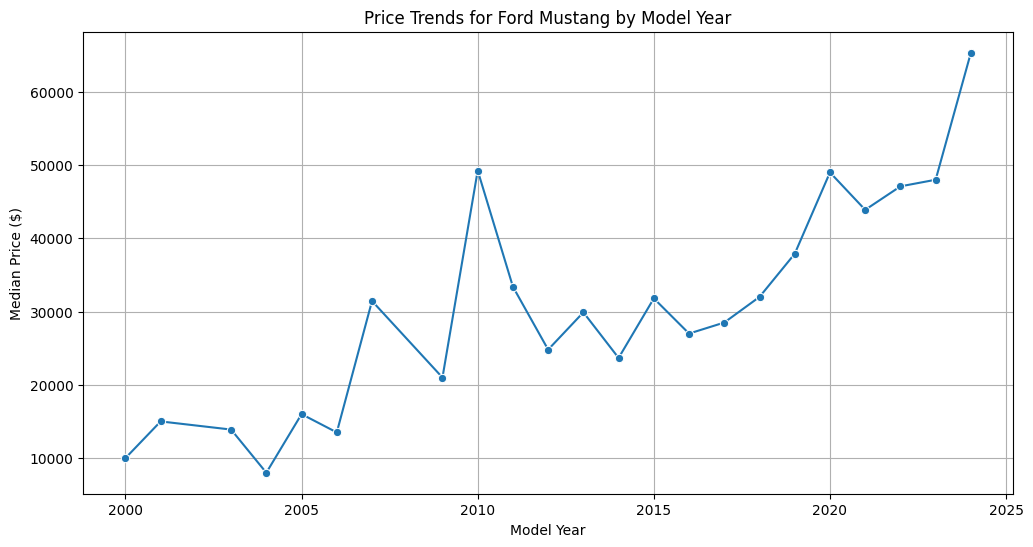

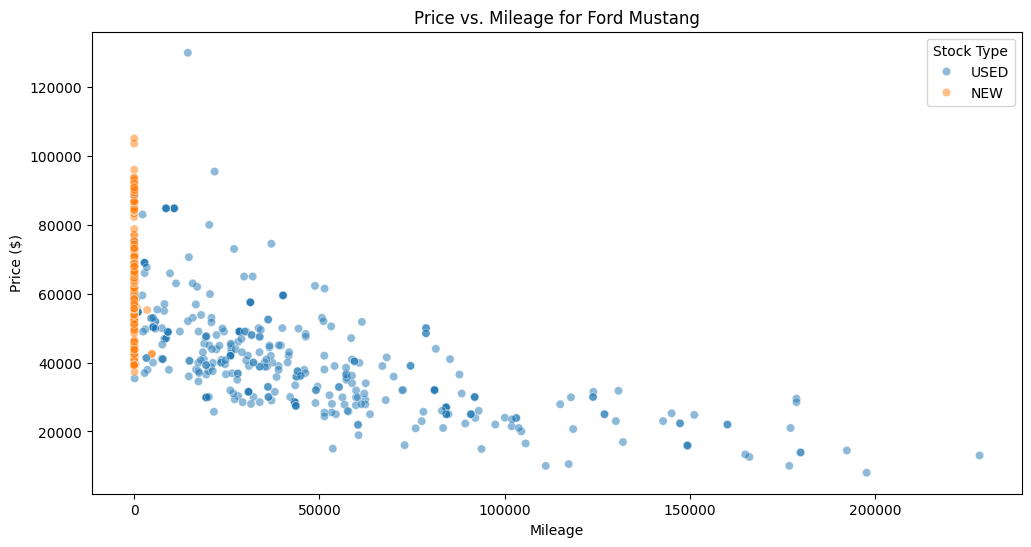

Summary Statistics for Ford Mustang:
    model_year stock_type    price
0         2000       USED   9988.0
1         2001       USED  15000.0
2         2003       USED  13888.0
3         2004       USED   7995.0
4         2005       USED  15995.0
5         2006       USED  13498.5
6         2007       USED  31443.5
7         2009       USED  20990.0
8         2010       USED  49249.5
9         2011       USED  33388.0
10        2012       USED  24800.0
11        2013       USED  29894.5
12        2014       USED  23668.0
13        2015       USED  31797.0
14        2016       USED  26995.0
15        2017       USED  28500.0
16        2018       USED  32000.0
17        2019       USED  37891.0
18        2020       USED  48999.0
19        2021       USED  43888.0
20        2022        NEW  42511.0
21        2022       USED  47180.0
22        2023        NEW  58419.5
23        2023       USED  47642.0
24        2024        NEW  65370.0
25        2024       USED  63990.0


In [ ]:
# Step 1: Allow filtering for a specific brand
selected_make = "Ford"  # Change as needed
selected_vehicle_type = "Mustang"  # Change as needed

filtered_df = df_clean[(df_clean['make'] == selected_make) & (df_clean['model'] == selected_vehicle_type)]

# Step 2: Plot Price Trends by Model Year for Selected Brand & Vehicle Type
plt.figure(figsize=(12, 6))
sns.lineplot(x=filtered_df.groupby('model_year')['price'].median().index,
             y=filtered_df.groupby('model_year')['price'].median().values, marker='o')
plt.title(f"Price Trends for {selected_make} {selected_vehicle_type} by Model Year")
plt.xlabel("Model Year")
plt.ylabel("Median Price ($)")
plt.grid(True)
plt.ticklabel_format(style='plain', axis='y')
plt.ticklabel_format(style='plain', axis='x')
plt.show()

# Step 3: Adjust Price Trends Based on Mileage and Stock Type
plt.figure(figsize=(12, 6))
sns.scatterplot(x=filtered_df['mileage'], y=filtered_df['price'], hue=filtered_df['stock_type'], alpha=0.5)
plt.title(f"Price vs. Mileage for {selected_make} {selected_vehicle_type}")
plt.xlabel("Mileage")
plt.ylabel("Price ($)")
plt.legend(title="Stock Type")
plt.ticklabel_format(style='plain', axis='x')
plt.ticklabel_format(style='plain', axis='y')
plt.show()

# Step 4: Summary Statistics for the Selected Brand & Vehicle Type
price_summary_filtered = filtered_df.groupby(['model_year', 'stock_type'])['price'].median().reset_index()

# Display the summary statistics
print(f"Summary Statistics for {selected_make} {selected_vehicle_type}:")
print(price_summary_filtered)

In [ ]:
def validate_mileage(row):
    """
    Checks if the mileage value is reasonable based on car type (NEW/USED) and model year.
    """
    current_year = 2025  # Assuming current year for dynamic checking

    if row['stock_type'] == 'NEW':
        if row['mileage'] > 200:  # New cars shouldn't have high mileage
            return "Invalid - NEW car with high mileage"

    if row['stock_type'] == 'USED':
        expected_max_mileage = (current_year - row['model_year']) * 10000  # 10K miles per year limit

        # Special handling for very recent USED cars (2024, 2025 models)
        if row['model_year'] >= 2024:
            if row['mileage'] > 3000:  # Allow only up to 2,000 miles for very recent USED cars
                return "Invalid - Recent USED car with high mileage"

        # Special handling for very old cars (model year < 1995)
        elif row['model_year'] < 1995:
            max_allowed_mileage = 400000  # Cap mileage at 400,000 for older cars
            if row['mileage'] > max_allowed_mileage:
                return "Invalid - Classic/Old USED car with excessive mileage"
            elif row['mileage'] < 5000:
                return "Flag for Review - Classic/Old USED car with very low mileage"

        else:
            if row['mileage'] == 0:
                return "Invalid - USED car with 0 mileage"
            elif row['mileage'] > expected_max_mileage:
                return "Invalid - USED car with excessive mileage"

    return "Valid"

# Apply the function to identify problematic mileage cases
df_clean['mileage_status'] = df_clean.apply(validate_mileage, axis=1)

# Step 2: Extract Rows with Mileage Issues
mileage_issues = df_clean[df_clean['mileage_status'] != "Valid"]

# Display the detected mileage issues
print("Mileage Issues:")
print(mileage_issues[['stock_type', 'model_year', 'mileage', 'mileage_status']])


Mileage Issues:
       stock_type  model_year  mileage  \
31           USED        1996   345000   
61           USED        2000   404323   
63           USED        2000   258000   
74           USED        2000   274473   
75           USED        2000   274473   
...           ...         ...      ...   
145099       USED        2024     4152   
145100        NEW        2024     1052   
145101        NEW        2024      894   
145104       USED        2024     3530   
145112        NEW        2024     2454   

                                     mileage_status  
31        Invalid - USED car with excessive mileage  
61        Invalid - USED car with excessive mileage  
63        Invalid - USED car with excessive mileage  
74        Invalid - USED car with excessive mileage  
75        Invalid - USED car with excessive mileage  
...                                             ...  
145099  Invalid - Recent USED car with high mileage  
145100          Invalid - NEW car with high mil

In [ ]:
df_clean.shape

(80120, 46)

In [ ]:
df_clean.columns

Index(['listing_id', 'listing_heading', 'listing_type', 'listing_url',
       'listing_first_date', 'days_on_market', 'dealer_id', 'dealer_name',
       'dealer_street', 'dealer_city', 'dealer_province', 'dealer_postal_code',
       'dealer_url', 'dealer_email', 'dealer_phone', 'dealer_type',
       'stock_type', 'vehicle_id', 'vin', 'uvc', 'mileage', 'price', 'msrp',
       'model_year', 'make', 'model', 'series', 'style', 'certified',
       'has_leather', 'has_navigation', 'exterior_color',
       'exterior_color_category', 'interior_color', 'interior_color_category',
       'price_analysis', 'wheelbase_from_vin', 'drivetrain_from_vin',
       'engine_from_vin', 'transmission_from_vin', 'fuel_type_from_vin',
       'number_price_changes', 'price_history_delimited', 'distance_to_dealer',
       'location_score', 'listing_dropoff_date'],
      dtype='object')

# Handling the price_history_delimted collumn

In [ ]:
# Define valid price ranges based on car make and model year
def min_valid_price_by_make_and_year(make, model_year):
    """Assigns minimum valid price based on vehicle make and model year."""

    # Define categories based on pricing expectations
    luxury_brands = [
        'Mercedes-Benz', 'BMW', 'Audi', 'Lexus', 'Porsche', 'Jaguar', 'Land Rover', 'Infiniti',
        'Tesla', 'Maserati', 'Alfa Romeo', 'Genesis', 'Polestar', 'Fisker', 'Rivian'
    ]

    midrange_brands = [
        'Chevrolet', 'Chrysler', 'Cadillac', 'Volkswagen', 'Dodge', 'Mazda', 'Toyota', 'Mercury',
        'Pontiac', 'Honda', 'Jeep', 'Acura', 'GMC', 'Ford', 'Nissan', 'Subaru', 'Buick', 'Lincoln',
        'Volvo', 'Mini'
    ]

    budget_brands = [
        'Kia', 'Saturn', 'Hummer', 'Mitsubishi', 'Suzuki', 'Hyundai', 'Smart', 'Scion', 'Fiat', 'Ram'
    ]

    # Base minimum price based on brand category
    if make in luxury_brands:
        base_price = 20000
    elif make in midrange_brands:
        base_price = 7000
    elif make in budget_brands:
        base_price = 3000
    else:
        base_price = 5000  # Default minimum price

    # Adjust the base price based on model year
    if model_year < 2000:
        return max(500, base_price * 0.5)  # Older cars depreciate further
    elif 2000 <= model_year < 2005:
        return max(1500, base_price * 0.6)
    elif 2005 <= model_year < 2010:
        return max(3000, base_price * 0.7)
    elif 2010 <= model_year < 2015:
        return max(4000, base_price * 0.8)
    elif 2015 <= model_year < 2020:
        return max(7000, base_price * 0.9)
    else:
        return max(10000, base_price)  # Newer models retain higher base price

# Define mileage validation function
def validate_mileage(stock_type, model_year, mileage):
    """
    Checks if the mileage value is reasonable based on car type (NEW/USED) and model year.
    """
    current_year = 2025  # Assuming current year for dynamic checking

    if stock_type == 'NEW':
        if mileage > 200:  # New cars shouldn't have high mileage
            return False  # Invalid - NEW car with high mileage

    if stock_type == 'USED':
        expected_max_mileage = (current_year - model_year) * 10000  # 10K miles per year limit

        # Special handling for recently manufactured USED cars (2024, 2025 models)
        if model_year >= 2024:
            if mileage > 3000:  # Allow only up to 3,000 miles for very recent USED cars
                return False  # Invalid - Recent USED car with high mileage
        else:
            if mileage == 0:
                return False  # Invalid - USED car with 0 mileage
            elif mileage > expected_max_mileage:
                return False  # Invalid - USED car with excessive mileage

    return True  # Valid mileage

# Upper limit for valid prices
max_valid_price = 1000000

# Process price history efficiently with make and model year-based filtering
historical_prices = []

for _, row in df_clean.iterrows():
    history = row['price_history_delimited']
    listing_id = row['listing_id']
    make = row['make']
    model_year = row['model_year']
    stock_type = row['stock_type']  # Include stock type for mileage validation

    if pd.isna(history) or history.strip() == "":
        continue  # Skip missing or empty price history

    price_changes = history.split(":")  # Split multiple records

    for entry in price_changes:
        try:
            date_str, price_str, mileage_str = entry.split(",")  # Extract date, price, mileage

            price = float(price_str)
            mileage = float(mileage_str)
            date = pd.to_datetime(date_str, errors='coerce')  # Convert to datetime

            # Ensure price is within valid range based on make and model year
            if min_valid_price_by_make_and_year(make, model_year) <= price <= max_valid_price:
                # Validate mileage before adding to historical prices
                if validate_mileage(stock_type, model_year, mileage):
                    historical_prices.append({
                        "listing_id": listing_id,
                        "make": make,
                        "model_year": model_year,
                        "date": date,
                        "price": price,
                        "mileage": mileage,
                        "stock_type": stock_type
                    })

        except ValueError:
            continue  # Skip invalid entries

# Convert extracted price history into a DataFrame
df_filtered_historical_prices = pd.DataFrame(historical_prices)

# Display cleaned price history data with mileage validation
print("Cleaned Price History Data with Mileage Validation:")
print(df_filtered_historical_prices)


Cleaned Price History Data with Mileage Validation:
                                  listing_id        make  model_year  \
0       f5b663d2-4896-11ef-a15b-8b4423f1ff08   Chevrolet        1987   
1       a9f565e6-4712-11ef-a23f-79dc25c5e601    Chrysler        1988   
2       53a8e550-47cd-11ef-8587-f926ecb61035   Chevrolet        1989   
3       fc5a68be-ebdc-11ee-9da5-e5e9808f13ef  Volkswagen        1989   
4       fc5a68be-ebdc-11ee-9da5-e5e9808f13ef  Volkswagen        1989   
...                                      ...         ...         ...   
349657  8b564927-db92-11ee-8456-d37a8da2f6cb       Volvo        2024   
349658  8b564927-db92-11ee-8456-d37a8da2f6cb       Volvo        2024   
349659  8b564927-db92-11ee-8456-d37a8da2f6cb       Volvo        2024   
349660  474ecb38-0c14-11ef-a6d5-81e7286561b2       Volvo        2024   
349661  474ecb38-0c14-11ef-a6d5-81e7286561b2       Volvo        2024   

             date     price   mileage stock_type  
0      2024-07-22   11500.0  230

In [ ]:
df_filtered_historical_prices.head()

,listing_id,make,model_year,date,price,mileage,stock_type
0,f5b663d2-4896-11ef-a15b-8b4423f1ff08,Chevrolet,1987,2024-07-22,11500.0,230860.0,USED
1,a9f565e6-4712-11ef-a23f-79dc25c5e601,Chrysler,1988,2024-07-20,8700.0,48905.0,USED
2,53a8e550-47cd-11ef-8587-f926ecb61035,Chevrolet,1989,2024-07-21,8500.0,288000.0,USED
3,fc5a68be-ebdc-11ee-9da5-e5e9808f13ef,Volkswagen,1989,2024-03-26,40525.0,198839.0,USED
4,fc5a68be-ebdc-11ee-9da5-e5e9808f13ef,Volkswagen,1989,2024-03-29,41055.0,198839.0,USED


In [ ]:
df_filtered_historical_prices.shape

(349662, 7)

# **Creating New Features from the Historical Data**

In [ ]:
# Create new features based on price validation and mileage validation

# Define a function to calculate price deviation from the expected minimum price
def price_deviation(row):
    """Calculates how much the listing price deviates from the expected minimum valid price."""
    expected_min_price = min_valid_price_by_make_and_year(row['make'], row['model_year'])
    return row['price'] - expected_min_price

# Define a function to categorize vehicles based on price deviation
def price_category(row):
    """Categorizes vehicles based on how their price compares to the expected minimum."""
    deviation = price_deviation(row)
    if deviation < -5000:
        return "Significantly Underpriced"
    elif -5000 <= deviation < 0:
        return "Slightly Underpriced"
    elif 0 <= deviation < 5000:
        return "Fairly Priced"
    else:
        return "Overpriced"

# Define a function to check if mileage is within the expected range
def is_valid_mileage(row):
    """Checks if the mileage is within a reasonable range based on vehicle type and model year."""
    return validate_mileage(row['stock_type'], row['model_year'], row['mileage'])

# Apply the functions to create new features
df_filtered_historical_prices['price_deviation'] = df_filtered_historical_prices.apply(price_deviation, axis=1)
df_filtered_historical_prices['price_category'] = df_filtered_historical_prices.apply(price_category, axis=1)
df_filtered_historical_prices['valid_mileage'] = df_filtered_historical_prices.apply(is_valid_mileage, axis=1)

# Display the updated dataset with new features
print("Dataset with New Features:")
print(df_filtered_historical_prices)


Dataset with New Features:
                                  listing_id        make  model_year  \
0       f5b663d2-4896-11ef-a15b-8b4423f1ff08   Chevrolet        1987   
1       a9f565e6-4712-11ef-a23f-79dc25c5e601    Chrysler        1988   
2       53a8e550-47cd-11ef-8587-f926ecb61035   Chevrolet        1989   
3       fc5a68be-ebdc-11ee-9da5-e5e9808f13ef  Volkswagen        1989   
4       fc5a68be-ebdc-11ee-9da5-e5e9808f13ef  Volkswagen        1989   
...                                      ...         ...         ...   
349657  8b564927-db92-11ee-8456-d37a8da2f6cb       Volvo        2024   
349658  8b564927-db92-11ee-8456-d37a8da2f6cb       Volvo        2024   
349659  8b564927-db92-11ee-8456-d37a8da2f6cb       Volvo        2024   
349660  474ecb38-0c14-11ef-a6d5-81e7286561b2       Volvo        2024   
349661  474ecb38-0c14-11ef-a6d5-81e7286561b2       Volvo        2024   

             date     price   mileage stock_type  price_deviation  \
0      2024-07-22   11500.0  230860.0  

# **Visualizing the Historical Data**

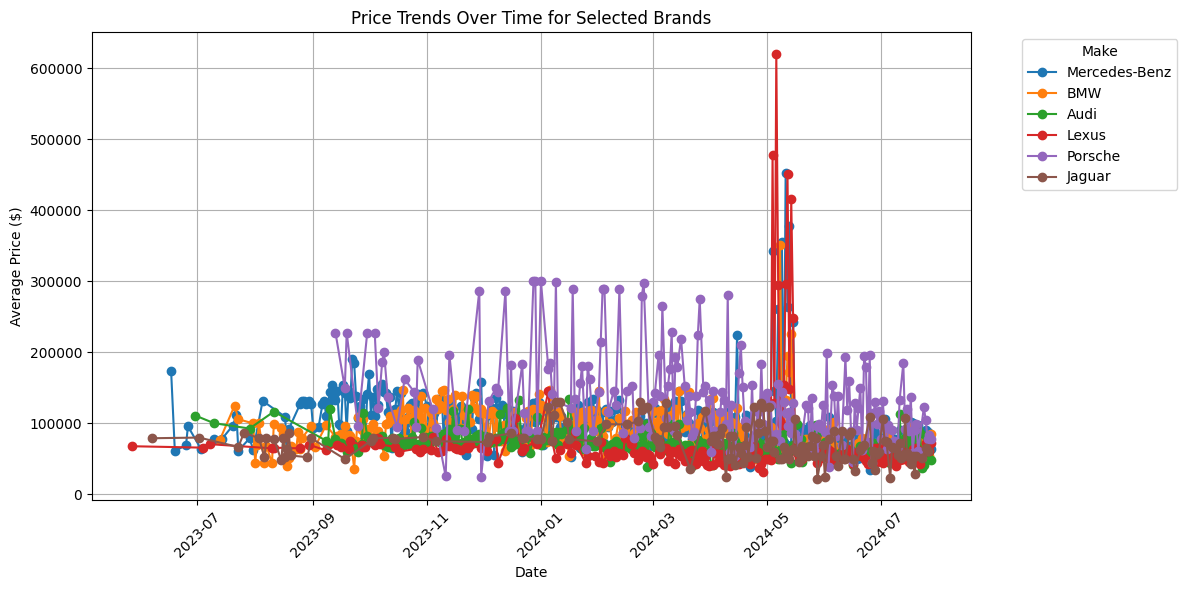

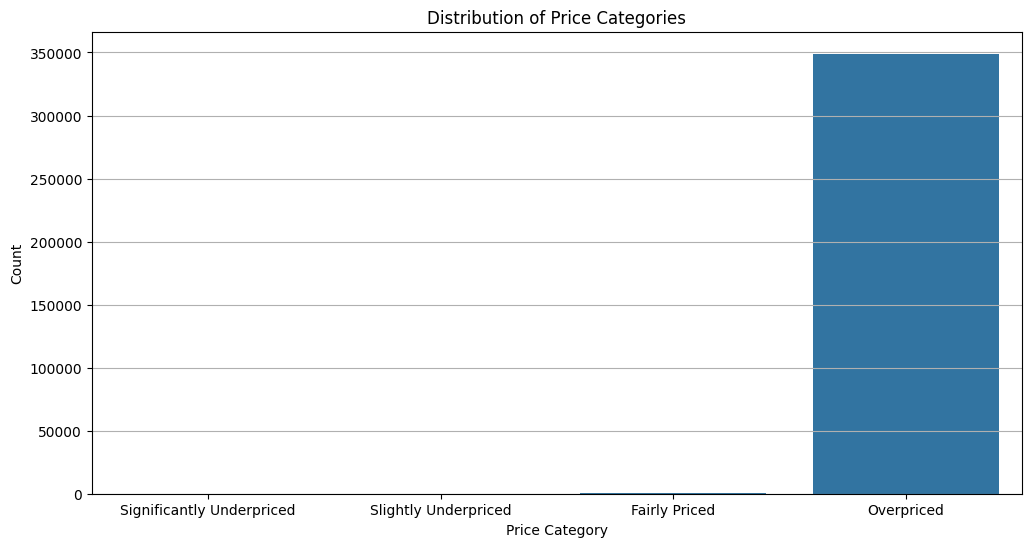

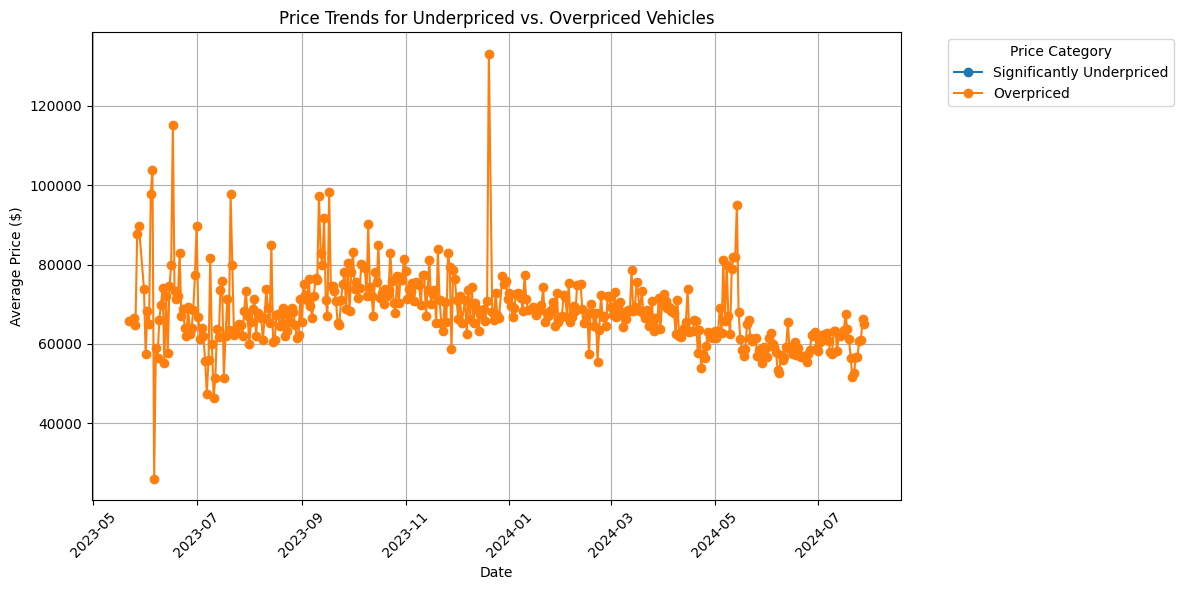

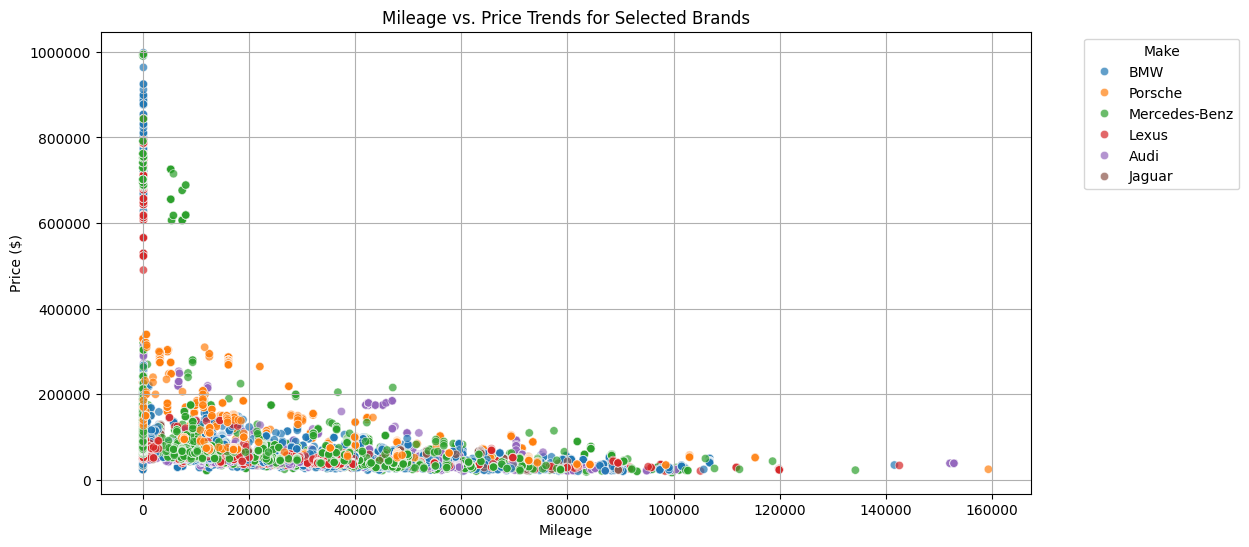

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime

# Ensure the date column is properly formatted
df_filtered_historical_prices['date'] = pd.to_datetime(df_filtered_historical_prices['date'], errors='coerce')

# 1️⃣ Price Trends Over Time for Top Brands
plt.figure(figsize=(12, 6))
top_brands = ['Mercedes-Benz', 'BMW', 'Audi', 'Lexus', 'Porsche', 'Jaguar']

for brand in top_brands:
    temp_df = df_filtered_historical_prices[df_filtered_historical_prices['make'] == brand]
    temp_df = temp_df.groupby('date')['price'].mean().reset_index()  # Average price per day
    plt.plot(temp_df['date'], temp_df['price'], marker='o', linestyle='-', label=brand)

plt.title("Price Trends Over Time for Selected Brands")
plt.xlabel("Date")
plt.ylabel("Average Price ($)")
plt.legend(title="Make", bbox_to_anchor=(1.05, 1), loc='upper left')  # Move legend outside
plt.grid(True)
plt.xticks(rotation=45)  # Improve readability
plt.tight_layout()
plt.ticklabel_format(style='plain', axis='y')
plt.show()

# 2️⃣ Distribution of Underpriced vs. Overpriced Vehicles
plt.figure(figsize=(12, 6))
sns.countplot(data=df_filtered_historical_prices, x="price_category", order=["Significantly Underpriced", "Slightly Underpriced", "Fairly Priced", "Overpriced"])
plt.title("Distribution of Price Categories")
plt.xlabel("Price Category")
plt.ylabel("Count")
plt.grid(axis='y')
plt.show()

# 3️⃣ Price Changes Over Time for Underpriced vs. Overpriced Vehicles
plt.figure(figsize=(12, 6))

for category in ["Significantly Underpriced", "Overpriced"]:
    temp_df = df_filtered_historical_prices[df_filtered_historical_prices['price_category'] == category]
    temp_df = temp_df.groupby('date')['price'].mean().reset_index()  # Aggregate price per day
    plt.plot(temp_df['date'], temp_df['price'], marker='o', linestyle='-', label=category)

plt.title("Price Trends for Underpriced vs. Overpriced Vehicles")
plt.xlabel("Date")
plt.ylabel("Average Price ($)")
plt.legend(title="Price Category", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.ticklabel_format(style='plain', axis='y')
plt.show()

# 4️⃣ Mileage vs. Price Trends for Top Brands
plt.figure(figsize=(12, 6))
sns.scatterplot(data=df_filtered_historical_prices[df_filtered_historical_prices['make'].isin(top_brands)], x='mileage', y='price', hue='make', alpha=0.7)
plt.title("Mileage vs. Price Trends for Selected Brands")
plt.xlabel("Mileage")
plt.ylabel("Price ($)")
plt.legend(title="Make", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True)
plt.ticklabel_format(style='plain', axis='y')
plt.show()


# **CSV File of historical data**

In [ ]:
df_filtered_historical_prices.to_csv('df_filtered_historical_prices.csv', index=False)

# **More Visualization of historical data**

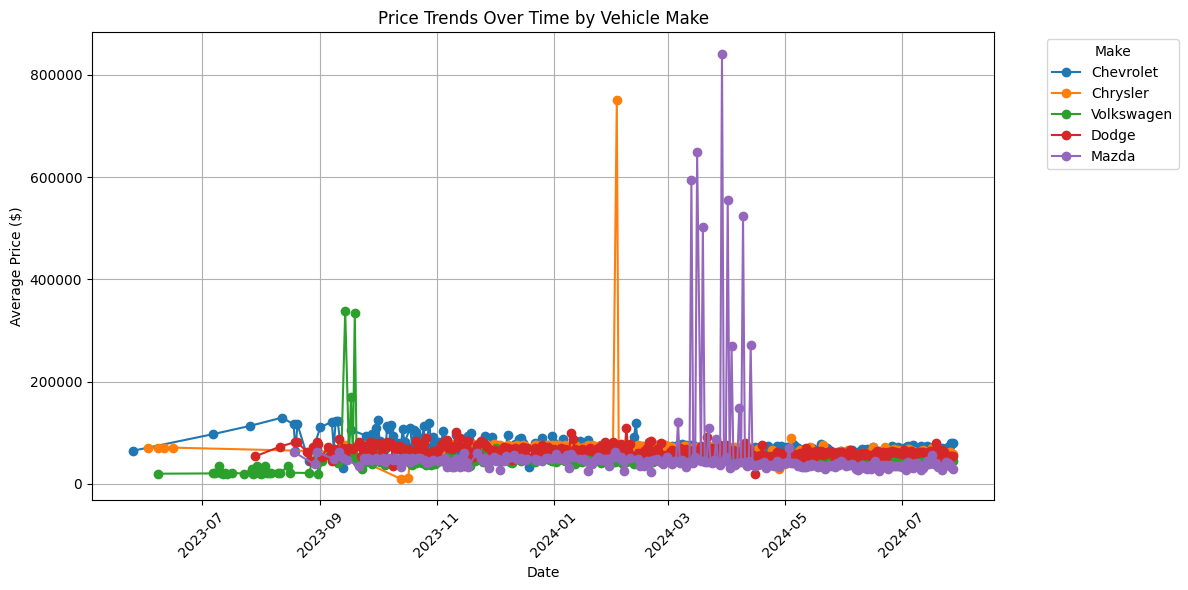

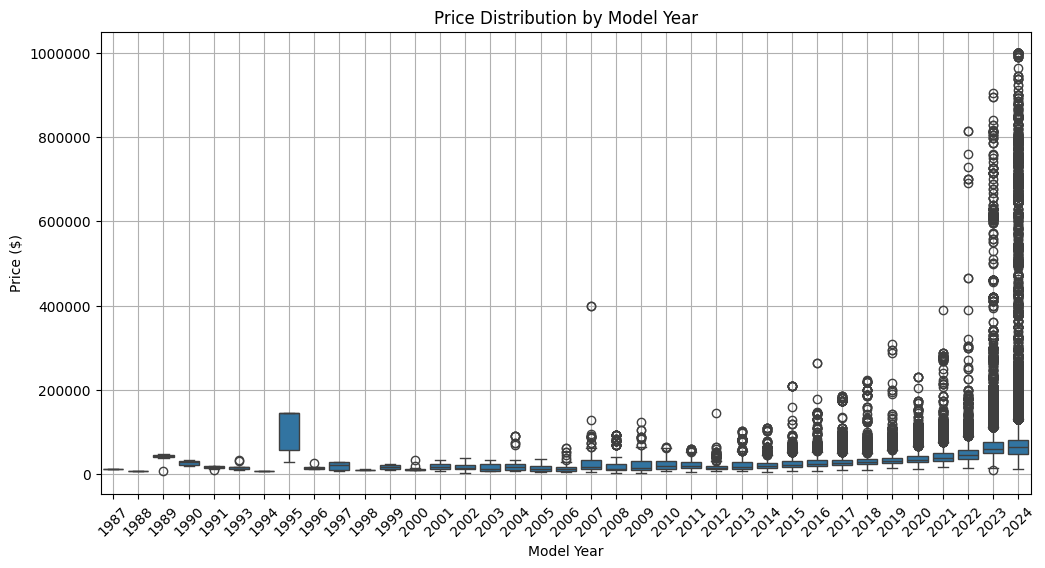

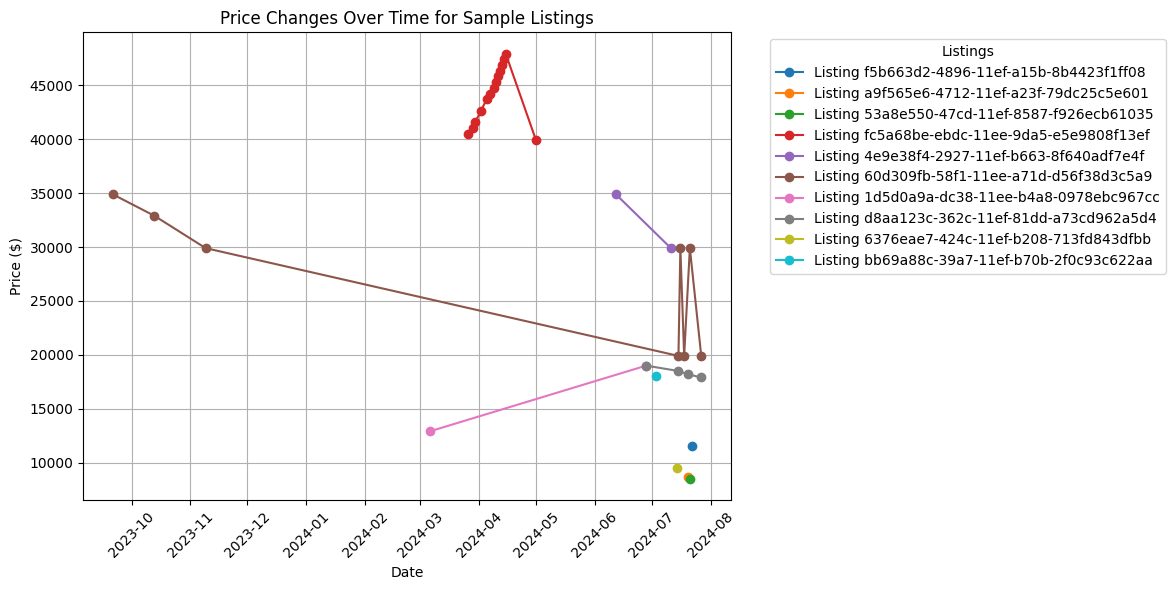

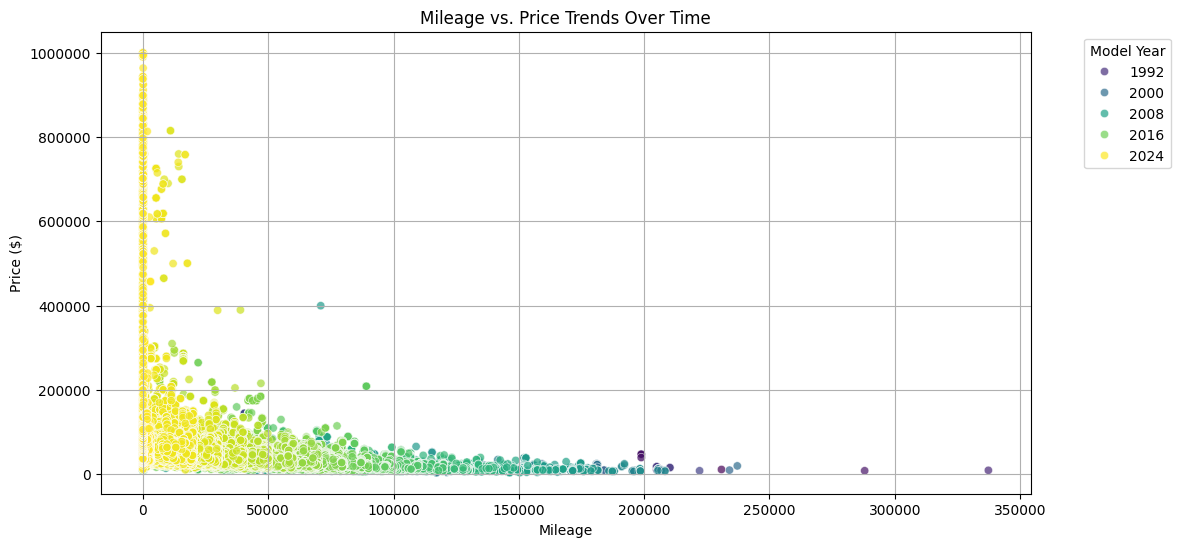

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Ensure date column is correctly formatted
df_filtered_historical_prices['date'] = pd.to_datetime(df_filtered_historical_prices['date'], errors='coerce')

# 1️⃣ Price Trends Over Time for Different Vehicle Makes
plt.figure(figsize=(12, 6))
for make in df_filtered_historical_prices['make'].unique()[:5]:  # Show 5 makes for clarity
    temp_df = df_filtered_historical_prices[df_filtered_historical_prices['make'] == make]
    temp_df = temp_df.groupby('date')['price'].mean().reset_index()  # Average price per day
    plt.plot(temp_df['date'], temp_df['price'], marker='o', linestyle='-', label=make)

plt.title("Price Trends Over Time by Vehicle Make")
plt.xlabel("Date")
plt.ylabel("Average Price ($)")
plt.legend(title="Make", bbox_to_anchor=(1.05, 1), loc='upper left')  # Move legend outside
plt.grid(True)
plt.xticks(rotation=45)  # Improve readability
plt.tight_layout()
plt.ticklabel_format(style='plain', axis='y')
plt.show()

# 2️⃣ Price Distribution by Model Year
plt.figure(figsize=(12, 6))
sns.boxplot(x="model_year", y="price", data=df_filtered_historical_prices)
plt.title("Price Distribution by Model Year")
plt.xlabel("Model Year")
plt.ylabel("Price ($)")
plt.xticks(rotation=45)
plt.grid(True)
plt.ticklabel_format(style='plain', axis='y')
plt.show()

# 3️⃣ Price Changes Over Time for Sample Listings
plt.figure(figsize=(12, 6))
for listing_id in df_filtered_historical_prices['listing_id'].unique()[:10]:  # Show 5 sample listings
    temp_df = df_filtered_historical_prices[df_filtered_historical_prices['listing_id'] == listing_id].sort_values(by='date')
    plt.plot(temp_df['date'], temp_df['price'], marker='o', linestyle='-', label=f"Listing {listing_id}")

plt.title("Price Changes Over Time for Sample Listings")
plt.xlabel("Date")
plt.ylabel("Price ($)")
plt.legend(title="Listings", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.ticklabel_format(style='plain', axis='y')
plt.show()

# 4️⃣ Mileage vs. Price Trends Over Time
plt.figure(figsize=(12, 6))
sns.scatterplot(data=df_filtered_historical_prices, x='mileage', y='price', hue='model_year', palette='viridis', alpha=0.7)
plt.title("Mileage vs. Price Trends Over Time")
plt.xlabel("Mileage")
plt.ylabel("Price ($)")
plt.legend(title="Model Year", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True)
plt.ticklabel_format(style='plain', axis='y')
plt.show()


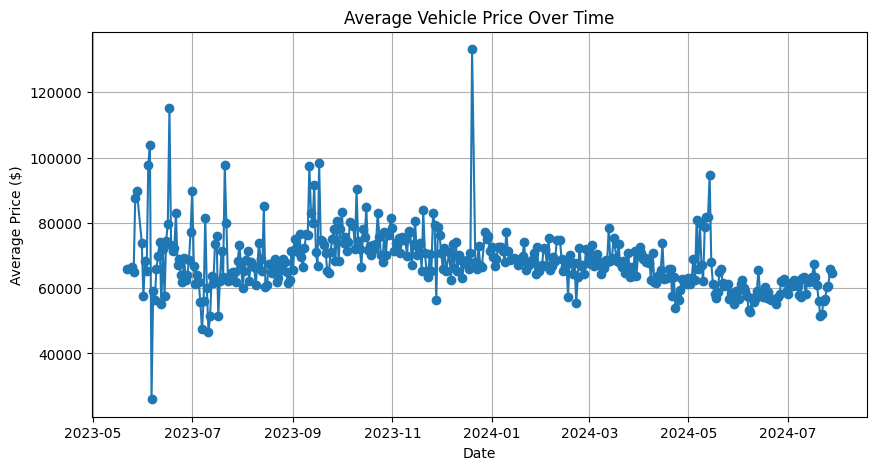

In [ ]:
df_avg_price = df_filtered_historical_prices.groupby('date')['price'].mean().reset_index()

plt.figure(figsize=(10, 5))
plt.plot(df_avg_price['date'], df_avg_price['price'], marker='o', linestyle='-')
plt.title("Average Vehicle Price Over Time")
plt.xlabel("Date")
plt.ylabel("Average Price ($)")
plt.ticklabel_format(style='plain', axis='y')
plt.grid(True)
plt.show()


In [ ]:
df_price_change_count = df_filtered_historical_prices.groupby('listing_id')['price'].count().reset_index()
df_price_change_count.columns = ['listing_id', 'num_price_changes']
df_price_change_count = df_price_change_count.sort_values(by='num_price_changes', ascending=False)

# Display vehicles with most price changes
print("Vehicles with the Most Price Changes:")
print(df_price_change_count.head(10))


Vehicles with the Most Price Changes:
                                 listing_id  num_price_changes
11875  3171ee9e-2db3-11ee-a281-b3da229222e6                155
70132  ece61675-3331-11ee-adb8-e171eac8fd67                140
12009  31d1e86e-2db3-11ee-8a07-b5b48a6a5b7e                131
60515  cbd65d69-38ba-11ee-b2e8-3f2b76ecd2b7                123
31706  7d5f2a7d-9a6f-11ee-b212-7dc89b8e2195                120
32783  818bf04b-708f-11ee-9097-61d14b73d567                120
65703  ddc0a4f6-8b48-11ee-8dc0-55f6cdfc6251                117
48263  a212052c-625b-11ee-8204-fdad36b50326                113
32843  81a718f1-708f-11ee-9097-99bd52d81507                113
27983  72865fd1-8111-11ee-9455-5f74294f58e3                111


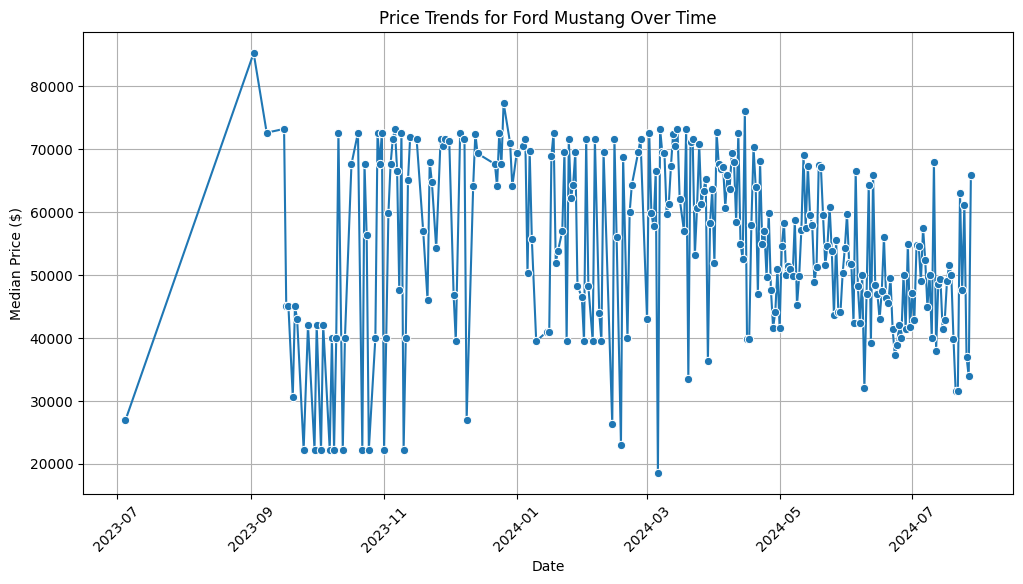

Summary Statistics for Ford Mustang:
            count          mean           std      min      25%      50%  \
date                                                                       
2023-07-05    1.0  26900.000000           NaN  26900.0  26900.0  26900.0   
2023-09-02    1.0  85305.000000           NaN  85305.0  85305.0  85305.0   
2023-09-08    3.0  73118.333333   4035.871447  69340.0  70992.5  72645.0   
2023-09-16    1.0  73240.000000           NaN  73240.0  73240.0  73240.0   
2023-09-17    1.0  44997.000000           NaN  44997.0  44997.0  44997.0   
...           ...           ...           ...      ...      ...      ...   
2024-07-24   13.0  48753.076923  15994.767069  25797.0  36885.0  47642.0   
2024-07-25    5.0  66919.400000  37473.556661  38495.0  38711.0  61089.0   
2024-07-26   14.0  40318.642857  15478.597843  25498.0  33595.5  36995.0   
2024-07-27   19.0  42851.526316  20795.353667  24995.0  30699.0  33888.0   
2024-07-28   21.0  61295.619048  29607.203636  2850

In [ ]:


# Step 1: Define Filters for Brand and Model
selected_make = "Ford"  # Change as needed
selected_model = "Mustang"  # Change as needed

# Step 2: Get listing IDs of selected make and model from df_clean
selected_listings = df_clean[
    (df_clean['make'] == selected_make) & (df_clean['model'] == selected_model)
]['listing_id'].unique()  # Get unique listing IDs

# Step 3: Filter df_filtered_historical_prices using the selected listings
filtered_price_trends = df_filtered_historical_prices[
    df_filtered_historical_prices['listing_id'].isin(selected_listings)
]

# Step 4: Check if data exists before plotting
if not filtered_price_trends.empty:
    # Group by date and calculate median price
    price_trend = filtered_price_trends.groupby('date')['price'].median()

    # Plot Price Trends
    plt.figure(figsize=(12, 6))
    sns.lineplot(x=price_trend.index, y=price_trend.values, marker='o', linestyle='-')

    plt.title(f"Price Trends for {selected_make} {selected_model} Over Time")
    plt.xlabel("Date")
    plt.ylabel("Median Price ($)")
    plt.xticks(rotation=45)
    plt.ticklabel_format(style='plain', axis='y')
    plt.grid(True)
    plt.show()

    # Step 5: Display Summary Statistics
    price_summary_filtered = filtered_price_trends.groupby('date')['price'].describe()

    # Display the filtered price trends summary
    print(f"Summary Statistics for {selected_make} {selected_model}:")
    print(price_summary_filtered)

else:
    print(f"No price history data available for {selected_make} {selected_model}.")


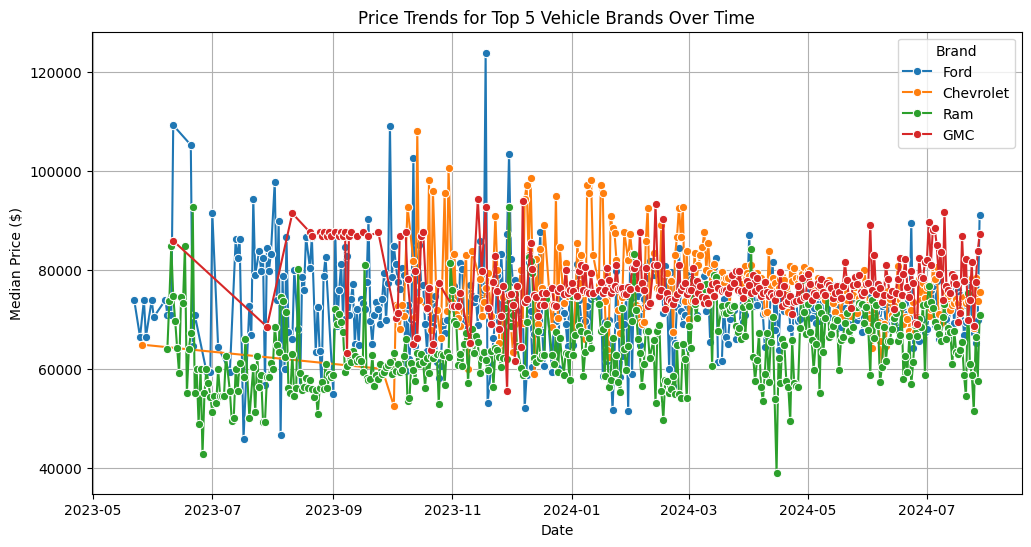

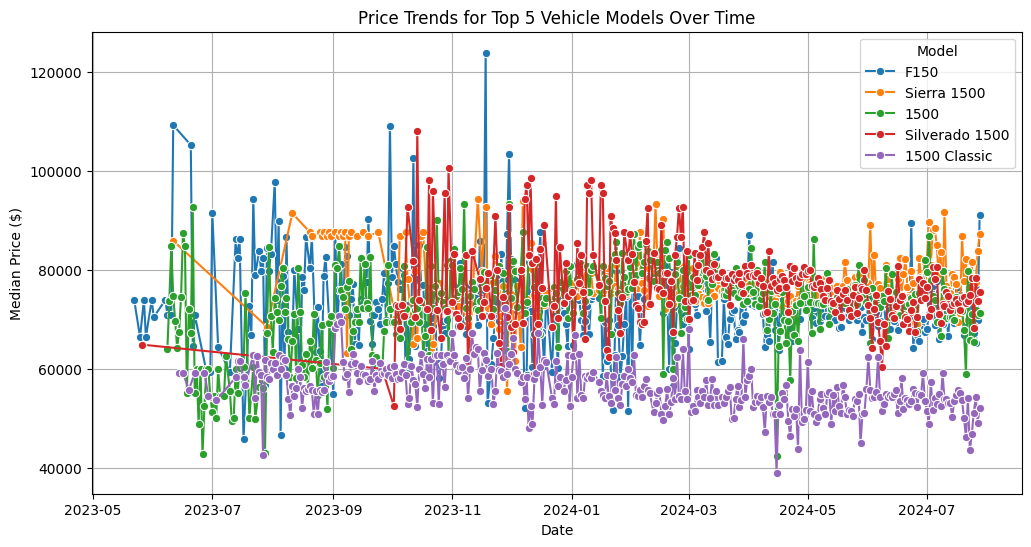

Summary Statistics for Top Brands & Models:
            date                            listing_id     price
0     2023-05-22  d31c7059-f911-11ed-8615-55924ce1a2ee   73955.0
1     2023-05-25  d31c7059-f911-11ed-8615-55924ce1a2ee   66455.0
2     2023-05-26  ab52cc1f-fc1b-11ed-a2b6-03327201c868   64900.0
3     2023-05-27  d31c7059-f911-11ed-8615-55924ce1a2ee   73955.0
4     2023-05-28  d31c7059-f911-11ed-8615-55924ce1a2ee   66455.0
...          ...                                   ...       ...
93363 2024-07-28  f9ca2f88-49fb-11ee-a5f8-1346c94e606e  105755.0
93364 2024-07-28  fa5dbe62-7eb3-4676-9fe9-07d4f10a1a59   38488.0
93365 2024-07-28  fb062ed9-0a81-11ef-bf6c-8b1a898b2c7f   77843.0
93366 2024-07-28  fcb2fcf6-395e-49da-860b-8b31a796659e   69374.0
93367 2024-07-28  fed20a57-55f3-4625-b8d0-e966ac622e79   77789.0

[93368 rows x 3 columns]


In [ ]:
# Step 1: Select Top 5 Most Common Makes & Models for Comparison
top_makes = df_clean['make'].value_counts().index[:5]  # Top 5 brands
top_models = df_clean['model'].value_counts().index[:5]  # Top 5 models

# Step 2: Filter the dataset to include only selected makes & models
filtered_price_trends = df_filtered_historical_prices[df_filtered_historical_prices['listing_id'].isin(
    df_clean[(df_clean['make'].isin(top_makes)) & (df_clean['model'].isin(top_models))]['listing_id']
)]

# Step 3: Plot Price Trends for Multiple Brands
plt.figure(figsize=(12, 6))
for make in top_makes:
    brand_trend = filtered_price_trends[filtered_price_trends['listing_id'].isin(
        df_clean[df_clean['make'] == make]['listing_id']
    )].groupby('date')['price'].median().reset_index()

    sns.lineplot(x=brand_trend['date'], y=brand_trend['price'], marker='o', label=make)

plt.title("Price Trends for Top 5 Vehicle Brands Over Time")
plt.xlabel("Date")
plt.ylabel("Median Price ($)")
plt.grid(True)
plt.legend(title="Brand")
plt.show()

# Step 4: Plot Price Trends for Multiple Models
plt.figure(figsize=(12, 6))
for model in top_models:
    model_trend = filtered_price_trends[filtered_price_trends['listing_id'].isin(
        df_clean[df_clean['model'] == model]['listing_id']
    )].groupby('date')['price'].median().reset_index()

    sns.lineplot(x=model_trend['date'], y=model_trend['price'], marker='o', label=model)

plt.title("Price Trends for Top 5 Vehicle Models Over Time")
plt.xlabel("Date")
plt.ylabel("Median Price ($)")
plt.grid(True)
plt.legend(title="Model")
plt.show()

# Step 5: Display Summary Statistics for Top Brands & Models
price_summary_comparison = filtered_price_trends.groupby(['date', 'listing_id'])['price'].median().reset_index()

# Display the filtered price trends summary
print("Summary Statistics for Top Brands & Models:")
print(price_summary_comparison)


# **Visualizing price distribution **

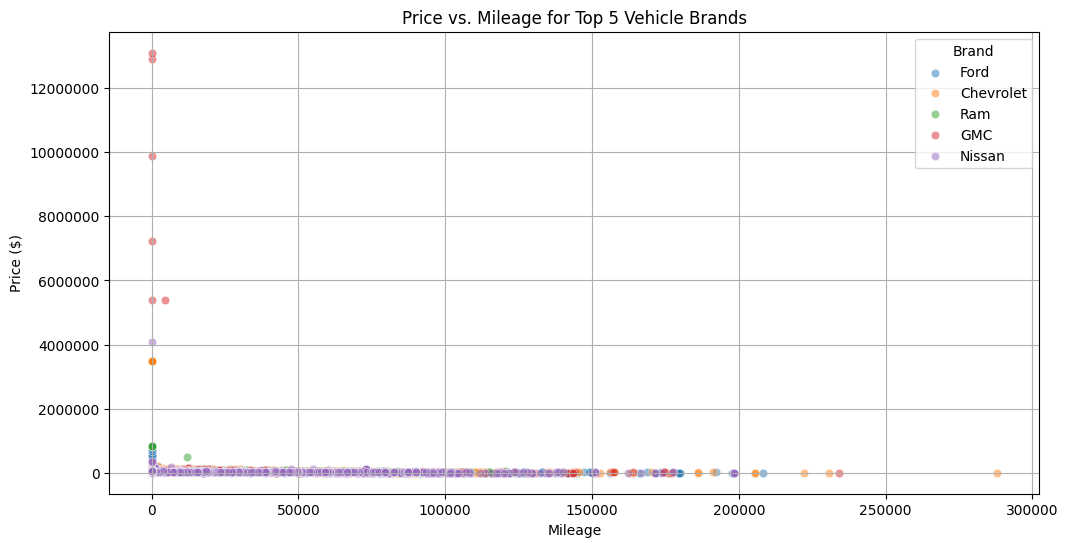

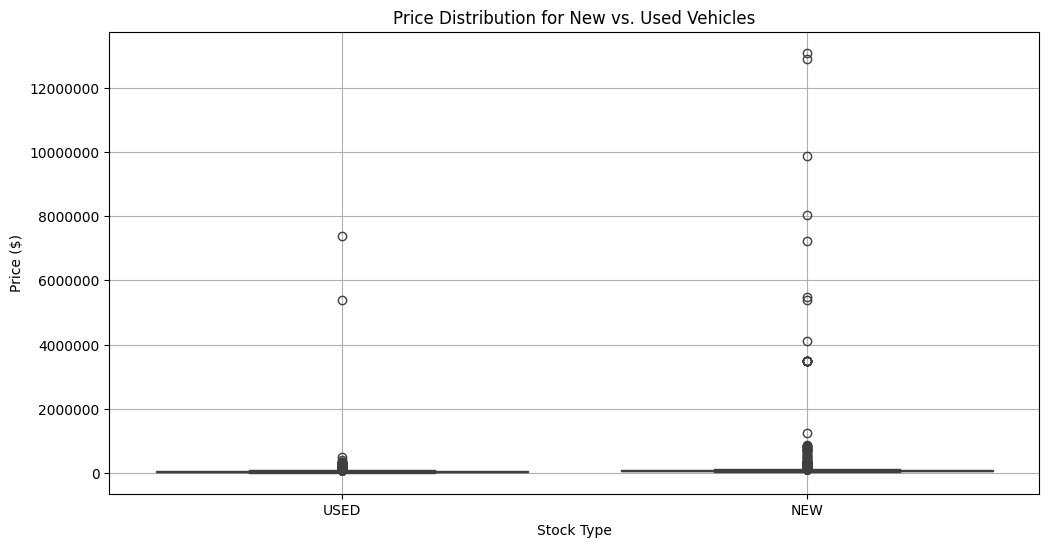

Summary Statistics for Mileage & Stock Type Analysis:
  stock_type  mileage    price
0        NEW     15.0  61252.0
1       USED  26817.0  37663.5


In [ ]:
# Step 1: Plot Price Trends by Mileage for Top 5 Brands
plt.figure(figsize=(12, 6))
for make in top_makes:
    brand_trend = df_clean[df_clean['make'] == make]
    sns.scatterplot(x=brand_trend['mileage'], y=brand_trend['price'], alpha=0.5, label=make)

plt.title("Price vs. Mileage for Top 5 Vehicle Brands")
plt.xlabel("Mileage")
plt.ylabel("Price ($)")
plt.ticklabel_format(style='plain', axis='y')
plt.legend(title="Brand")
plt.grid(True)
plt.show()

# Step 2: Plot Price Trends by Stock Type (New vs. Used)
plt.figure(figsize=(12, 6))
sns.boxplot(x=df_clean['stock_type'], y=df_clean['price'])
plt.title("Price Distribution for New vs. Used Vehicles")
plt.xlabel("Stock Type")
plt.ylabel("Price ($)")
plt.ticklabel_format(style='plain', axis='y')
plt.grid(True)
plt.show()

# Step 3: Display Summary Statistics for Mileage & Stock Type Analysis
mileage_stock_summary = df_clean.groupby(['stock_type'])[['mileage', 'price']].median().reset_index()

# Display the summary statistics
print("Summary Statistics for Mileage & Stock Type Analysis:")
print(mileage_stock_summary)


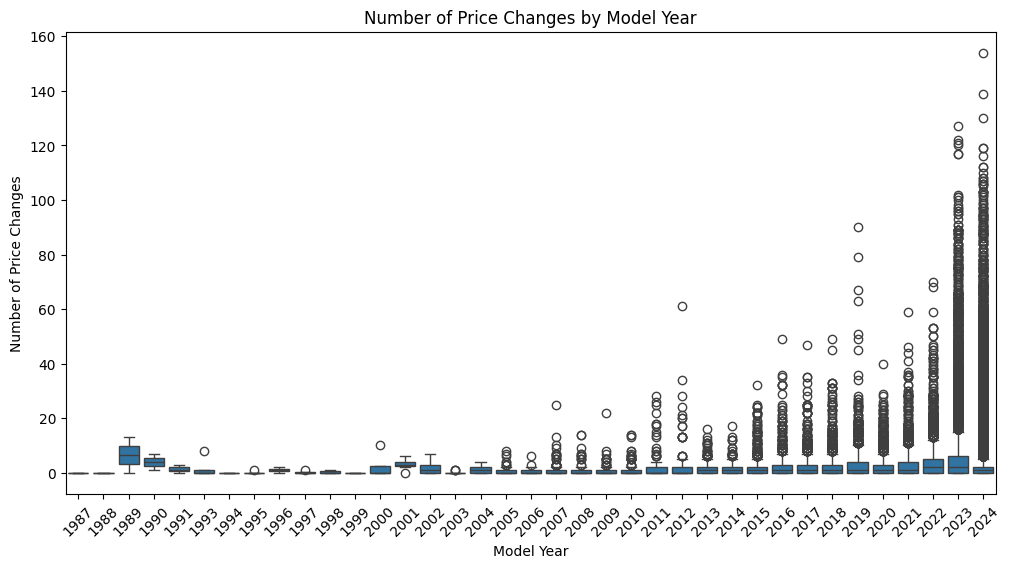

In [ ]:

plt.figure(figsize=(12, 6))
sns.boxplot(x=df_clean['model_year'], y=df_clean['number_price_changes'])
plt.title("Number of Price Changes by Model Year")
plt.xlabel("Model Year")
plt.ylabel("Number of Price Changes")
plt.xticks(rotation=45)
plt.show()


In [ ]:
correlation = df_clean[['price', 'number_price_changes']].corr()
print(correlation)


                         price  number_price_changes
price                 1.000000              0.008603
number_price_changes  0.008603              1.000000


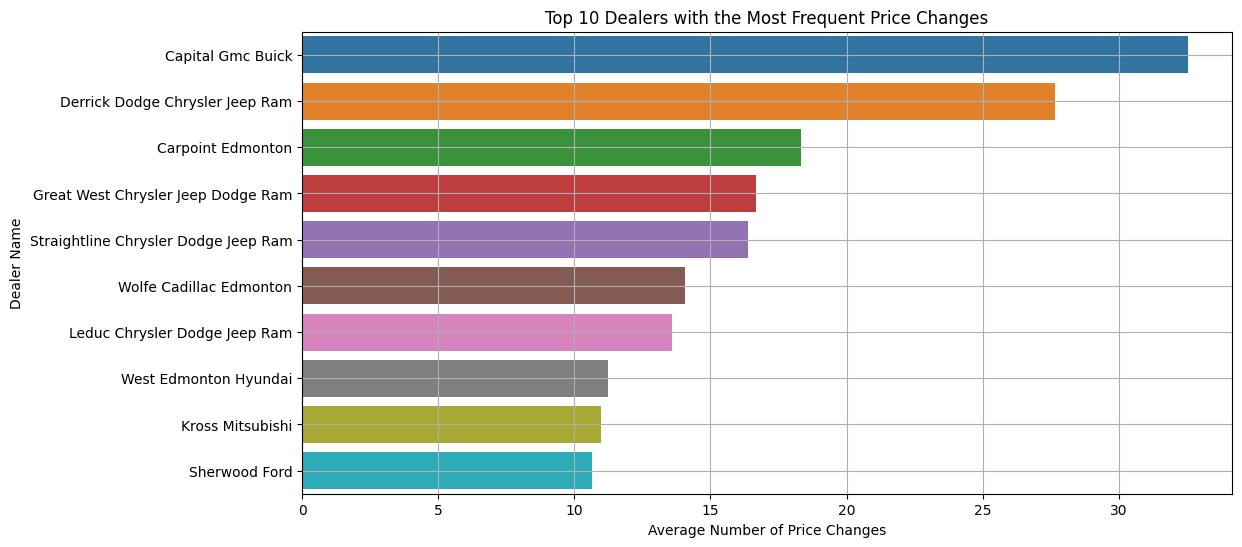

Summary of Dealer Price Change Frequency:
                              dealer_name  number_price_changes
29                      Capital Gmc Buick             32.529730
41        Derrick Dodge Chrysler Jeep Ram             27.656101
33                      Carpoint Edmonton             18.333333
81     Great West Chrysler Jeep Dodge Ram             16.670732
180  Straightline Chrysler Dodge Jeep Ram             16.381250
..                                    ...                   ...
11              Auto Wholesale Direct Inc              0.000000
132                    North Point Motors              0.000000
4                  Alaskan Equipment Ltd.              0.000000
169                 Smart Start Auto Inc.              0.000000
80               Great West Chrysler Jeep              0.000000

[215 rows x 2 columns]


In [ ]:
# Step 1:

# Group by dealer and calculate average number of price changes
dealer_price_change_summary = df_clean.groupby('dealer_name')['number_price_changes'].mean().reset_index()

# Sort dealers by highest average number of price changes
dealer_price_change_summary = dealer_price_change_summary.sort_values(by='number_price_changes', ascending=False)

# Step 2: Plot the Top 10 Dealers with the Most Frequent Price Changes
plt.figure(figsize=(12, 6))
top_dealers = dealer_price_change_summary.head(10)
sns.barplot(y=top_dealers['dealer_name'], x=top_dealers['number_price_changes'], hue=top_dealers['dealer_name'], legend=False)
plt.title("Top 10 Dealers with the Most Frequent Price Changes")
plt.xlabel("Average Number of Price Changes")
plt.ylabel("Dealer Name")
plt.grid(True)
plt.show()

# Step 3: Display the Summary of Dealer Price Change Frequency
print("Summary of Dealer Price Change Frequency:")
print(dealer_price_change_summary)



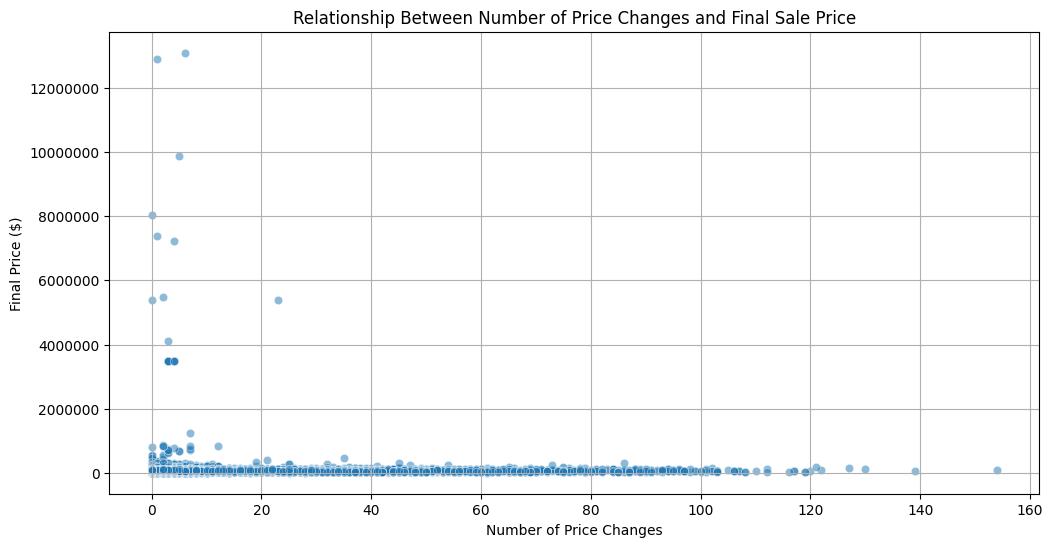

Correlation Results:
                      Metric     Value
0        Pearson Correlation  0.008603
1  Spearman Rank Correlation -0.009173
2         P-Value (Spearman)  0.009415


In [ ]:
import scipy.stats as stats

# Step 1: Correlation Between Price Changes and Final Sale Price
correlation = df_clean[['price', 'number_price_changes']].corr()

# Step 2: Statistical Test (Spearman Rank Correlation) to Check Relationship
spearman_corr, p_value = stats.spearmanr(df_clean['number_price_changes'], df_clean['price'])

# Step 3: Plot Scatter Plot to Visualize the Relationship
plt.figure(figsize=(12, 6))
sns.scatterplot(x=df_clean['number_price_changes'], y=df_clean['price'], alpha=0.5)
plt.title("Relationship Between Number of Price Changes and Final Sale Price")
plt.xlabel("Number of Price Changes")
plt.ylabel("Final Price ($)")
plt.ticklabel_format(style='plain', axis='y')
plt.grid(True)
plt.show()

# Step 4: Display Correlation Results
correlation_results = pd.DataFrame({
    "Metric": ["Pearson Correlation", "Spearman Rank Correlation", "P-Value (Spearman)"],
    "Value": [correlation.iloc[0,1], spearman_corr, p_value]
})

# Display correlation results
print("Correlation Results:")
print(correlation_results)

In [ ]:
df_clean['engine_size'] = df_clean['engine_from_vin'].str.extract(r'(\d+\.\d+)').astype(float)


In [ ]:
df_clean['engine_size'].dtype

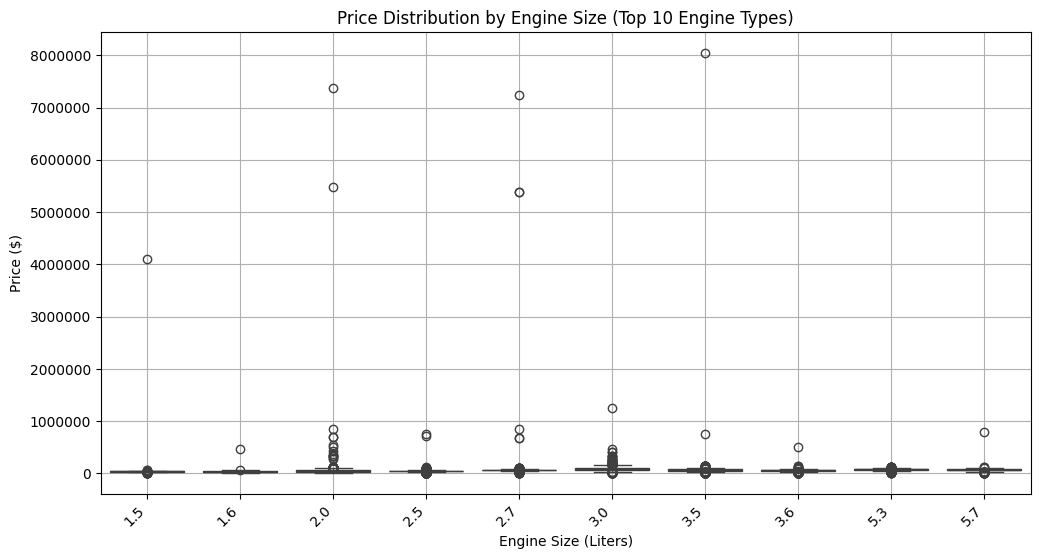

In [ ]:

# Step 1:

# Extract numerical engine sizes from 'engine_from_vin' if possible
df_clean['engine_size'] = df_clean['engine_from_vin'].str.extract(r'(\d+\.\d+)').astype(float)

# Select top 10 most common engine types for better visualization
top_engine_types = df_clean['engine_size'].value_counts().index[:10]

# Step 2: Filter Data for Readability
filtered_df = df_clean[df_clean['engine_size'].isin(top_engine_types)]

# Step 3: Improved Boxplot with Adjusted X-axis Labels
plt.figure(figsize=(12, 6))
sns.boxplot(x=filtered_df['engine_size'], y=filtered_df['price'])
plt.xticks(rotation=45, ha='right')  # Adjust text rotation for readability
plt.title("Price Distribution by Engine Size (Top 10 Engine Types)")
plt.xlabel("Engine Size (Liters)")
plt.ylabel("Price ($)")
plt.ticklabel_format(style='plain', axis='y')
plt.grid(True)
plt.show()



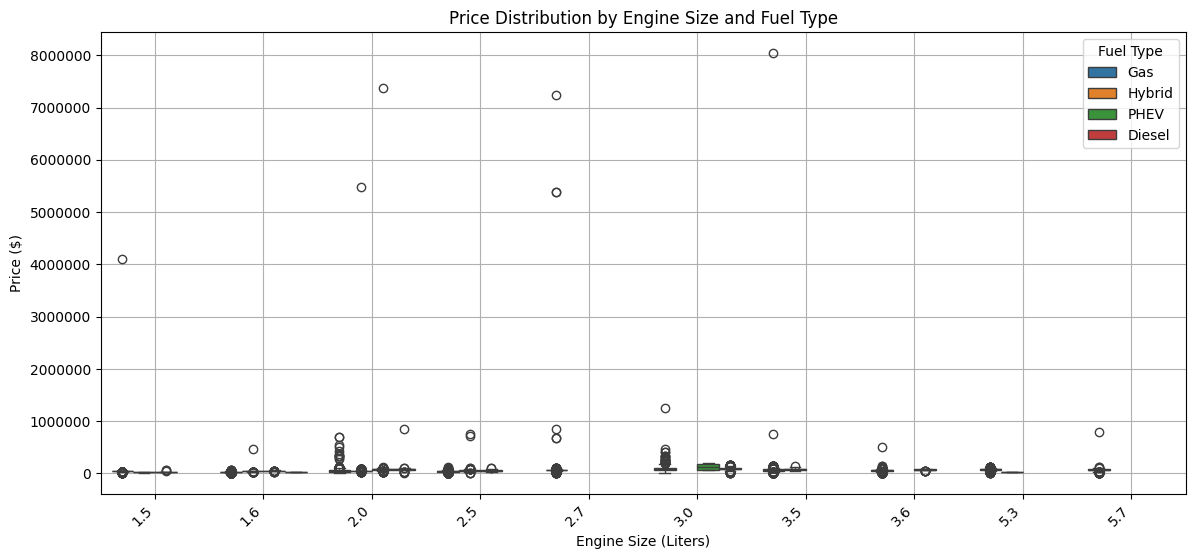

Summary Statistics for Engine Size vs. Fuel Type Pricing:
    engine_size fuel_type_from_vin     price
0           1.5                Gas   39719.0
1           1.5             Hybrid   22365.0
2           1.5               PHEV   28924.5
3           1.6             Diesel   18750.0
4           1.6                Gas   27128.0
5           1.6             Hybrid   44328.0
6           1.6               PHEV   52433.0
7           2.0             Diesel   81543.0
8           2.0                Gas   44955.0
9           2.0             Hybrid   50638.0
10          2.0               PHEV   79866.0
11          2.5                Gas   39995.0
12          2.5             Hybrid   48692.0
13          2.5               PHEV   52119.0
14          2.7                Gas   64119.0
15          3.0             Diesel   85599.0
16          3.0                Gas   90158.0
17          3.0               PHEV  131410.0
18          3.5                Gas   62232.5
19          3.5             Hybrid   78169

In [ ]:
# Step 1: Filter Data for Readability (Top Engine Sizes & Common Fuel Types)
top_engine_types = df_clean['engine_size'].value_counts().index[:10]  # Top 10 engine sizes
common_fuel_types = df_clean['fuel_type_from_vin'].value_counts().index[:5]  # Top 5 fuel types

filtered_df = df_clean[(df_clean['engine_size'].isin(top_engine_types)) &
                       (df_clean['fuel_type_from_vin'].isin(common_fuel_types))]

# Step 2: Create a Boxplot Comparing Price by Engine Size & Fuel Type
plt.figure(figsize=(14, 6))
sns.boxplot(x=filtered_df['engine_size'], y=filtered_df['price'], hue=filtered_df['fuel_type_from_vin'])

plt.xticks(rotation=45, ha='right')  # Adjust text rotation for readability
plt.title("Price Distribution by Engine Size and Fuel Type")
plt.xlabel("Engine Size (Liters)")
plt.ylabel("Price ($)")
plt.ticklabel_format(style='plain', axis='y')
plt.legend(title="Fuel Type")
plt.grid(True)
plt.show()

# Step 3: Summary Statistics for Engine Size vs. Fuel Type Pricing
engine_fuel_price_summary = filtered_df.groupby(['engine_size', 'fuel_type_from_vin'])['price'].median().reset_index()

# Display the summary statistics
print("Summary Statistics for Engine Size vs. Fuel Type Pricing:")
print(engine_fuel_price_summary)


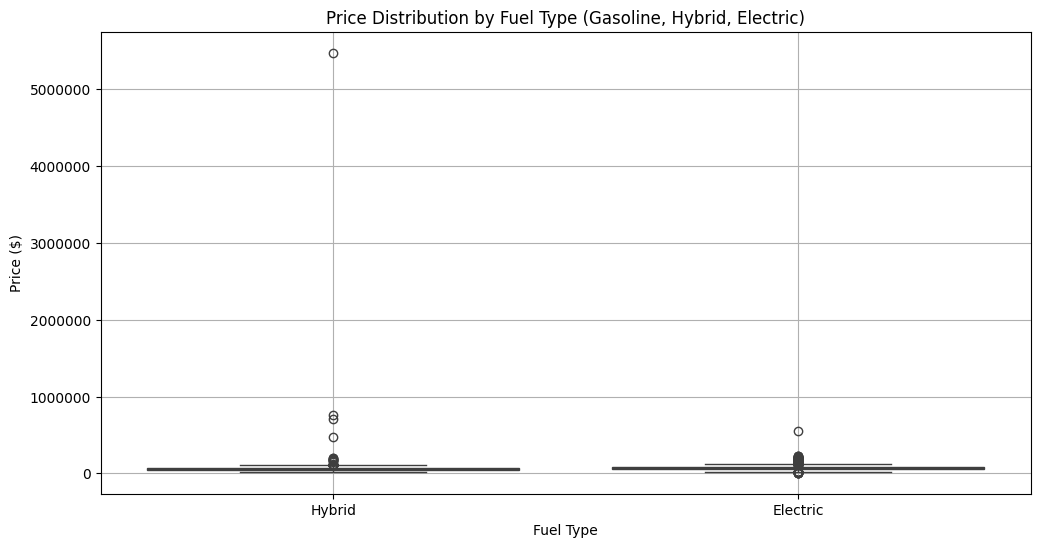

Summary Statistics for Fuel Type Pricing:
  fuel_type_from_vin    price
0           Electric  64206.5
1             Hybrid  50999.0


In [ ]:
# Step 1: Filter Data for Gasoline, Hybrid, and Electric Vehicles
fuel_categories = ['Gasoline', 'Hybrid', 'Electric']  # Define fuel types of interest
filtered_fuel_df = df_clean[df_clean['fuel_type_from_vin'].isin(fuel_categories)]

# Step 2: Boxplot to Compare Price Distribution Across Fuel Types
plt.figure(figsize=(12, 6))
sns.boxplot(x=filtered_fuel_df['fuel_type_from_vin'], y=filtered_fuel_df['price'])

plt.title("Price Distribution by Fuel Type (Gasoline, Hybrid, Electric)")
plt.xlabel("Fuel Type")
plt.ylabel("Price ($)")
plt.ticklabel_format(style='plain', axis='y')
plt.grid(True)
plt.show()

# Step 3: Calculate Median Prices for Each Fuel Type
fuel_price_summary = filtered_fuel_df.groupby('fuel_type_from_vin')['price'].median().reset_index()

# Display the summary statistics
print("Summary Statistics for Fuel Type Pricing:")
print(fuel_price_summary)


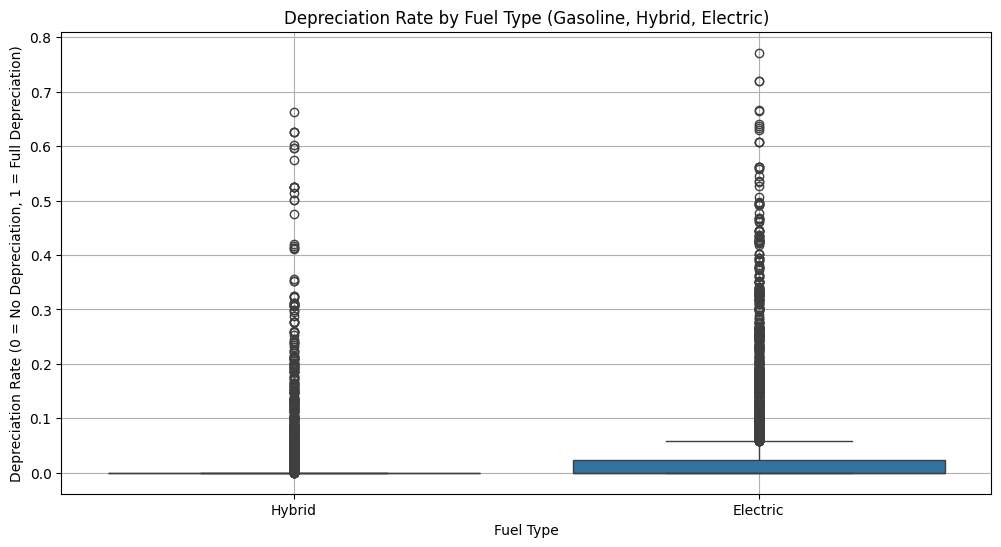

Summary Statistics for Depreciation by Fuel Type:
  fuel_type_from_vin  depreciation_rate
0           Electric                0.0
1             Hybrid                0.0


In [ ]:
# Step 1: Calculate Depreciation Rate by Fuel Type
# Depreciation = (MSRP - Current Price) / MSRP

df_clean['depreciation_rate'] = (df_clean['msrp'] - df_clean['price']) / df_clean['msrp']
df_clean['depreciation_rate'] = df_clean['depreciation_rate'].clip(lower=0, upper=1)  # Ensure valid range

# Step 2: Filter for Gasoline, Hybrid, and Electric Vehicles
fuel_categories = ['Gasoline', 'Hybrid', 'Electric']
filtered_fuel_depreciation = df_clean[df_clean['fuel_type_from_vin'].isin(fuel_categories)]

# Step 3: Boxplot Comparing Depreciation Rate by Fuel Type
plt.figure(figsize=(12, 6))
sns.boxplot(x=filtered_fuel_depreciation['fuel_type_from_vin'], y=filtered_fuel_depreciation['depreciation_rate'])

plt.title("Depreciation Rate by Fuel Type (Gasoline, Hybrid, Electric)")
plt.xlabel("Fuel Type")
plt.ylabel("Depreciation Rate (0 = No Depreciation, 1 = Full Depreciation)")
plt.ticklabel_format(style='plain', axis='y')
plt.grid(True)
plt.show()

# Step 4: Summary Statistics for Depreciation by Fuel Type
fuel_depreciation_summary = filtered_fuel_depreciation.groupby('fuel_type_from_vin')['depreciation_rate'].median().reset_index()

# Display the summary statistics
print("Summary Statistics for Depreciation by Fuel Type:")
print(fuel_depreciation_summary)


In [ ]:
df_clean.head()

In [ ]:
df_clean.columns

Index(['listing_id', 'listing_heading', 'listing_type', 'listing_url',
       'listing_first_date', 'days_on_market', 'dealer_id', 'dealer_name',
       'dealer_street', 'dealer_city', 'dealer_province', 'dealer_postal_code',
       'dealer_url', 'dealer_email', 'dealer_phone', 'dealer_type',
       'stock_type', 'vehicle_id', 'vin', 'uvc', 'mileage', 'price', 'msrp',
       'model_year', 'make', 'model', 'series', 'style', 'certified',
       'has_leather', 'has_navigation', 'exterior_color',
       'exterior_color_category', 'interior_color', 'interior_color_category',
       'price_analysis', 'wheelbase_from_vin', 'drivetrain_from_vin',
       'engine_from_vin', 'transmission_from_vin', 'fuel_type_from_vin',
       'number_price_changes', 'price_history_delimited', 'distance_to_dealer',
       'location_score', 'listing_dropoff_date', 'engine_size',
       'depreciation_rate'],
      dtype='object')

In [ ]:
df_clean['depreciation_rate'].unique()

array([0.        , 0.0886416 , 0.14140445, ..., 0.00118437, 0.00318716,
       0.00496758])

# **More Cleaning and Feature selection**

In [ ]:
df_clean_new = df_clean.copy()

In [ ]:
columns_to_drop = [
    'listing_id', 'vehicle_id', 'vin', 'uvc', 'listing_heading', 'listing_type', 'listing_url',
    'listing_first_date', 'listing_dropoff_date', 'dealer_id', 'dealer_name', 'dealer_street',
    'dealer_city', 'dealer_province', 'dealer_postal_code', 'dealer_url', 'dealer_email','depreciation_rate',
    'dealer_phone', 'dealer_type', 'has_leather', 'has_navigation','certified','wheelbase_from_vin',
    'exterior_color', 'interior_color', 'price_analysis', 'engine_from_vin',
    'price_history_delimited', 'distance_to_dealer', 'location_score'
]

df_clean_new.drop(columns=columns_to_drop, inplace=True)

# Display the refined dataset
print("Refined Dataset:")
print(df_clean_new)

Refined Dataset:
        days_on_market stock_type  mileage   price   msrp  model_year  \
0                    9       USED   230860   11500      0        1987   
1                    4       USED    48905    8700      0        1988   
4                   10       USED   288000    8500      0        1989   
5                   38       USED   198839   39900      0        1989   
6                   49       USED    21364   29900      0        1990   
...                ...        ...      ...     ...    ...         ...   
145107              87        NEW       30  102016  94500        2024   
145108              82        NEW       30  103950  94500        2024   
145109              99        NEW       30  105781  94500        2024   
145110              96        NEW       30  105990  94500        2024   
145111              22       USED     2454  108201  94500        2024   

              make         model             series           style  \
0        Chevrolet        Camaro   

In [ ]:
df_clean_new.head()

,days_on_market,stock_type,mileage,price,msrp,model_year,make,model,series,style,exterior_color_category,interior_color_category,drivetrain_from_vin,transmission_from_vin,fuel_type_from_vin,number_price_changes,engine_size
0,9,USED,230860,11500,0,1987,Chevrolet,Camaro,Iroc Z28,2D Coupe,blue,NaN,RWD,A,Gas,0,5.7
1,4,USED,48905,8700,0,1988,Chrysler,Fifth Avenue,NaN,4D Sedan,NaN,NaN,RWD,A,Gas,0,5.2
4,10,USED,288000,8500,0,1989,Chevrolet,Camaro,Z28,2D Coupe,NaN,NaN,RWD,A,Gas,0,5.7
5,38,USED,198839,39900,0,1989,Volkswagen,Cabriolet,NaN,Convertible,blue,NaN,FWD,A,Gas,13,1.8
6,49,USED,21364,29900,0,1990,Dodge,Ram 150,Custom,Club Cab,beige,NaN,RWD,A,Gas,1,5.2


In [ ]:
df_clean_new.shape

(80120, 17)

In [ ]:

df_clean_new.isnull().sum()

,0
days_on_market,0
stock_type,0
mileage,0
price,0
msrp,0
model_year,0
make,0
model,0
series,390
style,0


In [ ]:
#percentage of null for each collumn
df_clean_new.isnull().sum()*100 / len(df_clean_new)

,0
days_on_market,0.000000
stock_type,0.000000
mileage,0.000000
price,0.000000
msrp,0.000000
model_year,0.000000
make,0.000000
model,0.000000
series,0.486770
style,0.000000


# **Handling Missing Value**

In [ ]:
# check categorical collumn
df_clean_new.select_dtypes(include=['object']).columns



Index(['stock_type', 'make', 'model', 'series', 'style',
       'exterior_color_category', 'interior_color_category',
       'drivetrain_from_vin', 'transmission_from_vin', 'fuel_type_from_vin'],
      dtype='object')

In [ ]:
#check numerical column
df_clean_new.select_dtypes(include=['int64', 'float64']).columns

Index(['days_on_market', 'mileage', 'price', 'msrp', 'model_year',
       'number_price_changes', 'engine_size'],
      dtype='object')

In [ ]:
# Fill the empty  with Most Common Color (Mode)
# Fill the empty values in 'exterior_color_category' and 'interior_color_category' with their respective modes
most_common_exterior_color = df_clean_new['exterior_color_category'].mode()[0]
most_common_interior_color = df_clean_new['interior_color_category'].mode()[0]

df_clean_new['exterior_color_category'] = df_clean_new['exterior_color_category'].fillna(most_common_exterior_color)
df_clean_new['interior_color_category'] = df_clean_new['interior_color_category'].fillna(most_common_interior_color)


<ipython-input-185-2189039093db>:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=missing_series_df, y='make', order=missing_series_df['make'].value_counts().index, palette="coolwarm")


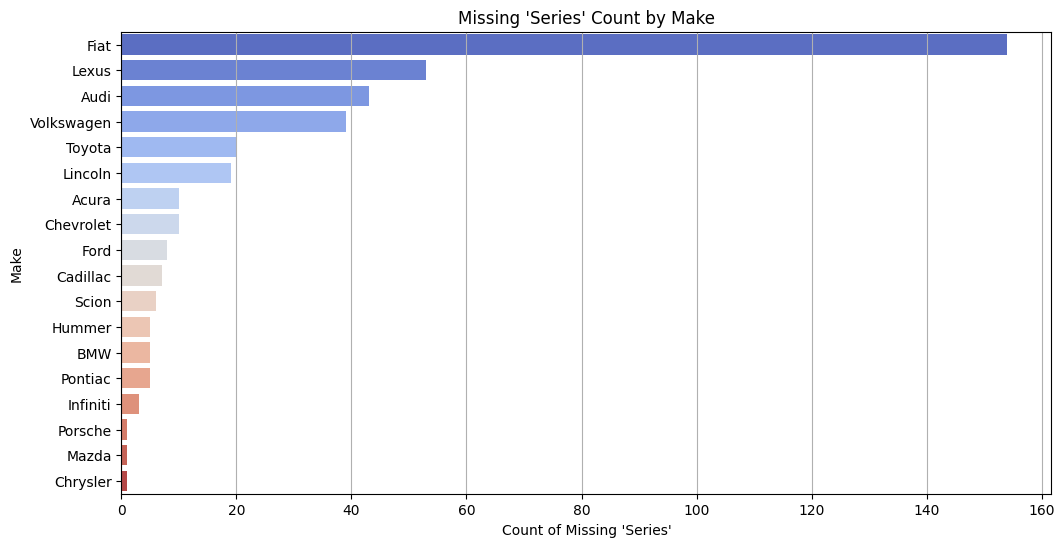

In [ ]:
# Count missing values in the 'series' column
missing_series_df = df_clean_new[df_clean_new['series'].isna()]

# Visualizing missing 'series' values by Make
plt.figure(figsize=(12, 6))
sns.countplot(data=missing_series_df, y='make', order=missing_series_df['make'].value_counts().index, palette="coolwarm")
plt.title("Missing 'Series' Count by Make")
plt.xlabel("Count of Missing 'Series'")
plt.ylabel("Make")
plt.grid(axis="x")
plt.show()

In [ ]:
# Step 1: Compute the most common series per Make
most_common_series_by_make = df_clean_new.groupby('make')['series'].agg(lambda x: x.mode()[0] if not x.mode().empty else None)

# Step 2: Fill missing 'series' values based on the most common series for the same Make
df_clean_new['series'] = df_clean_new.apply(
    lambda row: most_common_series_by_make[row['make']] if pd.isna(row['series']) else row['series'], axis=1
)

# Step 3: Check if there are any remaining missing values in 'series'
remaining_missing_series = df_clean_new['series'].isna().sum()

# Display the count of remaining missing values in 'series'
remaining_missing_series


11

In [ ]:
#fill the engine_size
df_clean_new['engine_size'] = df_clean_new['engine_size'].fillna(df_clean_new['engine_size'].median())

In [ ]:
df_clean_new.isnull().sum()

,0
days_on_market,0
stock_type,0
mileage,0
price,0
msrp,0
model_year,0
make,0
model,0
series,11
style,0


In [ ]:
#drop series collumn
df_clean_new.drop(columns=['series'], inplace=True)


# **Outlier** **Handling**

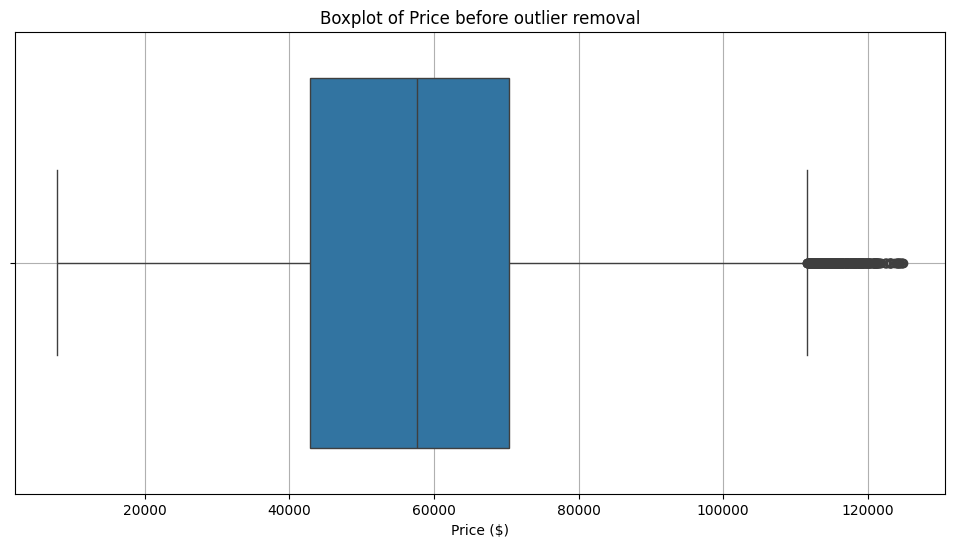

In [ ]:
#plot a boxplot for price befor outlier removal
plt.figure(figsize=(12, 6))
sns.boxplot(x=df_clean_new['price'])
plt.title("Boxplot of Price before outlier removal")
plt.xlabel("Price ($)")
plt.grid(True)
plt.ticklabel_format(style='plain', axis='x')

plt.show()





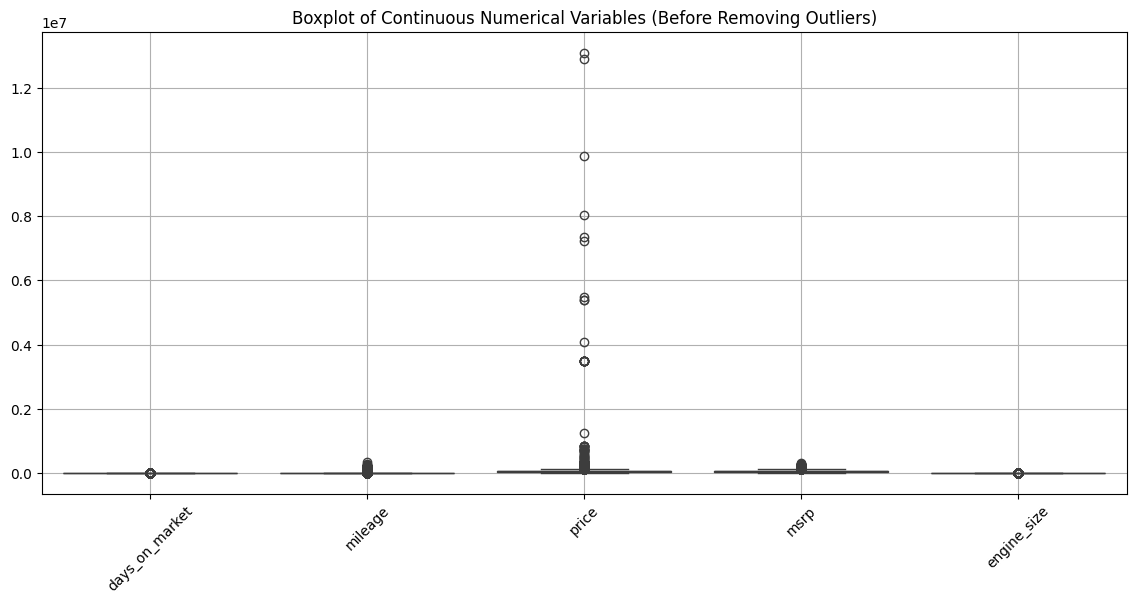

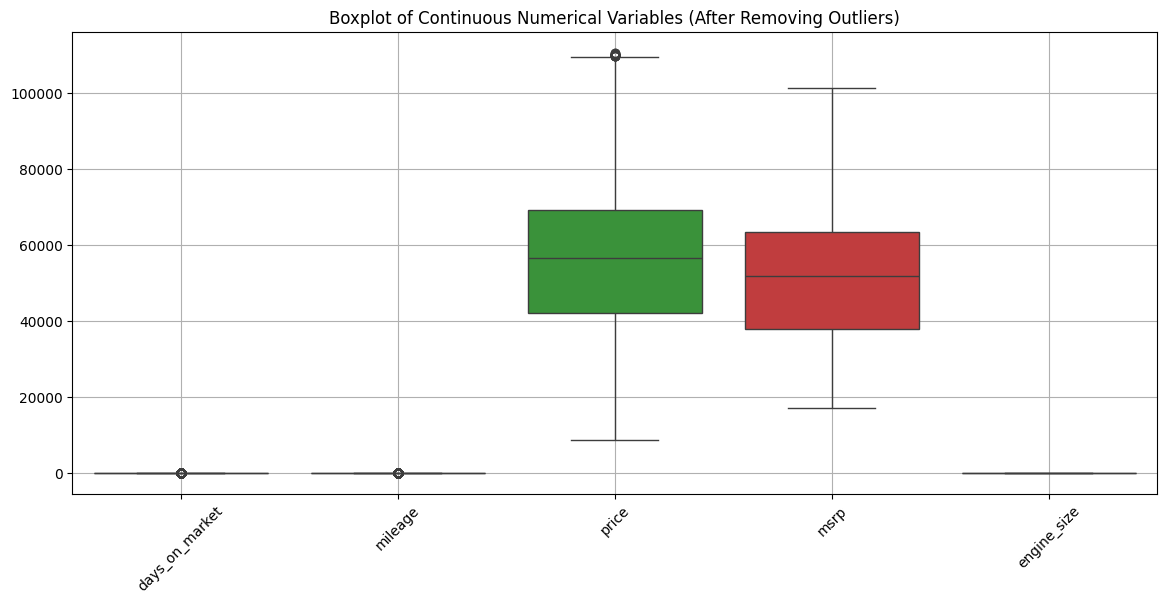

Dataset after outlier removal:
        days_on_market stock_type  mileage   price   msrp  model_year    make  \
2143                 7       USED        1   12999  29695        2010    Jeep   
4001                19       USED        1   10950  29635        2012  Suzuki   
4379                 4       USED        1   13997  29995        2013   Dodge   
4380                 3       USED        1   13997  29995        2013   Dodge   
5059                21       USED        1   12995  32595        2013     Kia   
...                ...        ...      ...     ...    ...         ...     ...   
145103              77        NEW       30   95042  88500        2024   Volvo   
145105              71        NEW       30   99542  94500        2024   Volvo   
145107              87        NEW       30  102016  94500        2024   Volvo   
145108              82        NEW       30  103950  94500        2024   Volvo   
145110              96        NEW       30  105990  94500        2024   Volvo 

In [ ]:

from scipy.stats import zscore

# Step 1: Define Continuous Numerical Columns for Outlier Detection
numerical_columns = ['days_on_market', 'mileage', 'price', 'msrp', 'engine_size']

# # Make a copy to avoid modifying the original dataset
# df_clean_new = df_clean.copy()

# Step 2: Detect & Remove Outliers Using IQR
def remove_outliers_iqr(df, columns, multiplier=1.5):
    # df = df.copy()  # Create a copy to avoid modifying the original dataframe

    for col in columns:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1

        # Define acceptable range
        lower_bound = Q1 - multiplier * IQR
        upper_bound = Q3 + multiplier * IQR

        # Apply filtering
        df = df[(df[col] >= lower_bound) & (df[col] <= upper_bound)]

    return df

# Apply IQR-based outlier removal to df_clean_new
df_clean_new = remove_outliers_iqr(df_clean_new, numerical_columns)

# Step 3: Visualize Outliers Before and After Using Boxplots
plt.figure(figsize=(14, 6))
sns.boxplot(data=df_clean[numerical_columns])
plt.title("Boxplot of Continuous Numerical Variables (Before Removing Outliers)")
plt.xticks(rotation=45)
plt.grid(True)
plt.show()

plt.figure(figsize=(14, 6))
sns.boxplot(data=df_clean_new[numerical_columns])
plt.title("Boxplot of Continuous Numerical Variables (After Removing Outliers)")
plt.xticks(rotation=45)
plt.grid(True)
plt.show()

# Step 4: Detect Outliers Using Z-Score
z_scores = np.abs(df_clean[numerical_columns].apply(zscore))
threshold = 3  # Typical threshold for extreme values

# Find rows with extreme values
df_outliers_zscore = df_clean[z_scores > threshold].dropna()

# Display dataset after outlier removal
print("Dataset after outlier removal:")
print(df_clean_new)

# Display extreme outliers detected using Z-score
print("\nExtreme Outliers Detected using Z-score:")
print(df_outliers_zscore)

In [ ]:
df_clean_new.shape

(37836, 16)

In [ ]:
df_clean_new.columns

Index(['days_on_market', 'stock_type', 'mileage', 'price', 'msrp',
       'model_year', 'make', 'model', 'style', 'exterior_color_category',
       'interior_color_category', 'drivetrain_from_vin',
       'transmission_from_vin', 'fuel_type_from_vin', 'number_price_changes',
       'engine_size'],
      dtype='object')

In [ ]:
df_clean_new.isnull().sum()

,0
days_on_market,0
stock_type,0
mileage,0
price,0
msrp,0
model_year,0
make,0
model,0
style,0
exterior_color_category,0


In [ ]:


# Define target variable (price)
y = df_clean_new['price']

# Define features (drop target variable)
X = df_clean_new.drop(columns=['price'])


In [ ]:
categorical_column = X.select_dtypes(include=['object']).columns
categorical_column

Index(['stock_type', 'make', 'model', 'style', 'exterior_color_category',
       'interior_color_category', 'drivetrain_from_vin',
       'transmission_from_vin', 'fuel_type_from_vin'],
      dtype='object')

In [ ]:
numerical_column = X.select_dtypes(exclude = 'object').columns
numerical_column

Index(['days_on_market', 'mileage', 'msrp', 'model_year',
       'number_price_changes', 'engine_size'],
      dtype='object')

In [ ]:
print("Columns in X after outlier removal:", X.columns.tolist())


Columns in X after outlier removal: ['days_on_market', 'stock_type', 'mileage', 'msrp', 'model_year', 'make', 'model', 'style', 'exterior_color_category', 'interior_color_category', 'drivetrain_from_vin', 'transmission_from_vin', 'fuel_type_from_vin', 'number_price_changes', 'engine_size']


In [ ]:
df_cleaned_price = df_clean_new[(df_clean_new['price'] >= 1000) & (df_clean_new['price'] <= 2000000)]
display(df_cleaned_price)




,days_on_market,stock_type,mileage,price,msrp,model_year,make,model,style,exterior_color_category,interior_color_category,drivetrain_from_vin,transmission_from_vin,fuel_type_from_vin,number_price_changes,engine_size
952,4,USED,142,7900,22180,2007,Toyota,Corolla,4D Sedan,white,black,FWD,M,Gas,0,1.8
1509,22,USED,300,21000,38899,2009,Ford,F150,Supercrew 4WD,yellow,black,4WD,A,Gas,0,4.6
2143,7,USED,1,12999,29695,2010,Jeep,Liberty,4D Utility 4WD,white,black,4WD,A,Gas,0,3.7
2304,1,USED,219,8900,16460,2010,Toyota,Corolla,4D Sedan,white,black,FWD,M,Gas,0,1.8
3663,3,USED,181,8900,21195,2012,Jeep,Compass,4D Utility 4WD,white,black,4WD,A,Gas,0,2.4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
145105,71,NEW,30,99542,94500,2024,Volvo,XC90,4D Utility AWD,white,"gray,black",AWD,A,PHEV,18,2.0
145107,87,NEW,30,102016,94500,2024,Volvo,XC90,4D Utility AWD,white,"gray,black",AWD,A,PHEV,29,2.0
145108,82,NEW,30,103950,94500,2024,Volvo,XC90,4D Utility AWD,white,gray,AWD,A,PHEV,22,2.0
145109,99,NEW,30,105781,94500,2024,Volvo,XC90,4D Utility AWD,gray,"gray,black",AWD,A,PHEV,25,2.0


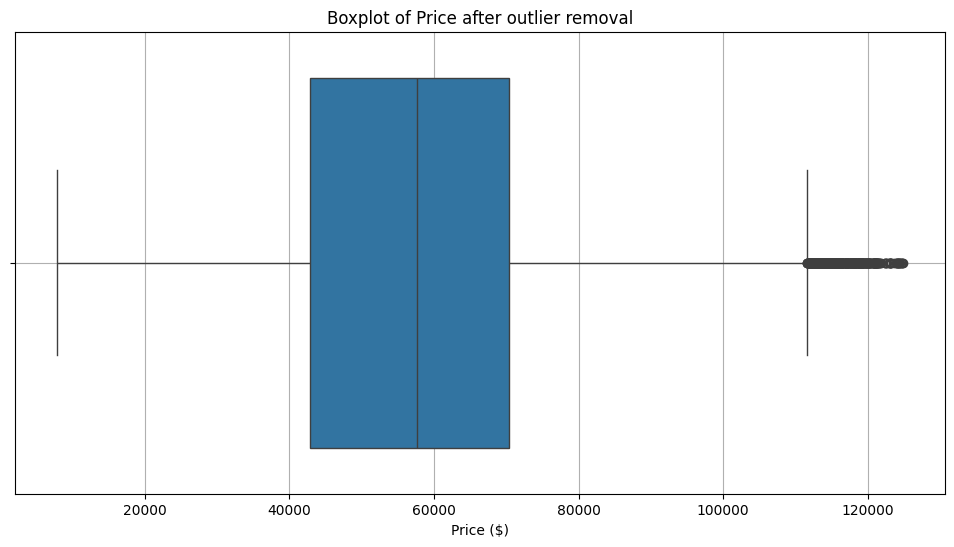

In [ ]:
#boxplot price after outlier removal
plt.figure(figsize=(12, 6))
sns.boxplot(x=df_cleaned_price['price'])
plt.title("Boxplot of Price after outlier removal")
plt.xlabel("Price ($)")
plt.grid(True)
plt.show()

In [ ]:
from sklearn.preprocessing import LabelEncoder

# Identify categorical columns for label encoding
categorical_columns = ['stock_type', 'make', 'model', 'style', 'exterior_color_category',
       'interior_color_category', 'drivetrain_from_vin','transmission_from_vin', 'fuel_type_from_vin']

label_encoders = {}  # Store encoders for later use

for col in categorical_columns:
    le = LabelEncoder()
    X[col] = le.fit_transform(X[col].astype(str))  # Convert to string before encoding
    label_encoders[col] = le  # Store the encoder


In [ ]:
from sklearn.preprocessing import StandardScaler

# Identify numerical columns for scaling (exclude target)
numerical_columns = ['days_on_market', 'mileage', 'msrp', 'model_year',
       'number_price_changes', 'engine_size']

scaler = StandardScaler()
X[numerical_columns] = scaler.fit_transform(X[numerical_columns])


In [ ]:
#split
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [ ]:
X_train.shape[1]

15

In [ ]:
X_train

,days_on_market,stock_type,mileage,msrp,model_year,make,model,style,exterior_color_category,interior_color_category,drivetrain_from_vin,transmission_from_vin,fuel_type_from_vin,number_price_changes,engine_size
132454,-0.183404,0,-0.114234,-1.130346,0.214736,27,199,60,52,4,1,0,2,-0.208513,-1.044789
102185,0.400142,0,-0.654986,0.987559,0.214736,10,94,170,52,0,0,0,1,-0.208513,-0.056816
144914,0.821592,0,0.246268,0.609101,0.214736,34,262,60,20,5,1,0,1,0.761054,-0.056816
91083,1.080946,0,-0.204359,1.960885,0.214736,6,216,123,4,0,0,0,0,0.761054,0.190177
82844,0.983688,0,2.048774,0.013300,0.214736,2,175,71,50,0,1,0,2,0.179314,-0.633134
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
93715,-0.021308,0,-0.654986,0.336402,0.214736,7,164,79,5,0,1,0,2,0.179314,0.684164
142539,-0.637273,0,-0.444693,0.288330,0.214736,33,128,60,4,12,1,0,1,-0.402426,-0.056816
131920,-0.475177,0,-0.204359,-0.911837,0.214736,27,199,60,52,4,1,0,2,-0.208513,-1.044789
70361,0.400142,0,1.387855,3.043290,-2.249462,10,93,170,40,0,0,0,2,0.954967,0.601833


In [ ]:
y_train

,price
132454,34999
102185,63305
144914,70097
91083,87709
82844,58115
...,...
93715,60450
142539,63320
131920,39988
70361,118230


In [ ]:
X_test

,days_on_market,stock_type,mileage,msrp,model_year,make,model,style,exterior_color_category,interior_color_category,drivetrain_from_vin,transmission_from_vin,fuel_type_from_vin,number_price_changes,engine_size
119245,-0.637273,0,-0.234401,0.349513,0.214736,17,119,48,4,0,0,0,2,-0.402426,0.684164
115098,-0.540016,0,-0.024108,0.096275,0.214736,14,165,63,52,0,1,0,2,-0.402426,0.848826
143421,-0.637273,0,-0.504777,-1.110127,0.214736,33,231,60,54,7,1,0,2,-0.208513,-1.044789
89215,0.011111,0,-0.504777,0.842119,0.214736,6,216,121,52,0,0,0,2,0.954967,2.083793
120636,2.637069,0,-0.204359,1.702811,0.214736,17,255,54,4,0,0,0,4,5.027148,-0.633134
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
84335,-0.669693,0,2.048774,1.121869,0.214736,3,258,48,52,0,1,0,2,-0.208513,0.190177
68630,-0.604854,0,-0.654986,2.176713,-2.249462,6,226,54,52,0,0,0,0,-0.402426,0.190177
101750,-1.091143,0,0.005933,1.046119,0.214736,10,93,169,52,0,0,0,2,-0.402426,0.601833
103927,-0.442758,0,-0.204359,0.486678,0.214736,11,51,123,4,0,0,0,2,-0.402426,-0.056816


In [ ]:
y_test

,price
119245,60960
115098,59566
143421,38870
89215,74039
120636,84322
...,...
84335,94681
68630,109980
101750,65865
103927,67243


In [ ]:
X_train.to_csv('X_train.csv', index=False)

In [ ]:
y_test.to_csv('y_test.csv',index=False)